# =============================================================================
# This code implements the complete prediction pipeline, including data
# preprocessing, feature engineering, model training, base model evaluation,
# and performance comparison before and after anomaly/IQR filtering.
# =============================================================================

Score Calculation:

| Metric |  Min |   Max | Model Value |
| ------ | ---: | ----: | ----------: |
| R²     | 0.85 |  0.95 |        0.90 |
| MAE    |    8 |    15 |          10 |
| MSE    |   80 |   200 |         100 |
| RMSE   | 8.94 | 14.14 |          10 |
| MAPE   |    4 |     8 |           5 |


For R² (higher is better)
R2N​=(R2−R2min​) (R2max​−R2min​)​

MetricN​=(Metricmax​−Metric)/(Metricmax​−Metricmin​)

Score=(R2N​+MAEN​+MSEN​+RMSEN​+MAPEN​)/5


Then,

R2_N   = (0.90 - 0.85) / (0.95 - 0.85) = 0.50

MAE_N  = (15 - 10) / (15 - 8) = 0.714

MSE_N  = (200 - 100) / (200 - 80) = 0.833

RMSE_N = (14.14 - 10) / (14.14 - 8.94) = 0.796

MAPE_N = (8 - 5) / (8 - 4) = 0.75

Finally,

Score = (0.50 + 0.714 + 0.833 + 0.796 + 0.75) / 5
      = 3.593 / 5
      = 0.719



IQR FILTERING SUMMARY
Rows before IQR filtering : 123,627
Rows after IQR filtering  : 80,216
Rows removed by IQR       : 43,411
Percent removed           : 35.11%


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



=== Train/Test metrics by Combo (sorted by Score desc) ===
           Combo            Model  Score  Train_R2  Train_MAE  Train_MSE  Train_RMSE  Train_MAPE  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
SPATIAL+TEMPORAL MLP (256,128,64)  0.991     0.999      0.448      0.381       0.617       2.227    0.991     0.640     3.363      1.834      3.004
SPATIAL+TEMPORAL     MLP (128,64)  0.981     0.998      0.619      0.800       0.894       3.170    0.989     0.733     4.018      2.004      3.548
SPATIAL+TEMPORAL              ETR  0.974     1.000      0.000      0.000       0.000       0.000    0.980     0.559     7.428      2.725      1.823
SPATIAL+TEMPORAL         MLP (64)  0.970     0.997      0.702      1.171       1.082       3.856    0.987     0.787     5.081      2.254      4.063
SPATIAL+TEMPORAL               RF  0.964     0.999      0.257      0.515       0.718       0.923    0.979     0.698     8.040      2.835      2.369
SPATIAL+TEMPORAL            Bayes  0.960     0.993  

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.34789e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



MAE COMPARISON: BEFORE vs AFTER IQR


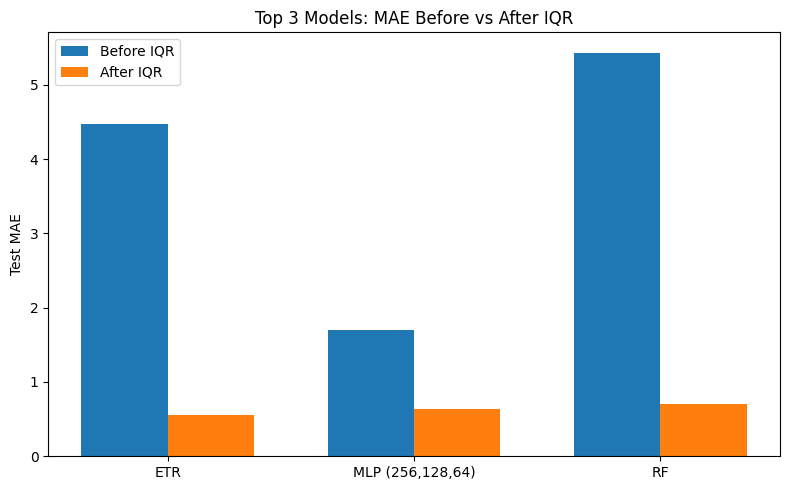

In [230]:
# ==== Experiments over SPATIAL / TEMPORAL / SPATIAL+TEMPORAL (R2, MAE, MSE, RMSE, MAPE) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor
#from xgboost import XGBRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20


PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ---------------- Save dataset BEFORE IQR ----------------
df_before_iqr = df.copy()

# ---------------- IQR outlier trimming (exclude target) ----------------
candidate_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in candidate_numeric if c != "count"]
all_features = [c for c in all_features
                if df[c].notna().sum() > 0 and df[c].nunique(dropna=True) > 1]

'''for col in all_features:
   Q1 = df[col].quantile(0.25)
   Q3 = df[col].quantile(0.75)
   IQR = Q3 - Q1
   if pd.isna(IQR) or IQR == 0:
       continue
   lower = Q1 - 1.5 * IQR
   upper = Q3 + 1.5 * IQR
   df = df[(df[col] >= lower) & (df[col] <= upper)]
if len(df) == 0:
   raise RuntimeError("All rows were filtered by the IQR loop. Relax bounds or skip constant columns.")
'''
# ---------------- Rows before IQR ----------------
rows_before_iqr = len(df)

print("\n" + "=" * 60)
print("IQR FILTERING SUMMARY")
print("=" * 60)
print(f"Rows before IQR filtering : {rows_before_iqr:,}")
k = 3
# <-- more gentle than 1.5; try 2.0 or 3.0
mask = pd.Series(True, index=df.index)

for col in all_features:
    s = df[col]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        continue
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask &= s.between(lower, upper) | s.isna()

df = df[mask].copy()

# ---------------- Rows after IQR ----------------
rows_after_iqr = len(df)
rows_removed_iqr = rows_before_iqr - rows_after_iqr
pct_removed_iqr = (
    rows_removed_iqr / rows_before_iqr * 100
    if rows_before_iqr > 0 else 0
)

print(f"Rows after IQR filtering  : {rows_after_iqr:,}")
print(f"Rows removed by IQR       : {rows_removed_iqr:,}")
print(f"Percent removed           : {pct_removed_iqr:.2f}%")
print("=" * 60)



if len(df) == 0:
    raise RuntimeError("All rows were filtered by IQR. Increase k (e.g., 3.0) or skip trimming.")

# ---------------- Save dataset AFTER IQR ----------------
df_after_iqr = df.copy()

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',#'income_75_100','male_45_49','female_50_54','female_45_49','male_55_59',
   # 'income_30_35','male_5_9','income_25_30','female_55_59','male_10_14','male_50_54',
   # 'income_60_75','income_50_60','male_35_39','female_35_39','income_40_45','female_5_9',
   # 'female_30_34','female_10_14','income_100_125'
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable, but using only hours for TEMPORAL combo) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day
def _m2s(m): return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3
df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

#TEMPORAL with calendar + hours (commented out per your choice)
FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

#FEATS_TEMPORAL_ALL = hour_cols[:]

# ---- SIMPLE lag for TEMPORAL only (lag1; leak-safe) ----
keys = ["poi_id","date"] if "poi_id" in df.columns else ["date"]
df_lag = df[keys + ["count"]].sort_values(keys).copy()

# ---- Fast leak-safe lag1 (no merge, stable sort, original order preserved) ----
orig_idx = df.index

if "poi_id" in df.columns:
    s = (
        df[["poi_id", "date", "count"]]
        .sort_values(["poi_id", "date"], kind="mergesort")
        .groupby("poi_id", sort=False)["count"]
        .shift(1)
    )
else:
    s = (
        df[["date", "count"]]
        .sort_values(["date"], kind="mergesort")["count"]
        .shift(1)
    )

#f["lag1"] = s.reindex(orig_idx)

# (You currently don't include lag1 in TEMPORAL; keeping that as-is)
# if "lag1" not in FEATS_TEMPORAL_ALL:
#EATS_TEMPORAL_ALL.append("lag1")

# ---------------- Feature combos ----------------
BASE_COMBOS = {
   # "SPATIAL": spatial_numeric,
  #  "TEMPORAL": FEATS_TEMPORAL_ALL,
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models (existing + MLPs) ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
   # ("XGB",  XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
   #                       subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
   #                       n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist")),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25, random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    """Normalize a metric to [0,1]; handle NaNs & constant series."""
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    rows = []

    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)

        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        # ---------------- Train metrics ----------------
        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)
        train_mse = mean_squared_error(y_tr, pred_tr)
        train_rmse = np.sqrt(train_mse)

        # Avoid division by zero in MAPE
        train_nonzero = np.abs(y_tr) > 1e-8
        train_mape = (
            np.mean(
                np.abs(
                    (y_tr[train_nonzero] - pred_tr[train_nonzero])
                    / y_tr[train_nonzero]
                )
            ) * 100
            if np.any(train_nonzero)
            else np.nan
        )

        # ---------------- Test metrics ----------------
        test_r2 = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)
        test_rmse = np.sqrt(test_mse)

        # Avoid division by zero in MAPE
        test_nonzero = np.abs(y_te) > 1e-8
        test_mape = (
            np.mean(
                np.abs(
                    (y_te[test_nonzero] - pred_te[test_nonzero])
                    / y_te[test_nonzero]
                )
            ) * 100
            if np.any(test_nonzero)
            else np.nan
        )

        rows.append({
            "Combo": combo_name,
            "Model": name,

            "Train_R2": train_r2,
            "Train_MAE": train_mae,
            "Train_MSE": train_mse,
            "Train_RMSE": train_rmse,
            "Train_MAPE": train_mape,

            "Test_R2": test_r2,
            "Test_MAE": test_mae,
            "Test_MSE": test_mse,
            "Test_RMSE": test_rmse,
            "Test_MAPE": test_mape,
        })

    res = pd.DataFrame(rows)

    # Build combined score using only:
    # R2, MAE, MSE, RMSE, and MAPE
    for mname in ["Test_R2"]:
        res[f"{mname}_N"] = _norm_series(
            res[mname],
            higher_is_better=True
        )

    for mname in [
        "Test_MAE",
        "Test_MSE",
        "Test_RMSE",
        "Test_MAPE",
    ]:
        res[f"{mname}_N"] = _norm_series(
            res[mname],
            higher_is_better=False
        )

    norm_cols = [
        "Test_R2_N",
        "Test_MAE_N",
        "Test_MSE_N",
        "Test_RMSE_N",
        "Test_MAPE_N",
    ]

    res["Score"] = res[norm_cols].mean(axis=1)

    res = (
        res
        .sort_values(
            ["Combo", "Score"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

    return res


# ---------------- Run all combos ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# ---------------- Print full table ----------------
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE","Train_MSE","Train_RMSE","Train_MAPE",
            "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE"
        ]].sort_values(["Combo","Score"], ascending=[True, False])
          .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

# ---------------- TOP 3 per Combo (by combined Score) ----------------
if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO (by combined Score) ===")
    print(ranked[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE","Train_MSE","Train_RMSE","Train_MAPE",
            "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE"
        ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# =====================================================================================
# ===================== MAE COMPARISON: BEFORE vs AFTER IQR ===========================
# =====================================================================================

def run_pipeline_for_iqr_stage(_df, stage_name):
    _df = _df.copy()

    _df["poi_id_code"] = _df["poi_id"].astype("category").cat.codes

    spatial_cols_stage = []
    for c in _df.columns:
        if (
            c in spatial_exact
            or c in spatial_race
            or any(str(c).startswith(p) for p in spatial_prefixes)
        ):
            spatial_cols_stage.append(c)

    spatial_numeric_stage = [
        c for c in spatial_cols_stage
        if pd.api.types.is_numeric_dtype(_df[c]) and c != "count"
    ]

    if "poi_id_code" not in spatial_numeric_stage:
        spatial_numeric_stage.append("poi_id_code")

    spatial_numeric_stage = [
        c for c in spatial_numeric_stage
        if c not in LEAKY
    ]

    _df["dow"] = _df["date"].dt.dayofweek
    _df["is_weekend"] = (_df["dow"] >= 5).astype(int)
    _df["week"] = _df["date"].dt.isocalendar().week.astype(int)
    _df["month"] = _df["date"].dt.month
    _df["day"] = _df["date"].dt.day

    _df["season"] = _df["month"].apply(lambda m: _m2s(int(m)))
    _df["date_ordinal"] = _df["date"].map(
        lambda x: x.toordinal() if pd.notnull(x) else np.nan
    )

    _df["is_month_start"] = _df["date"].dt.is_month_start.astype(int)
    _df["is_month_end"] = _df["date"].dt.is_month_end.astype(int)
    _df["is_quarter_start"] = _df["date"].dt.is_quarter_start.astype(int)
    _df["is_quarter_end"] = _df["date"].dt.is_quarter_end.astype(int)

    hour_cols_stage = [
        c for c in _df.columns
        if isinstance(c, str)
        and len(c) == 4
        and c.startswith("hh")
        and c[2:].isdigit()
    ]

    feats_temporal_stage = [
        "is_weekend", "season", "month", "week", "dow", "day", "date_ordinal",
        "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end"
    ] + [c for c in hour_cols_stage if c in _df.columns]

    base_combos_stage = {
        "SPATIAL+TEMPORAL": list(
            dict.fromkeys(spatial_numeric_stage + feats_temporal_stage)
        ),
    }

    all_results_stage = []

    for combo_name, feats in base_combos_stage.items():
        feats = [f for f in feats if f in _df.columns]

        if not feats:
            continue

        X, y = build_Xy(_df, feats)

        if len(X) == 0 or X.shape[1] == 0:
            continue

        res = eval_models_both(X, y, MODELS, combo_name)
        res.insert(0, "Stage", stage_name)
        all_results_stage.append(res)

    return (
        pd.concat(all_results_stage, ignore_index=True)
        if all_results_stage
        else pd.DataFrame()
    )


final_tbl_before_iqr = run_pipeline_for_iqr_stage(df_before_iqr, "BEFORE_IQR")
final_tbl_after_iqr = run_pipeline_for_iqr_stage(df_after_iqr, "AFTER_IQR")

tbl_iqr_mae_compare = pd.concat(
    [final_tbl_before_iqr, final_tbl_after_iqr],
    ignore_index=True
)

print("\n" + "=" * 70)
print("MAE COMPARISON: BEFORE vs AFTER IQR")
print("=" * 70)

# ---------------- Plot MAE before vs after IQR (TOP 3 ONLY) ----------------

if not final_tbl_before_iqr.empty and not final_tbl_after_iqr.empty:

    before_mae = (
        final_tbl_before_iqr
        .groupby("Model")["Test_MAE"]
        .mean()
    )

    after_mae = (
        final_tbl_after_iqr
        .groupby("Model")["Test_MAE"]
        .mean()
    )

    # Combine before and after MAE
    mae_compare = pd.concat(
        [before_mae.rename("Before"),
         after_mae.rename("After")],
        axis=1
    )

    # Best MAE for each model
    mae_compare["Best_MAE"] = mae_compare.min(axis=1)

    # -------- Select ONLY top 3 models --------
    top3_models = (
        mae_compare
        .sort_values("Best_MAE")
        .head(3)
        .index
        .tolist()
    )

    before_mae = before_mae.reindex(top3_models)
    after_mae = after_mae.reindex(top3_models)

    x = np.arange(len(top3_models))
    w = 0.35

    plt.figure(figsize=(8,5))

    plt.bar(
        x - w/2,
        before_mae.values,
        width=w,
        label="Before IQR"
    )

    plt.bar(
        x + w/2,
        after_mae.values,
        width=w,
        label="After IQR"
    )

    plt.xticks(x, top3_models)
    plt.ylabel("Test MAE")
    plt.title("Top 3 Models: MAE Before vs After IQR")
    plt.legend()
    plt.tight_layout()
    plt.show()
    


Using Lag Features.
Lag means using the previous day's visitor count to help predict today's visitor count 
Example: Yesterday


Rows BEFORE IQR saved for comparison: 123,627

IQR FILTERING SUMMARY
Rows before IQR filtering : 123,627
Rows after IQR filtering  : 80,216
Rows removed by IQR       : 43,411
Percent removed           : 35.11%
Rows AFTER IQR saved for comparison : 80,216


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



=== Train/Test metrics by Combo (sorted by Score desc) ===
           Combo            Model  Score  Train_R2  Train_MAE  Train_MSE  Train_RMSE  Train_MAPE  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
SPATIAL+TEMPORAL MLP (256,128,64)  0.991     0.999      0.448      0.381       0.617       2.227    0.991     0.640     3.363      1.834      3.004
SPATIAL+TEMPORAL     MLP (128,64)  0.981     0.998      0.619      0.800       0.894       3.170    0.989     0.733     4.018      2.004      3.548
SPATIAL+TEMPORAL              ETR  0.974     1.000      0.000      0.000       0.000       0.000    0.980     0.559     7.428      2.725      1.823
SPATIAL+TEMPORAL         MLP (64)  0.970     0.997      0.702      1.171       1.082       3.856    0.987     0.787     5.081      2.254      4.063
SPATIAL+TEMPORAL               RF  0.964     0.999      0.257      0.515       0.718       0.923    0.979     0.698     8.040      2.835      2.369
SPATIAL+TEMPORAL            Bayes  0.960     0.993  

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14346e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


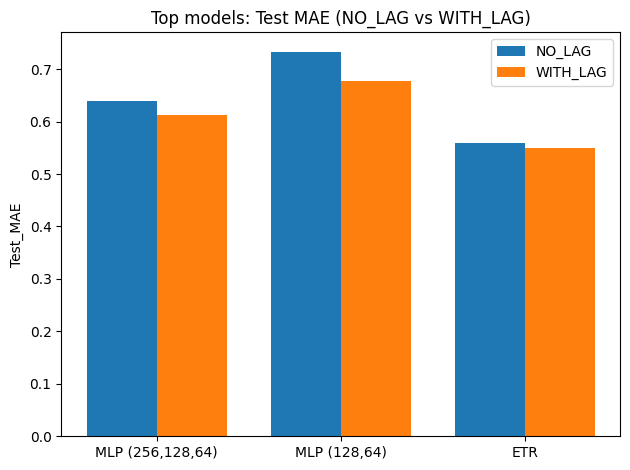

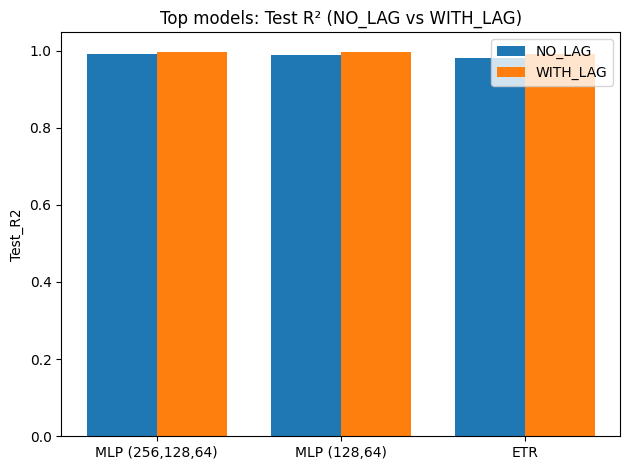

In [231]:
# ==== Experiments over SPATIAL / TEMPORAL / SPATIAL+TEMPORAL (Train & Test: multi-metric score)
#      + Compare WITH vs WITHOUT lag1 (single-split) + Visualize best-3 MODELS (not hybrids)
# NOTE: Keeps your existing logic; only adds the lag-compare + plots at the end.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20

PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ---------------- Save dataset BEFORE IQR ----------------
df_before_iqr = df.copy()
print(f"\nRows BEFORE IQR saved for comparison: {len(df_before_iqr):,}")

# ---------------- IQR outlier trimming (exclude target) ----------------
candidate_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in candidate_numeric if c != "count"]
all_features = [c for c in all_features
                if df[c].notna().sum() > 0 and df[c].nunique(dropna=True) > 1]

# ---------------- Rows before IQR ----------------
rows_before_iqr = len(df)

print("\n" + "=" * 60)
print("IQR FILTERING SUMMARY")
print("=" * 60)
print(f"Rows before IQR filtering : {rows_before_iqr:,}")
k =3
mask = pd.Series(True, index=df.index)

for col in all_features:
    s = df[col]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        continue
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask &= s.between(lower, upper) | s.isna()

df = df[mask].copy()



# ---------------- Rows after IQR ----------------
rows_after_iqr = len(df)
rows_removed_iqr = rows_before_iqr - rows_after_iqr
pct_removed_iqr = (
    rows_removed_iqr / rows_before_iqr * 100
    if rows_before_iqr > 0 else 0
)

print(f"Rows after IQR filtering  : {rows_after_iqr:,}")
print(f"Rows removed by IQR       : {rows_removed_iqr:,}")
print(f"Percent removed           : {pct_removed_iqr:.2f}%")
print("=" * 60)


if len(df) == 0:
    raise RuntimeError("All rows were filtered by IQR. Increase k (e.g., 3.0) or skip trimming.")

# ---------------- Save dataset AFTER IQR ----------------
df_after_iqr = df.copy()
print(f"Rows AFTER IQR saved for comparison : {len(df_after_iqr):,}")

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day

def _m2s(m):
    return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3

df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

# ---- leak-safe lag1 ----
orig_idx = df.index
if "poi_id" in df.columns:
    s = (df[["poi_id", "date", "count"]]
         .sort_values(["poi_id", "date"], kind="mergesort")
         .groupby("poi_id", sort=False)["count"]
         .shift(1))
else:
    s = (df[["date", "count"]]
         .sort_values(["date"], kind="mergesort")["count"]
         .shift(1))

df["lag1"] = s.reindex(orig_idx)

# ---------------- Feature combos (BASE) ----------------
BASE_COMBOS = {
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25,
                             random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    rows = []
    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)
        train_mse = mean_squared_error(y_tr, pred_tr)
        train_rmse = np.sqrt(train_mse)
        train_mape = np.mean(
            np.abs(
                (y_tr - pred_tr) /
                np.where(np.abs(y_tr) < 1e-8, np.nan, np.abs(y_tr))
            )
        ) * 100

        test_r2  = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)
        test_rmse = np.sqrt(test_mse)
        test_mape = np.mean(
            np.abs(
                (y_te - pred_te) /
                np.where(np.abs(y_te) < 1e-8, np.nan, np.abs(y_te))
            )
        ) * 100

        rows.append({
            "Combo": combo_name,
            "Model": name,
            "Train_R2":   train_r2,
            "Train_MAE":  train_mae,
            "Train_MSE":  train_mse,
            "Train_RMSE": train_rmse,
            "Train_MAPE": train_mape,
            "Test_R2":    test_r2,
            "Test_MAE":   test_mae,
            "Test_MSE":   test_mse,
            "Test_RMSE":  test_rmse,
            "Test_MAPE":  test_mape,
        })

    res = pd.DataFrame(rows)

    for mname in ["Test_R2"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=False)

    res["Score"] = res[
        ["Test_R2_N","Test_MAE_N","Test_MSE_N","Test_RMSE_N","Test_MAPE_N"]
    ].mean(axis=1)

    return (res.sort_values(["Combo","Score"], ascending=[True, False])
              .reset_index(drop=True))

# ---------------- Run all combos (BASE) ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE","Train_MSE","Train_RMSE","Train_MAPE",
        "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE"
    ]].sort_values(["Combo","Score"], ascending=[True, False])
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO AFTER IQR (by combined Score) ===")
    print(ranked[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE","Train_MSE","Train_RMSE","Train_MAPE",
        "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE"
    ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))


# =========================================================================================
# ===================== ADD-ON: Compare WITH vs WITHOUT lag1 (MODEL table) + Plot best-3 ===
# =========================================================================================
# This section keeps your metrics schema:
# "Combo","Model","Train_R2","Train_MAE","Train_MSE","Train_RMSE","Train_MAPE","Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE"

def _make_combos_no_lag(base_combos):
    return {k: [f for f in v if f != "lag1"] for k, v in base_combos.items()}

def _make_combos_with_lag(base_combos):
    out = {}
    for k, v in base_combos.items():
        vv = list(v)
        if "lag1" in df.columns and "lag1" not in vv:
            vv = vv + ["lag1"]
        out[k] = list(dict.fromkeys(vv))
    return out

def run_models_for_combos(_df, combos_dict, tag):
    results = []
    for combo_name, feats in combos_dict.items():
        if not feats:
            continue
        X, y = build_Xy(_df, feats)
        if len(X) == 0 or X.shape[1] == 0:
            continue
        r = eval_models_both(X, y, MODELS, combo_name)
        r.insert(0, "Lag", tag)
        results.append(r)
    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

COMBOS_NO_LAG  = _make_combos_no_lag(BASE_COMBOS)
COMBOS_WITH_LAG = _make_combos_with_lag(BASE_COMBOS)

tbl_no  = run_models_for_combos(df, COMBOS_NO_LAG,  tag="NO_LAG")
tbl_yes = run_models_for_combos(df, COMBOS_WITH_LAG, tag="WITH_LAG")
tbl_cmp = pd.concat([tbl_no, tbl_yes], ignore_index=True)



# ---- Plot: ONE MAE diagram + ONE R2 diagram (WITH_LAG vs NO_LAG in same figure) ----
if not tbl_cmp.empty:
    # pick top-3 models per Lag by Score
    top3_no  = (tbl_cmp[tbl_cmp["Lag"] == "NO_LAG"]
                .sort_values("Score", ascending=False)
                .head(3))
    top3_yes = (tbl_cmp[tbl_cmp["Lag"] == "WITH_LAG"]
                .sort_values("Score", ascending=False)
                .head(3))

    # union of model names (keeps order: NO_LAG top3 first, then add missing from WITH_LAG)
    models_u = top3_no["Model"].tolist()
    for m in top3_yes["Model"].tolist():
        if m not in models_u:
            models_u.append(m)

    # build a small table aligned by Model, with both lag metrics side-by-side
    sub = (tbl_cmp[tbl_cmp["Model"].isin(models_u)]
           .sort_values(["Model","Lag"])
           .copy())

    mae_p = sub.pivot_table(index="Model", columns="Lag", values="Test_MAE", aggfunc="mean").reindex(models_u)
    r2_p  = sub.pivot_table(index="Model", columns="Lag", values="Test_R2",  aggfunc="mean").reindex(models_u)

    # ensure both columns exist
    for col in ["NO_LAG", "WITH_LAG"]:
        if col not in mae_p.columns:
            mae_p[col] = np.nan
        if col not in r2_p.columns:
            r2_p[col] = np.nan

    # --- MAE plot (grouped bars) ---
    x = np.arange(len(models_u))
    w = 0.38

    plt.figure()
    plt.bar(x - w/2, mae_p["NO_LAG"].values,  width=w, label="NO_LAG")
    plt.bar(x + w/2, mae_p["WITH_LAG"].values, width=w, label="WITH_LAG")
    plt.xticks(x, models_u, rotation=0)
    plt.ylabel("Test_MAE")
    plt.title("Top models: Test MAE (NO_LAG vs WITH_LAG)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- R2 plot (grouped bars) ---
    plt.figure()
    plt.bar(x - w/2, r2_p["NO_LAG"].values,  width=w, label="NO_LAG")
    plt.bar(x + w/2, r2_p["WITH_LAG"].values, width=w, label="WITH_LAG")
    plt.xticks(x, models_u, rotation=0)
    plt.ylabel("Test_R2")
    plt.title("Top models: Test R² (NO_LAG vs WITH_LAG)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Applying Lag Feature. Lag1 indicates that is track visitor of yesterday. Before IQR and after IQR compare lag vs no lag 



Rows BEFORE IQR saved for comparison: 123,627

IQR FILTERING SUMMARY
Rows before IQR filtering : 123,627
Rows after IQR filtering  : 80,216
Rows removed by IQR       : 43,411
Percent removed           : 35.11%
Rows AFTER IQR saved for comparison : 80,216


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



=== Train/Test metrics by Combo (sorted by Score desc) ===
           Combo            Model  Score  Train_R2  Train_MAE  Train_MSE  Train_RMSE  Train_MAPE  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
SPATIAL+TEMPORAL MLP (256,128,64)  0.991     0.999      0.448      0.381       0.617       2.227    0.991     0.640     3.363      1.834      3.004
SPATIAL+TEMPORAL     MLP (128,64)  0.981     0.998      0.619      0.800       0.894       3.170    0.989     0.733     4.018      2.004      3.548
SPATIAL+TEMPORAL              ETR  0.974     1.000      0.000      0.000       0.000       0.000    0.980     0.559     7.428      2.725      1.823
SPATIAL+TEMPORAL         MLP (64)  0.970     0.997      0.702      1.171       1.082       3.856    0.987     0.787     5.081      2.254      4.063
SPATIAL+TEMPORAL               RF  0.964     0.999      0.257      0.515       0.718       0.923    0.979     0.698     8.040      2.835      2.369
SPATIAL+TEMPORAL            Bayes  0.960     0.993  

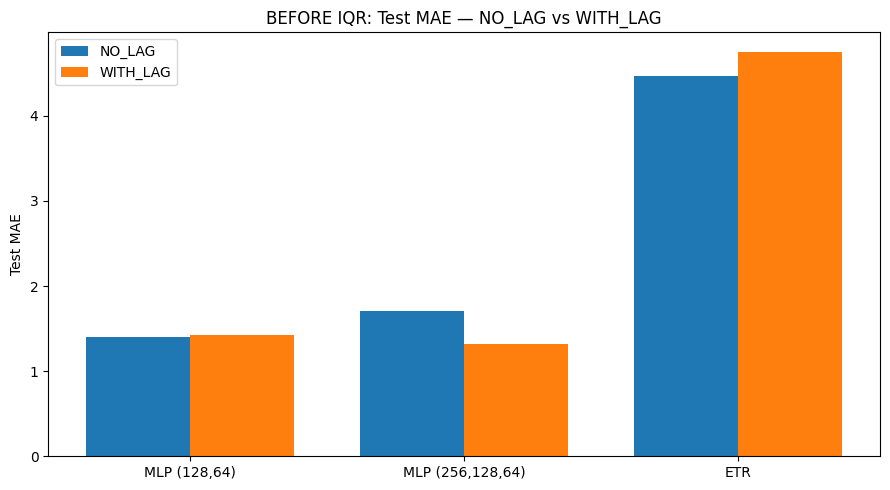

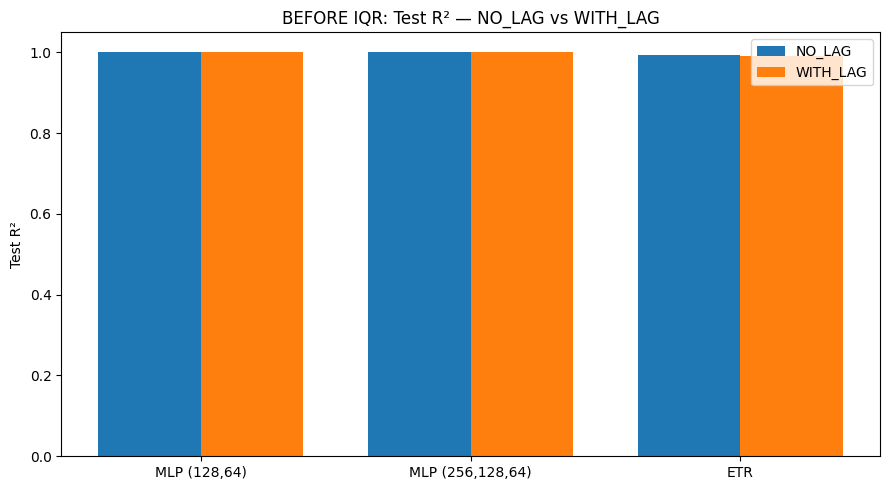

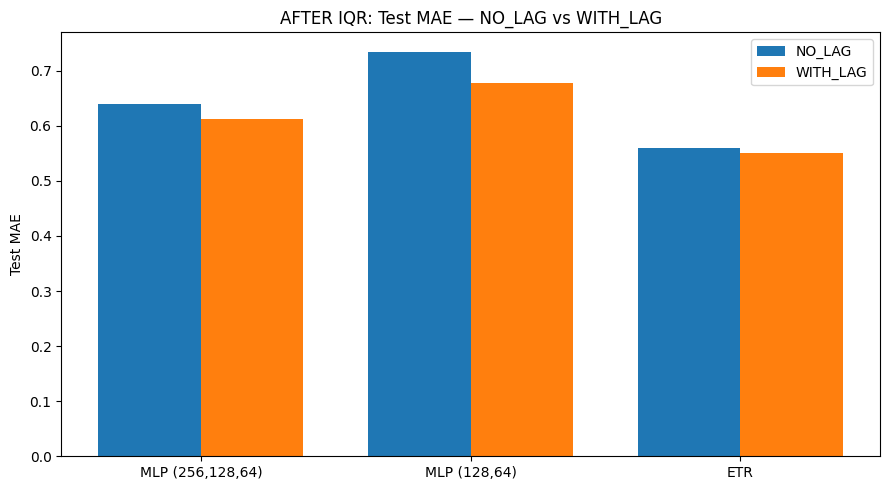

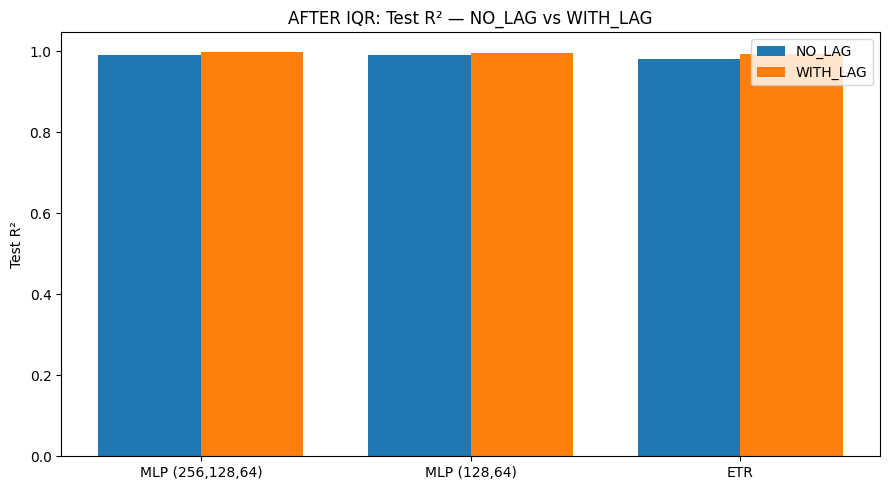


=== TOP 3: BEFORE_IQR | NO_LAG ===
     Stage    Lag            Combo            Model  Score  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
BEFORE_IQR NO_LAG SPATIAL+TEMPORAL     MLP (128,64)  0.828    1.000     1.404     6.458      2.541      4.545
BEFORE_IQR NO_LAG SPATIAL+TEMPORAL MLP (256,128,64)  0.774    1.000     1.705    11.738      3.426      5.001
BEFORE_IQR NO_LAG SPATIAL+TEMPORAL              ETR  0.200    0.994     4.468  1638.830     40.482      1.732

=== TOP 3: BEFORE_IQR | WITH_LAG ===
     Stage      Lag            Combo            Model  Score  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
BEFORE_IQR WITH_LAG SPATIAL+TEMPORAL MLP (256,128,64)  0.800    1.000     1.323     5.715      2.391      4.818
BEFORE_IQR WITH_LAG SPATIAL+TEMPORAL     MLP (128,64)  0.794    1.000     1.426     6.833      2.614      4.805
BEFORE_IQR WITH_LAG SPATIAL+TEMPORAL              ETR  0.200    0.992     4.746  2162.719     46.505      1.828

=== TOP 3: AFTER_IQR | NO_LAG ===
   

In [232]:
# ==== Experiments over SPATIAL / TEMPORAL / SPATIAL+TEMPORAL (Train & Test: multi-metric score)
#      + Compare WITH vs WITHOUT lag1 (single-split) + Visualize best-3 MODELS (not hybrids)
# NOTE: Keeps your existing logic; only adds the lag-compare + plots at the end.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20

PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ---------------- Save dataset BEFORE IQR ----------------
df_before_iqr = df.copy()
print(f"\nRows BEFORE IQR saved for comparison: {len(df_before_iqr):,}")

# ---------------- IQR outlier trimming (exclude target) ----------------
candidate_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in candidate_numeric if c != "count"]
all_features = [c for c in all_features
                if df[c].notna().sum() > 0 and df[c].nunique(dropna=True) > 1]

# ---------------- Rows before IQR ----------------
rows_before_iqr = len(df)

print("\n" + "=" * 60)
print("IQR FILTERING SUMMARY")
print("=" * 60)
print(f"Rows before IQR filtering : {rows_before_iqr:,}")
k =3
mask = pd.Series(True, index=df.index)

for col in all_features:
    s = df[col]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        continue
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask &= s.between(lower, upper) | s.isna()

df = df[mask].copy()



# ---------------- Rows after IQR ----------------
rows_after_iqr = len(df)
rows_removed_iqr = rows_before_iqr - rows_after_iqr
pct_removed_iqr = (
    rows_removed_iqr / rows_before_iqr * 100
    if rows_before_iqr > 0 else 0
)

print(f"Rows after IQR filtering  : {rows_after_iqr:,}")
print(f"Rows removed by IQR       : {rows_removed_iqr:,}")
print(f"Percent removed           : {pct_removed_iqr:.2f}%")
print("=" * 60)


if len(df) == 0:
    raise RuntimeError("All rows were filtered by IQR. Increase k (e.g., 3.0) or skip trimming.")

# ---------------- Save dataset AFTER IQR ----------------
df_after_iqr = df.copy()
print(f"Rows AFTER IQR saved for comparison : {len(df_after_iqr):,}")

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day

def _m2s(m):
    return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3

df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

# ---- leak-safe lag1 ----
orig_idx = df.index
if "poi_id" in df.columns:
    s = (df[["poi_id", "date", "count"]]
         .sort_values(["poi_id", "date"], kind="mergesort")
         .groupby("poi_id", sort=False)["count"]
         .shift(1))
else:
    s = (df[["date", "count"]]
         .sort_values(["date"], kind="mergesort")["count"]
         .shift(1))

df["lag1"] = s.reindex(orig_idx)

# ---------------- Feature combos (BASE) ----------------
BASE_COMBOS = {
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25,
                             random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    rows = []
    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)
        train_mse = mean_squared_error(y_tr, pred_tr)
        train_rmse = np.sqrt(train_mse)
        train_mape = np.nanmean(
            np.abs(
                (y_tr - pred_tr) /
                np.where(np.abs(y_tr) < 1e-8, np.nan, np.abs(y_tr))
            )
        ) * 100

        test_r2  = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)
        test_rmse = np.sqrt(test_mse)
        test_mape = np.nanmean(
            np.abs(
                (y_te - pred_te) /
                np.where(np.abs(y_te) < 1e-8, np.nan, np.abs(y_te))
            )
        ) * 100

        rows.append({
            "Combo": combo_name,
            "Model": name,
            "Train_R2":   train_r2,
            "Train_MAE":  train_mae,
            "Train_MSE":  train_mse,
            "Train_RMSE": train_rmse,
            "Train_MAPE": train_mape,
            "Test_R2":    test_r2,
            "Test_MAE":   test_mae,
            "Test_MSE":   test_mse,
            "Test_RMSE":  test_rmse,
            "Test_MAPE":  test_mape,
        })

    res = pd.DataFrame(rows)

    for mname in ["Test_R2"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=False)

    res["Score"] = res[
        ["Test_R2_N","Test_MAE_N","Test_MSE_N","Test_RMSE_N","Test_MAPE_N"]
    ].mean(axis=1)

    return (res.sort_values(["Combo","Score"], ascending=[True, False])
              .reset_index(drop=True))

# ---------------- Run all combos (BASE) ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE","Train_MSE","Train_RMSE","Train_MAPE",
        "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE"
    ]].sort_values(["Combo","Score"], ascending=[True, False])
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO AFTER IQR (by combined Score) ===")
    print(ranked[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE","Train_MSE","Train_RMSE","Train_MAPE",
        "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE"
    ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))



# =========================================================================================
# =============== ADD-ON: BEFORE/AFTER IQR + LAG/NO_LAG — 4 PLOTS =========================
# =========================================================================================

def prepare_stage_features(_df):
    """
    Rebuild spatial, temporal, and lag1 features for either BEFORE_IQR or AFTER_IQR.
    """
    _df = _df.copy()

    _df["poi_id_code"] = _df["poi_id"].astype("category").cat.codes

    spatial_cols_stage = []
    for c in _df.columns:
        if (
            c in spatial_exact
            or c in spatial_race
            or any(str(c).startswith(p) for p in spatial_prefixes)
        ):
            spatial_cols_stage.append(c)

    spatial_numeric_stage = [
        c for c in spatial_cols_stage
        if pd.api.types.is_numeric_dtype(_df[c]) and c != "count"
    ]

    if "poi_id_code" not in spatial_numeric_stage:
        spatial_numeric_stage.append("poi_id_code")

    spatial_numeric_stage = [
        c for c in spatial_numeric_stage
        if c not in LEAKY
    ]

    _df["dow"] = _df["date"].dt.dayofweek
    _df["is_weekend"] = (_df["dow"] >= 5).astype(int)
    _df["week"] = _df["date"].dt.isocalendar().week.astype(int)
    _df["month"] = _df["date"].dt.month
    _df["day"] = _df["date"].dt.day

    _df["season"] = _df["month"].apply(lambda m: _m2s(int(m)))
    _df["date_ordinal"] = _df["date"].map(
        lambda x: x.toordinal() if pd.notnull(x) else np.nan
    )

    _df["is_month_start"] = _df["date"].dt.is_month_start.astype(int)
    _df["is_month_end"] = _df["date"].dt.is_month_end.astype(int)
    _df["is_quarter_start"] = _df["date"].dt.is_quarter_start.astype(int)
    _df["is_quarter_end"] = _df["date"].dt.is_quarter_end.astype(int)

    hour_cols_stage = [
        c for c in _df.columns
        if isinstance(c, str)
        and len(c) == 4
        and c.startswith("hh")
        and c[2:].isdigit()
    ]

    temporal_stage = [
        "is_weekend", "season", "month", "week", "dow", "day", "date_ordinal",
        "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end"
    ] + [c for c in hour_cols_stage if c in _df.columns]

    orig_idx_stage = _df.index

    if "poi_id" in _df.columns:
        s_stage = (
            _df[["poi_id", "date", "count"]]
            .sort_values(["poi_id", "date"], kind="mergesort")
            .groupby("poi_id", sort=False)["count"]
            .shift(1)
        )
    else:
        s_stage = (
            _df[["date", "count"]]
            .sort_values(["date"], kind="mergesort")["count"]
            .shift(1)
        )

    _df["lag1"] = s_stage.reindex(orig_idx_stage)

    combos_stage = {
        "SPATIAL+TEMPORAL": list(
            dict.fromkeys(spatial_numeric_stage + temporal_stage)
        )
    }

    return _df, combos_stage


def _make_combos_no_lag_stage(base_combos):
    return {
        k: [f for f in v if f != "lag1"]
        for k, v in base_combos.items()
    }


def _make_combos_with_lag_stage(base_combos):
    out = {}

    for k, v in base_combos.items():
        vv = list(v)

        if "lag1" not in vv:
            vv.append("lag1")

        out[k] = list(dict.fromkeys(vv))

    return out


def run_lag_compare_for_stage(_df_stage, stage_name):
    """
    Runs both NO_LAG and WITH_LAG models for one dataset stage.
    """
    _df_stage, combos_stage = prepare_stage_features(_df_stage)

    combos_no_lag = _make_combos_no_lag_stage(combos_stage)
    combos_with_lag = _make_combos_with_lag_stage(combos_stage)

    results = []

    for lag_name, combos_dict in [
        ("NO_LAG", combos_no_lag),
        ("WITH_LAG", combos_with_lag),
    ]:
        for combo_name, feats in combos_dict.items():

            feats = [f for f in feats if f in _df_stage.columns]

            if not feats:
                continue

            X, y = build_Xy(_df_stage, feats)

            if len(X) == 0 or X.shape[1] == 0:
                continue

            res = eval_models_both(X, y, MODELS_TOP3_FOR_PLOTS, combo_name)
            res.insert(0, "Lag", lag_name)
            res.insert(0, "Stage", stage_name)
            results.append(res)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


def plot_lag_vs_no_lag_for_stage(tbl_stage, stage_title, metric, title_metric, ylabel):
    """
    Make one grouped bar plot for one stage and one metric.
    """

    if tbl_stage.empty:
        print(f"No data for {stage_title} - {metric}")
        return

    top_models = (
        tbl_stage
        .sort_values("Score", ascending=False)["Model"]
        .drop_duplicates()
        .head(3)
        .tolist()
    )

    plot_df = tbl_stage[tbl_stage["Model"].isin(top_models)].copy()

    metric_pivot = (
        plot_df
        .pivot_table(
            index="Model",
            columns="Lag",
            values=metric,
            aggfunc="mean"
        )
        .reindex(top_models)
    )

    for col in ["NO_LAG", "WITH_LAG"]:
        if col not in metric_pivot.columns:
            metric_pivot[col] = np.nan

    x = np.arange(len(top_models))
    w = 0.38

    plt.figure(figsize=(9, 5))

    plt.bar(
        x - w / 2,
        metric_pivot["NO_LAG"].values,
        width=w,
        label="NO_LAG"
    )

    plt.bar(
        x + w / 2,
        metric_pivot["WITH_LAG"].values,
        width=w,
        label="WITH_LAG"
    )

    plt.xticks(x, top_models, rotation=0)
    plt.ylabel(ylabel)
    plt.title(f"{stage_title}: {title_metric} — NO_LAG vs WITH_LAG")
    plt.legend()
    plt.tight_layout()
    plt.show()



# ---------------- Use only TOP-3 models for faster before/after lag plots ----------------
TOP3_MODELS_FOR_PLOTS = (
    final_tbl
    .sort_values("Score", ascending=False)
    .head(3)["Model"]
    .tolist()
)

MODELS_TOP3_FOR_PLOTS = [
    (name, model)
    for name, model in MODELS
    if name in TOP3_MODELS_FOR_PLOTS
]

if len(MODELS_TOP3_FOR_PLOTS) == 0:
    MODELS_TOP3_FOR_PLOTS = MODELS

print("\nUsing only TOP-3 models for BEFORE/AFTER IQR lag/no-lag plots:")
print([name for name, _ in MODELS_TOP3_FOR_PLOTS])

# ---------------- Run comparison BEFORE and AFTER IQR ----------------
tbl_before_iqr = run_lag_compare_for_stage(df_before_iqr, "BEFORE_IQR")
tbl_after_iqr = run_lag_compare_for_stage(df_after_iqr, "AFTER_IQR")

tbl_iqr_lag_compare = pd.concat(
    [tbl_before_iqr, tbl_after_iqr],
    ignore_index=True
)

print("\n" + "=" * 90)
print("BEFORE/AFTER IQR + NO_LAG/WITH_LAG RESULTS")
print("=" * 90)

if not tbl_iqr_lag_compare.empty:
    print(
        tbl_iqr_lag_compare[[
            "Stage", "Lag", "Combo", "Model", "Score",
            "Train_R2", "Train_MAE", "Train_MSE", "Train_RMSE", "Train_MAPE",
            "Test_R2", "Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"
        ]]
        .sort_values(["Stage", "Lag", "Score"], ascending=[True, True, False])
        .to_string(index=False, float_format=lambda x: f"{x:.3f}")
    )
else:
    print("No BEFORE/AFTER IQR lag comparison results.")


# =====================================================================================
# FOUR SEPARATE PLOTS
# =====================================================================================

# 1) BEFORE IQR — MAE
plot_lag_vs_no_lag_for_stage(
    tbl_before_iqr,
    stage_title="BEFORE IQR",
    metric="Test_MAE",
    title_metric="Test MAE",
    ylabel="Test MAE"
)

# 2) BEFORE IQR — R²
plot_lag_vs_no_lag_for_stage(
    tbl_before_iqr,
    stage_title="BEFORE IQR",
    metric="Test_R2",
    title_metric="Test R²",
    ylabel="Test R²"
)

# 3) AFTER IQR — MAE
plot_lag_vs_no_lag_for_stage(
    tbl_after_iqr,
    stage_title="AFTER IQR",
    metric="Test_MAE",
    title_metric="Test MAE",
    ylabel="Test MAE"
)

# 4) AFTER IQR — R²
plot_lag_vs_no_lag_for_stage(
    tbl_after_iqr,
    stage_title="AFTER IQR",
    metric="Test_R2",
    title_metric="Test R²",
    ylabel="Test R²"
)


# ---------------- Optional: Top-3 tables for each case ----------------
for stage_name, tbl_stage in [
    ("BEFORE_IQR", tbl_before_iqr),
    ("AFTER_IQR", tbl_after_iqr),
]:
    for lag_name in ["NO_LAG", "WITH_LAG"]:

        sub = tbl_stage[tbl_stage["Lag"] == lag_name]

        if sub.empty:
            continue

        print(f"\n=== TOP 3: {stage_name} | {lag_name} ===")
        print(
            sub
            .sort_values("Score", ascending=False)
            .head(3)[[
                "Stage", "Lag", "Combo", "Model", "Score",
                "Test_R2", "Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"
            ]]
            .to_string(index=False, float_format=lambda x: f"{x:.3f}")
        )


# =============================================================================
# SAVE EXACT IQR REMOVAL RESULTS FOR THE FINAL IQR-vs-ANOMALY COMPARISON
# This uses the original DataFrame index retained by the existing filtering code.
# =============================================================================
if not df_before_iqr.index.is_unique:
    raise ValueError(
        "df_before_iqr has duplicate index values. "
        "Create a unique _row_id before IQR filtering."
    )

if not df_after_iqr.index.isin(df_before_iqr.index).all():
    raise ValueError(
        "df_after_iqr does not preserve the original row index."
    )

IQR_ORIGINAL_IDS = set(df_before_iqr.index.tolist())
IQR_RETAINED_IDS = set(df_after_iqr.index.tolist())
IQR_REMOVED_IDS = IQR_ORIGINAL_IDS - IQR_RETAINED_IDS

print("\n" + "=" * 72)
print("SAVED IQR ROW IDENTIFIERS")
print("=" * 72)
print(f"Original IQR rows : {len(IQR_ORIGINAL_IDS):,}")
print(f"Retained IQR rows : {len(IQR_RETAINED_IDS):,}")
print(f"Removed IQR rows  : {len(IQR_REMOVED_IDS):,}")
print("=" * 72)

assert len(IQR_REMOVED_IDS) == len(df_before_iqr) - len(df_after_iqr), (
    "Saved IQR removed IDs do not match the IQR filtering result."
)

Visualization of Best 3 Base Models (After IQR and With Lag)


BEST 3 BASE MODELS — AFTER IQR + WITH LAG
    Stage      Lag            Combo            Model  Score  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
AFTER_IQR WITH_LAG SPATIAL+TEMPORAL MLP (256,128,64) 0.7610   0.9973    0.6126    1.0200     1.0100     2.8265
AFTER_IQR WITH_LAG SPATIAL+TEMPORAL     MLP (128,64) 0.5210   0.9966    0.6774    1.2592     1.1221     3.2324
AFTER_IQR WITH_LAG SPATIAL+TEMPORAL              ETR 0.4000   0.9920    0.5502    3.0111     1.7353     1.8590

Dataset stage       : AFTER IQR
Lag condition       : WITH LAG
Feature combination : SPATIAL+TEMPORAL
Number of features  : 107
Selected models     : ['MLP (256,128,64)', 'MLP (128,64)', 'ETR']
Rows used initially : 80,216
lag1 included       : True
Complete rows used  : 79,903
Training rows       : 63,922
Testing rows        : 15,981
Training base model: MLP (256,128,64)
Training base model: MLP (128,64)
Training base model: ETR

RECALCULATED TEST METRICS — AFTER IQR + WITH LAG
    Stage      Lag          

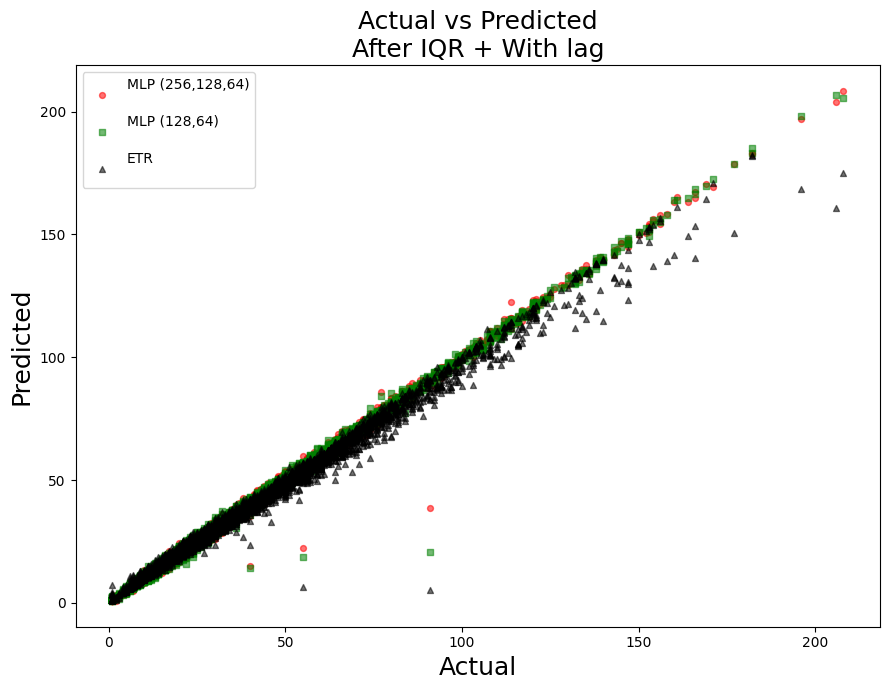

In [234]:
# =============================================================================
# ACTUAL vs PREDICTED — BEST 3 BASE MODELS
# CONDITION: AFTER IQR + WITH LAG
# Paste directly after your existing base-model code
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)


# -------------------------------------------------------------------------
# 1. Use only AFTER IQR and WITH LAG results
# -------------------------------------------------------------------------
if tbl_after_iqr is None or tbl_after_iqr.empty:
    raise ValueError(
        "tbl_after_iqr is empty. Run the BEFORE/AFTER IQR and "
        "NO_LAG/WITH_LAG comparison code first."
    )


after_iqr_with_lag_results = (
    tbl_after_iqr[
        tbl_after_iqr["Lag"] == "WITH_LAG"
    ]
    .copy()
)


if after_iqr_with_lag_results.empty:
    raise ValueError(
        "No AFTER_IQR + WITH_LAG results were found."
    )


# -------------------------------------------------------------------------
# 2. Select the best three BASE models using combined Score
# -------------------------------------------------------------------------
best_3_base = (
    after_iqr_with_lag_results
    .sort_values("Score", ascending=False)
    .drop_duplicates(subset=["Model"])
    .head(3)
    .reset_index(drop=True)
)

best_3_names = best_3_base["Model"].tolist()


print("\n" + "=" * 105)
print("BEST 3 BASE MODELS — AFTER IQR + WITH LAG")
print("=" * 105)

print(
    best_3_base[
        [
            "Stage",
            "Lag",
            "Combo",
            "Model",
            "Score",
            "Test_R2",
            "Test_MAE",
            "Test_MSE",
            "Test_RMSE",
            "Test_MAPE"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("=" * 105)


# -------------------------------------------------------------------------
# 3. Create dictionary of original base models
# -------------------------------------------------------------------------
base_model_dictionary = {
    model_name: model_object
    for model_name, model_object in MODELS
}


missing_models = [
    model_name
    for model_name in best_3_names
    if model_name not in base_model_dictionary
]


if missing_models:
    raise ValueError(
        f"Selected models are missing from MODELS: {missing_models}"
    )


# -------------------------------------------------------------------------
# 4. Prepare AFTER-IQR dataset and WITH-LAG features
# -------------------------------------------------------------------------
df_after_iqr_with_lag = df_after_iqr.copy()


# Rebuild spatial, temporal, and lag1 features
df_after_iqr_with_lag, combos_after_iqr = prepare_stage_features(
    df_after_iqr_with_lag
)


combo_name = best_3_base.iloc[0]["Combo"]


if combo_name not in combos_after_iqr:
    raise ValueError(
        f"{combo_name} was not found in the AFTER-IQR feature combinations."
    )


# Add lag1 explicitly
features = [
    feature
    for feature in combos_after_iqr[combo_name]
    if feature in df_after_iqr_with_lag.columns
]


if "lag1" not in features:
    features.append("lag1")


features = list(
    dict.fromkeys(features)
)


if not features:
    raise ValueError(
        f"No usable WITH-LAG features were found for {combo_name}."
    )


if "lag1" not in features:
    raise ValueError(
        "lag1 was not included in the feature list."
    )


print(f"\nDataset stage       : AFTER IQR")
print(f"Lag condition       : WITH LAG")
print(f"Feature combination : {combo_name}")
print(f"Number of features  : {len(features)}")
print(f"Selected models     : {best_3_names}")
print(f"Rows used initially : {len(df_after_iqr_with_lag):,}")
print(f"lag1 included       : {'lag1' in features}")


# -------------------------------------------------------------------------
# 5. Rebuild X and y using AFTER-IQR and WITH-LAG data
# -------------------------------------------------------------------------
X, y = build_Xy(
    df_after_iqr_with_lag,
    features
)


if len(X) == 0:
    raise ValueError(
        "No complete rows were available for AFTER-IQR + WITH-LAG training."
    )


print(f"Complete rows used  : {len(X):,}")


# -------------------------------------------------------------------------
# 6. Recreate same train/test split
# -------------------------------------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)


y_actual = np.asarray(
    y_te,
    dtype=float
)


print(f"Training rows       : {len(X_tr):,}")
print(f"Testing rows        : {len(X_te):,}")


# -------------------------------------------------------------------------
# 7. Train best three models and generate predictions
# -------------------------------------------------------------------------
base_predictions = {}
base_metric_rows = []


for model_name in best_3_names:

    model = clone(
        base_model_dictionary[model_name]
    )

    print(f"Training base model: {model_name}")

    model.fit(
        X_tr,
        y_tr
    )

    y_pred = np.asarray(
        model.predict(X_te),
        dtype=float
    )

    base_predictions[model_name] = y_pred


    test_r2 = r2_score(
        y_actual,
        y_pred
    )

    test_mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    test_mse = mean_squared_error(
        y_actual,
        y_pred
    )

    test_rmse = np.sqrt(
        test_mse
    )


    nonzero_mask = y_actual != 0

    if np.any(nonzero_mask):
        test_mape = mean_absolute_percentage_error(
            y_actual[nonzero_mask],
            y_pred[nonzero_mask]
        )
    else:
        test_mape = np.nan


    base_metric_rows.append(
        {
            "Stage": "AFTER_IQR",
            "Lag": "WITH_LAG",
            "Combo": combo_name,
            "Model": model_name,
            "Test_R2": test_r2,
            "Test_MAE": test_mae,
            "Test_MSE": test_mse,
            "Test_RMSE": test_rmse,
            "Test_MAPE": test_mape
        }
    )


# -------------------------------------------------------------------------
# 8. Print recalculated metrics
# -------------------------------------------------------------------------
base_prediction_metrics = pd.DataFrame(
    base_metric_rows
)


print("\n" + "=" * 105)
print("RECALCULATED TEST METRICS — AFTER IQR + WITH LAG")
print("=" * 105)

print(
    base_prediction_metrics.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("=" * 105)


# -------------------------------------------------------------------------
# 9. Plot settings
# -------------------------------------------------------------------------
markers = [
    "o",
    "s",
    "^"
]

colors = [
    "red",
    "green",
    "black"
]


# -------------------------------------------------------------------------
# 10. Actual vs Predicted — best three models in one figure
# -------------------------------------------------------------------------
plt.figure(
    figsize=(9, 7)
)


all_values = [
    y_actual
]


for index, model_name in enumerate(best_3_names):

    y_pred = base_predictions[
        model_name
    ]


    model_metrics = (
        base_prediction_metrics[
            base_prediction_metrics["Model"] == model_name
        ]
        .iloc[0]
    )


    test_r2 = model_metrics["Test_R2"]
    test_mae = model_metrics["Test_MAE"]
    test_mse = model_metrics["Test_MSE"]
    test_rmse = model_metrics["Test_RMSE"]
    test_mape = model_metrics["Test_MAPE"]


    all_values.append(
        y_pred
    )


    plt.scatter(
        y_actual,
        y_pred,
        s=18,
        alpha=0.55,
        marker=markers[index],
        color=colors[index],
        label=(
            f"{model_name}\n"
            #f"R²={test_r2:.4f}, "
            #f"MAE={test_mae:.3f}, "
            #f"RMSE={test_rmse:.3f}, "
            #f"MAPE={test_mape:.4f}"
        )
    )


# -------------------------------------------------------------------------
# 11. Perfect-prediction reference line
# -------------------------------------------------------------------------
minimum_value = min(
    np.nanmin(values)
    for values in all_values
)


maximum_value = max(
    np.nanmax(values)
    for values in all_values
)



# -------------------------------------------------------------------------
# 12. Figure formatting
# -------------------------------------------------------------------------
plt.xlabel(
    "Actual",
    fontsize=18
)

plt.ylabel(
    "Predicted",
    fontsize=18
)


plt.title(
    "Actual vs Predicted\n"
    "After IQR + With lag",
    fontsize=18
)


plt.legend(
    fontsize=10,
    loc="upper left"
)


plt.grid(False)
plt.tight_layout()
plt.show()

Apply Hybrid models (Stack and Vote) using top 3 base models 

In [189]:
# ---------------- HYBRID / STACKING over top-3 models per combo (single split) ----------------
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor,
)
from sklearn.model_selection import KFold  # for K-fold
# features for this combo

# ---------- Print feature information (only) ----------
print("\n" + "="*80)
print(f"Feature Combination : {combo_name}")
print(f"Total Features      : {len(feats)}")
print("Features:")
print(feats)
print("="*80)

# features for this combo
X, y = build_Xy(df, feats)

hybrid_rows = []

if not final_tbl.empty:
    # Get top-3 base models per combo according to single-split Score
    top3_per_combo_single = (
        final_tbl
        .sort_values(["Combo", "Score"], ascending=[True, False])
        .groupby("Combo", group_keys=False)
        .head(3)
        .reset_index(drop=True)
    )

    for combo_name, feats in BASE_COMBOS.items():
        if not feats:
            continue

        # features for this combo
        X, y = build_Xy(df, feats)
        if len(X) == 0 or X.shape[1] == 0:
            continue

        # single split (same config as eval_models_both)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )

        # top-3 model names for this combo
        subset = top3_per_combo_single[top3_per_combo_single["Combo"] == combo_name]
        base_names = subset["Model"].unique().tolist()
        if len(base_names) == 0:
            continue

        # ---- fit base models once and collect predictions (for stacking input) ----
        P_tr_list = []
        P_te_list = []
        used_bases = []

        for name in base_names:
            # find model definition in MODELS
            base_def = None
            for mname, mdl in MODELS:
                if mname == name:
                    base_def = mdl
                    break
            if base_def is None:
                continue

            est = clone(base_def)
            est.fit(X_tr, y_tr)
            P_tr_list.append(est.predict(X_tr))
            P_te_list.append(est.predict(X_te))
            used_bases.append(name)

        if len(used_bases) == 0:
            continue

        P_tr = np.vstack(P_tr_list).T  # shape (n_train, k)
        P_te = np.vstack(P_te_list).T  # shape (n_test, k)

        # also prepare fresh (name, estimator) tuples for Voting / Stacking
        bases = []
        for name in used_bases:
            base_def = None
            for mname, mdl in MODELS:
                if mname == name:
                    base_def = mdl
                    break
            if base_def is None:
                continue
            bases.append((name, clone(base_def)))

        if len(bases) == 0:
            continue

        def eval_hybrid(hname, pred_te):
            # regression metrics
            test_r2 = r2_score(y_te, pred_te)
            test_mae = mean_absolute_error(y_te, pred_te)
            test_mse = mean_squared_error(y_te, pred_te)
            test_rmse = np.sqrt(test_mse)
            test_mape = np.nanmean(
                np.abs(
                    (y_te - pred_te) /
                    np.where(np.abs(y_te) < 1e-8, np.nan, np.abs(y_te))
                )
            ) * 100

            hybrid_rows.append({
                "Combo":     combo_name,
                "Hybrid":    hname,
                "Bases":     ",".join(used_bases),
                "Test_R2":   test_r2,
                "Test_MAE":  test_mae,
                "Test_MSE":  test_mse,
                "Test_RMSE": test_rmse,
                "Test_MAPE": test_mape,
            })

        # ---- Hybrid 1: VotingRegressor (equal weights across Top-3) ----
        vote = VotingRegressor(bases)
        vote.fit(X_tr, y_tr)
        pred_vote = vote.predict(X_te)
        eval_hybrid("VOTE", pred_vote)

        # ---- Hybrid 2–4: StackingRegressor with different meta-learners ----
        if len(bases) >= 2:
            # Linear meta
            stack_lin = StackingRegressor(
                estimators=bases,
                final_estimator=LinearRegression(),
                cv=3,
                passthrough=True,
            )
           # stack_lin.fit(X_tr, y_tr)
           # pred_stack_lin = stack_lin.predict(X_te)
           # eval_hybrid("STACK_Lin", pred_stack_lin)

            # Ridge meta
            stack_ridge = StackingRegressor(
                estimators=bases,
                final_estimator=Ridge(alpha=1.0, random_state=RANDOM_STATE),
                cv=3,
                passthrough=True,
            )
            stack_ridge.fit(X_tr, y_tr)
            pred_stack_ridge = stack_ridge.predict(X_te)
            eval_hybrid("STACK_Ridge", pred_stack_ridge)

            # Gradient Boosting meta
            stack_gbr = StackingRegressor(
                estimators=bases,
                final_estimator=GradientBoostingRegressor(
                    random_state=RANDOM_STATE,
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                ),
                cv=3,
                passthrough=True,
            )
            stack_gbr.fit(X_tr, y_tr)
            pred_stack_gbr = stack_gbr.predict(X_te)
            eval_hybrid("STACK_GBR", pred_stack_gbr)

# Build hybrid score table (single split)
if hybrid_rows:
    df_h = pd.DataFrame(hybrid_rows)

    # normalize metrics and compute Score_H (same style as before)
    for mname in ["Test_R2"]:
        df_h[f"{mname}_N"] = _norm_series(df_h[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"]:
        df_h[f"{mname}_N"] = _norm_series(df_h[mname], higher_is_better=False)

    norm_cols_h = [
        "Test_R2_N", "Test_MAE_N", "Test_MSE_N",
        "Test_RMSE_N", "Test_MAPE_N",
    ]
    df_h["Score_H"] = df_h[norm_cols_h].mean(axis=1)

    df_h = df_h.sort_values("Score_H", ascending=False).reset_index(drop=True)

    print("\n=== ALL HYBRID / STACKING MODELS (single split, sorted by Score_H desc) ===")
    print(
        df_h[
            [
                "Combo","Hybrid","Bases","Score_H",
                "Test_R2","Test_MAE","Test_MSE",
                "Test_RMSE","Test_MAPE",
            ]
        ].to_string(index=False, float_format=lambda x: f"{x:.3f}")
    )



else:
    print("\nNo hybrid models were built (check that final_tbl and features are non-empty).")


Feature Combination : SPATIAL+TEMPORAL
Total Features      : 106
Features:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female_15_17', 'female_18_19', 'female_20_20', 'female_21_21', 'female_22_24', 'female_25_29', 'female_30_34', 'female_35_39', 'female_40_44', 'female_45_49', 'female_50_54', 'female_55_59', 'female_60_61', 'female_62_64', 'female_65_66', 'female_67_69', 'female_70_74', 'female_75_7

SAVE HYBRID RESULTS AFTER IQR FILTERING

In [190]:
# ============================================================
# SAVE HYBRID RESULTS AFTER IQR FILTERING
# ============================================================

if "df_h" not in globals() or df_h.empty:
    raise ValueError(
        "IQR hybrid results were not created. "
        "Run the IQR hybrid-model section first."
    )

df_h_after_iqr = df_h.copy()

print("\nSaved hybrid results after IQR filtering:")
print(
    df_h_after_iqr[
        [
                "Combo","Hybrid","Bases","Score_H",
                "Test_R2","Test_MAE","Test_MSE",
                "Test_RMSE","Test_MAPE",
            ]
        ]
    .sort_values("Score_H", ascending=False)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


Saved hybrid results after IQR filtering:
           Combo      Hybrid                             Bases  Score_H  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
SPATIAL+TEMPORAL   STACK_GBR MLP (256,128,64),MLP (128,64),ETR 1.000000 0.992504  0.460731  2.853147   1.689126   2.039255
SPATIAL+TEMPORAL STACK_Ridge MLP (256,128,64),MLP (128,64),ETR 0.145157 0.989881  0.568405  3.851159   1.962437   2.610436
SPATIAL+TEMPORAL        VOTE MLP (256,128,64),MLP (128,64),ETR 0.116358 0.989019  0.543734  4.179510   2.044385   2.408999


Predicted vs ACtual result 

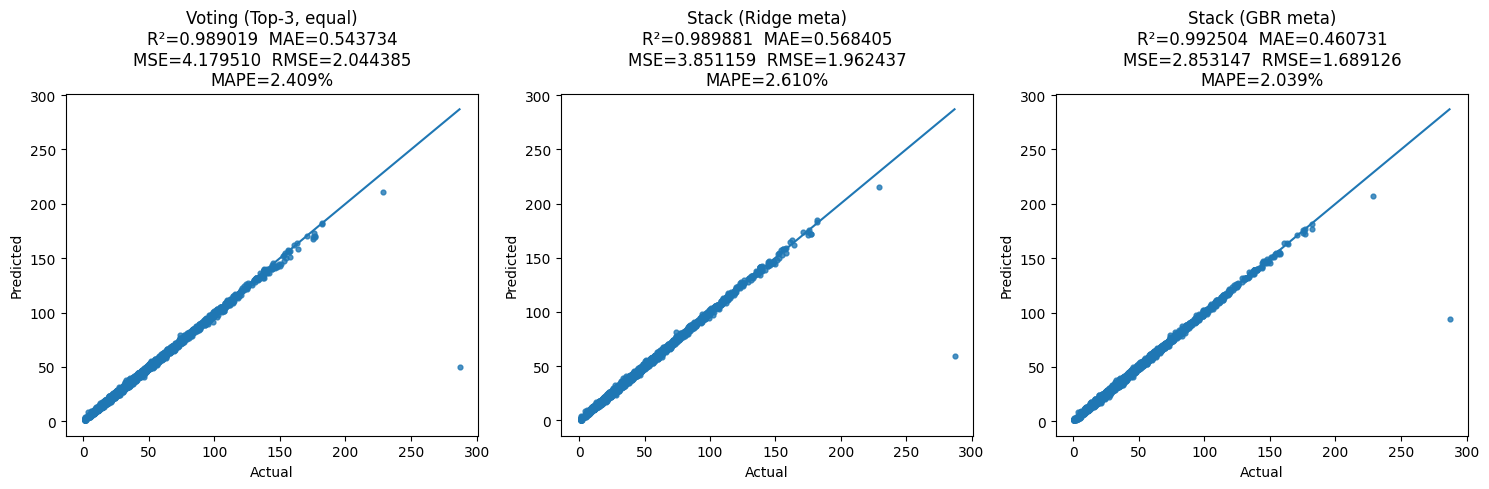

In [191]:
# ---------- 3 HYBRID ACTUAL vs PREDICTED PLOTS ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

hybrid_candidates = [
    ("Voting (Top-3, equal)", pred_vote),
    ("Stack (Ridge meta)", pred_stack_ridge),
    ("Stack (GBR meta)", pred_stack_gbr),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, pred) in zip(axes, hybrid_candidates):

    y_actual = np.asarray(y_te).astype(float)
    y_pred = np.asarray(pred).astype(float)

    r2 = r2_score(y_actual, y_pred)
    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_actual - y_pred)
            / np.clip(np.abs(y_actual), 1e-8, None)
        )
    ) * 100

    ax.scatter(
        y_actual,
        y_pred,
        s=12,
        alpha=0.8,
    )

    mn = min(y_actual.min(), y_pred.min())
    mx = max(y_actual.max(), y_pred.max())

    ax.plot(
        [mn, mx],
        [mn, mx],
        linewidth=1.5,
    )

    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

    ax.set_title(
        f"{title}\n"
        f"R²={r2:.6f}  MAE={mae:.6f}\n"
        f"MSE={mse:.6f}  RMSE={rmse:.6f}\n"
        f"MAPE={mape:.3f}%"
    )

plt.tight_layout()
plt.show()


Scatter Plot

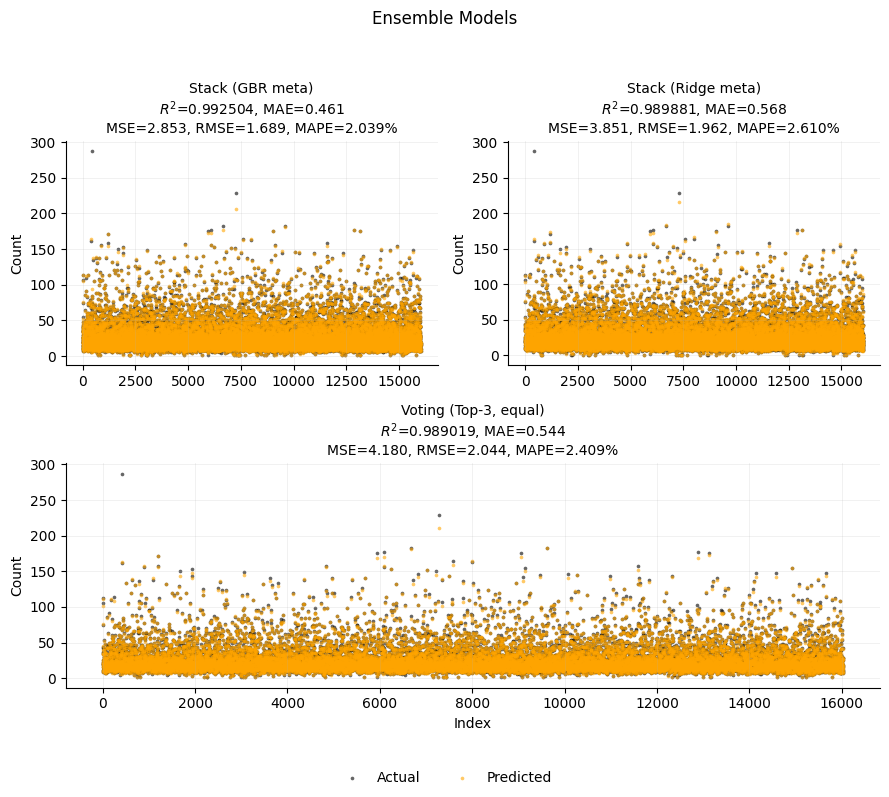

In [192]:
# ---------- Ensemble Models: 2 top + 1 wide bottom ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plots = [
    ("Stack (GBR meta)", pred_stack_gbr),
    ("Stack (Ridge meta)", pred_stack_ridge),
    ("Voting (Top-3, equal)", pred_vote),
]

fig = plt.figure(figsize=(9, 8))
gs = fig.add_gridspec(2, 2)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, :]),
]

for ax, (title, pred) in zip(axes, plots):

    y_actual = np.asarray(y_te).astype(float)
    y_pred = np.asarray(pred).astype(float)

    n = len(y_actual)
    idx = np.arange(n)

    r2 = r2_score(y_actual, y_pred)
    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_actual - y_pred) /
            np.clip(np.abs(y_actual), 1e-8, None)
        )
    ) * 100

    ax.scatter(
        idx,
        y_actual,
        s=7,
        alpha=0.6,
        c="black",
        linewidths=0,
        label="Actual"
    )

    ax.scatter(
        idx,
        y_pred,
        s=7,
        alpha=0.6,
        c="orange",
        linewidths=0,
        label="Predicted"
    )

    ax.set_title(
        f"{title}\n"
        f"$R^2$={r2:.6f}, MAE={mae:.3f}\n"
        f"MSE={mse:.3f}, RMSE={rmse:.3f}, MAPE={mape:.3f}%",
        fontsize=10
    )

    ax.set_ylabel("Count")
    ax.grid(True, linewidth=0.5, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[2].set_xlabel("Index")

handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Ensemble Models",
    fontsize=12,
    y=0.98
)

fig.tight_layout(
    rect=[0, 0.06, 1, 0.95]
)

plt.show()

Combine plot of 3 Hybrid Model

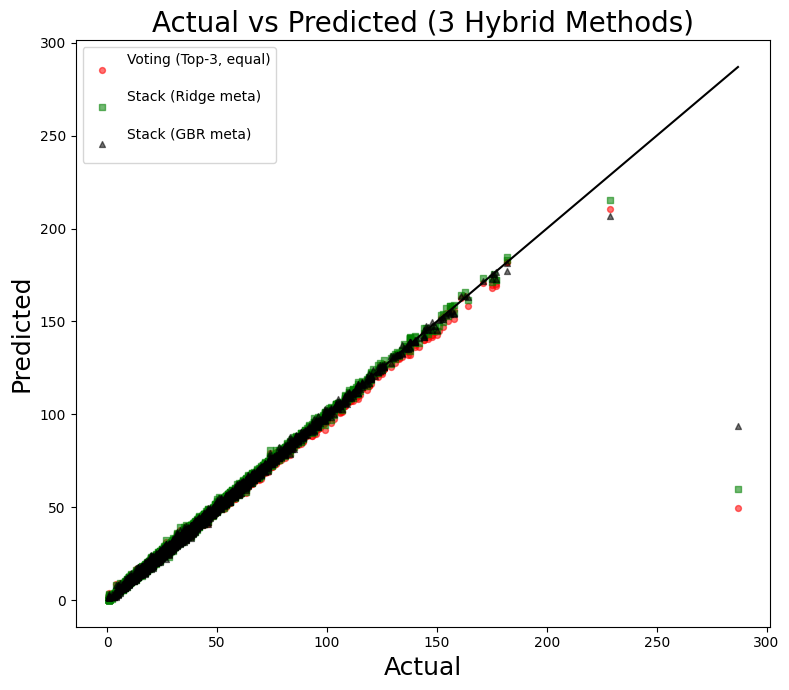

In [193]:
# ---------- Actual vs Predicted: 3 methods in one plot ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_actual = np.asarray(y_te).astype(float)

methods = [
    ("Voting (Top-3, equal)", pred_vote, "o", "red"),
    ("Stack (Ridge meta)", pred_stack_ridge, "s", "green"),
    ("Stack (GBR meta)", pred_stack_gbr, "^", "black"),
]

plt.figure(figsize=(8, 7))

for name, pred, marker, color in methods:

    y_pred = np.asarray(pred).astype(float)

    r2 = r2_score(y_actual, y_pred)
    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_actual - y_pred) /
            np.clip(np.abs(y_actual), 1e-8, None)
        )
    ) * 100

    plt.scatter(
        y_actual,
        y_pred,
        s=18,
        alpha=0.55,
        marker=marker,
        color=color,
        label=(
            f"{name}\n"
           # f"R²={r2:.4f}, MAE={mae:.3f}, "
           # f"MSE={mse:.3f}, RMSE={rmse:.3f}, "
           # f"MAPE={mape:.3f}%"
        )
    )

mn = min(
    y_actual.min(),
    np.asarray(pred_vote).min(),
    np.asarray(pred_stack_ridge).min(),
    np.asarray(pred_stack_gbr).min()
)

mx = max(
    y_actual.max(),
    np.asarray(pred_vote).max(),
    np.asarray(pred_stack_ridge).max(),
    np.asarray(pred_stack_gbr).max()
)

plt.plot(
    [mn, mx],
    [mn, mx],
    color="black",
    linewidth=1.5
)

plt.xlabel("Actual", fontsize=18)
plt.ylabel("Predicted", fontsize=18)
plt.title("Actual vs Predicted (3 Hybrid Methods)", fontsize=20)

plt.legend(fontsize=10, loc="upper left")
plt.grid(False)
plt.tight_layout()
plt.show()

Predicted Vs Actual without uncertainty

In [195]:
# ============================================================
# BEST-3 HYBRID RESULTS — PRINT 10 ROWS PER MODEL
# Supports: VOTE, STACK_Ridge, STACK_GBR, BAG_<base>
# Paste this AFTER your HYBRID block, after df_h is created.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    VotingRegressor,
    StackingRegressor,
    GradientBoostingRegressor,
    BaggingRegressor
)
from sklearn.linear_model import Ridge

# -------------------- helpers: column pickers --------------------
def _pick_col(cols, df_):
    for c in cols:
        if c in df_.columns:
            return c
    return None

def _fmt_date_yyyymmdd(x):
    s = str(x)

    if s.isdigit() and len(s) == 8:
        return s

    try:
        return pd.to_datetime(x).strftime("%Y%m%d")
    except Exception:
        return s

# -------------------- pick POI columns on df_after --------------------
# ============================================================
# Save processed dataset and feature combinations
# ============================================================

df_after = df.copy()

BASE_COMBOS_AFTER = BASE_COMBOS.copy()

df_good = df_after
BASE_COMBOS = BASE_COMBOS_AFTER

poi_id_col = _pick_col(
    ["poi_id", "POI_ID", "POIID", "lake_id", "id"],
    df_good
)

if poi_id_col is None:
    df_good["poi_id"] = 0
    poi_id_col = "poi_id"

poi_name_col = _pick_col(
    ["poi", "POI_NAME", "poi_name", "lake_name", "LAKE_NAME", "site_name", "NAME", "name"],
    df_good
)

date_col = _pick_col(
    ["date", "DATE", "Date"],
    df_good
)

if date_col is None:
    raise ValueError("Could not find a date column in df_after.")

# -------------------- build top-3 hybrid list --------------------
if "Score_H" not in df_h.columns:
    raise ValueError("df_h must contain Score_H.")

top3_h = (
    df_h
    .sort_values("Score_H", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

print("\n=== ALL HYBRID / STACKING MODELS (single split, sorted by Score_H desc) ===")

print(
    df_h[
        [
            "Combo",
            "Hybrid",
            "Bases",
            "Score_H",
            "Test_R2",
            "Test_MAE",
            "Test_MSE",
            "Test_RMSE",
            "Test_MAPE",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# -------------------- run per top-3 hybrid --------------------
for hr in top3_h.itertuples(index=False):

    combo_name = hr.Combo
    hybrid_nm = hr.Hybrid

    feats = BASE_COMBOS.get(combo_name, None)

    if not feats:
        continue

    feats = [f for f in feats if f in df_good.columns]

    # Build X,y using your helper
    X, y = build_Xy(df_good, feats)

    if len(X) == 0 or X.shape[1] == 0:
        continue

    idx_all = np.arange(len(y))

    X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
        X,
        y,
        idx_all,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Base model names
    base_names = [
        s.strip()
        for s in str(hr.Bases).split(",")
        if s.strip()
    ]

    bases = []

    for name in base_names:

        base_def = None

        for mname, mdl in MODELS:
            if mname == name:
                base_def = mdl
                break

        if base_def is None:
            continue

        bases.append(
            (name, clone(base_def))
        )

    if len(bases) == 0:
        continue

    # -------------------- build hybrid --------------------
    if hybrid_nm == "VOTE":

        model = VotingRegressor(bases)

    elif hybrid_nm == "STACK_Ridge":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=Ridge(alpha=1.0),
            cv=3,
            passthrough=True
        )

    elif hybrid_nm == "STACK_GBR":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
            ),
            cv=3,
            passthrough=True
        )

    elif str(hybrid_nm).startswith("BAG_"):

        base_nm = str(hybrid_nm).replace("BAG_", "")

        base_def = None

        for mname, mdl in MODELS:
            if mname == base_nm:
                base_def = mdl
                break

        if base_def is None:
            print(f"[skip] Could not find base model for {hybrid_nm}")
            continue

        model = BaggingRegressor(
            estimator=clone(base_def),
            n_estimators=25,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    else:
        continue

    model.fit(X_tr, y_tr)
    pred_te = model.predict(X_te)

    # -------------------- PRINT rows --------------------
    print(f"\n=== {hybrid_nm} | {combo_name} ===")
    print("POI_ID | POI_NAME | DATE | Actual | Predicted")

    mask = df_good[feats].notna().all(axis=1).to_numpy()
    df_aligned = df_good.loc[mask].reset_index(drop=True)

    n_print = min(10, len(idx_te), len(pred_te))

    for i in range(n_print):

        row = df_aligned.iloc[idx_te[i]]

        pid = (
            float(row[poi_id_col])
            if pd.notna(row[poi_id_col])
            else np.nan
        )

        if poi_name_col is None:
            pname = (
                f"POI_{int(pid)}"
                if np.isfinite(pid)
                else "POI_-1"
            )

        else:
            pname = row[poi_name_col]

            if pd.isna(pname) or str(pname).strip() in ("", "nan", "None"):
                pname = (
                    f"POI_{int(pid)}"
                    if np.isfinite(pid)
                    else "POI_-1"
                )

        d = _fmt_date_yyyymmdd(row[date_col])

        a = int(round(float(y_te[i])))
        p = int(round(float(pred_te[i])))

        print(f"{pid:.1f} | {pname} | {d} | {a} | {p}")

    print(f"\nDisplayed {n_print} sample rows.")


=== ALL HYBRID / STACKING MODELS (single split, sorted by Score_H desc) ===
           Combo      Hybrid                             Bases  Score_H  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
SPATIAL+TEMPORAL   STACK_GBR MLP (256,128,64),MLP (128,64),ETR 1.000000 0.992504  0.460731  2.853147   1.689126   2.039255
SPATIAL+TEMPORAL STACK_Ridge MLP (256,128,64),MLP (128,64),ETR 0.145157 0.989881  0.568405  3.851159   1.962437   2.610436
SPATIAL+TEMPORAL        VOTE MLP (256,128,64),MLP (128,64),ETR 0.116358 0.989019  0.543734  4.179510   2.044385   2.408999

=== STACK_GBR | SPATIAL+TEMPORAL ===
POI_ID | POI_NAME | DATE | Actual | Predicted
1500.0 | Laing Lake | 20221210 | 15 | 15
4270.0 | West Brady | 20220530 | 11 | 11
5720.0 | Glenn Cunningham | 20220313 | 42 | 37
4565.0 | Lake Maloney | 20220312 | 10 | 10
5720.0 | Glenn Cunningham | 20220429 | 37 | 36
2780.0 | Calamus Reservoir | 20220103 | 20 | 20
4720.0 | North Platte I-80 Lake | 20220818 | 21 | 21
3710.0 | Lewis & Clark Lake

Predicted Vs Actual with uncertainty

Predict visitation using the trained hybrid model and estimate uncertainty from the standard deviation of the base-model predictions plus **5% of the hybrid prediction** (with a minimum threshold). The **5% term accounts for scale-dependent uncertainty**, while the standard deviation measures disagreement among the base models. Report the final result as **Prediction ± Uncertainty** with the corresponding prediction range.

 OUTPUT: Predicted Visits = 90 ± 4
 for given date and POI


Predicted Vs Actual with range like 100+-3 

1. **Feature Engineering:** Convert the input date into temporal features (e.g., day, week, month, season, weekend) and combine them with the selected predictor variables.

2. **Hybrid Model Training:** Select and train the best-performing hybrid model using the chosen feature combination.

3. **POI–Date Matching:** Match the selected POI with records from the same calendar date (month–day) across available years and prepare the prediction input.

4. **Prediction & Uncertainty:** Predict visitation using the trained hybrid model and estimate uncertainty from the standard deviation of the base-model predictions plus uncertinity 

 OUTPUT: Predicted Visits = 90 ± 4
 for given date and POI


Formula 1: Historical Robust Standard Deviation
"Historical Robust SD"=1.4826×"MAD"

where
"MAD"="Median" (∣x_i-"Median" ∣)

 
Formula 2: Historical Standard Error
"Historical SE"="Historical Robust SD" /√n

where:
    n= number of historical observations. 
 
Formula 3: Predicted Visits
"Predicted Visits"="Hybrid Model Prediction"±"Historical SE"

 
Example
Historical visits for the same lake and date:
Year	Visits
2022	115
2023	118
2024	122
Step 1: Median
"Median"=118

Step 2: MAD
∣115-118∣=3
∣118-118∣=0
∣122-118∣=4
"MAD"="Median" (3,0,4)=3

Step 3: Historical Robust SD
"Historical Robust SD"=1.4826×3=4.45

Step 4: Historical Standard Error
Number of historical observations:
n=3
"Historical SE"=4.45/√3=4.45/1.732=2.57

The code rounds the uncertainty to the nearest integer:
"Prediction Uncertainty"="round" (2.57)=3

Step 5: Final Prediction
Suppose the hybrid model predicts 120 visits.
"Predicted Visits"=120±3

Prediction range:
120-3=117
120+3=123



In [196]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    VotingRegressor,
    StackingRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import Ridge


df_use = df_after if "df_after" in globals() else df


def predict_selected_poi_date(poi_value, input_date):

    df_use2 = df_use.copy()

    # -------------------- Add extra temporal features --------------------
    # Keep original date values before conversion
    raw_date = df_use2["date"].copy()

    # Clean values such as 20230715.0
    clean_date = (
        raw_date
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

    # First try YYYYMMDD format
    parsed_date = pd.to_datetime(
        clean_date,
        format="%Y%m%d",
        errors="coerce"
    )

    # Try general date parsing for remaining values
    bad = parsed_date.isna()

    parsed_date.loc[bad] = pd.to_datetime(
        clean_date.loc[bad],
        errors="coerce"
    )

    df_use2["date"] = parsed_date

    print("\nDate parsing:")
    print("Total rows   :", len(df_use2))
    print("Valid dates  :", df_use2["date"].notna().sum())
    print("Invalid dates:", df_use2["date"].isna().sum())

    df_use2["dow"] = df_use2["date"].dt.dayofweek
    df_use2["is_weekend"] = (df_use2["dow"] >= 5).astype(int)

    df_use2["week"] = (
        df_use2["date"]
        .dt.isocalendar()
        .week
        .astype("Int64")
    )

    df_use2["month"] = df_use2["date"].dt.month
    df_use2["day"] = df_use2["date"].dt.day

    df_use2["season"] = df_use2["month"].apply(
        lambda m:
        0 if m in [12, 1, 2] else
        1 if m in [3, 4, 5] else
        2 if m in [6, 7, 8] else
        3 if pd.notna(m) else np.nan
    )

    df_use2["date_ordinal"] = df_use2["date"].map(
        lambda x: x.toordinal()
        if pd.notna(x)
        else np.nan
    )

    df_use2["is_month_start"] = (
        df_use2["date"]
        .dt.is_month_start
        .astype(int)
    )

    df_use2["is_month_end"] = (
        df_use2["date"]
        .dt.is_month_end
        .astype(int)
    )

    df_use2["is_quarter_start"] = (
        df_use2["date"]
        .dt.is_quarter_start
        .astype(int)
    )

    df_use2["is_quarter_end"] = (
        df_use2["date"]
        .dt.is_quarter_end
        .astype(int)
    )

    if "poi_id" in df_use2.columns:

        df_use2["poi_id_code"] = (
            df_use2["poi_id"]
            .astype("category")
            .cat.codes
        )

    # -------------------- Best VOTE Hybrid --------------------
    # VOTE produced the best test MAE/R² in the hybrid comparison,
    # so restrict selection to VOTE rows instead of selecting the
    # overall highest Score_H row (which previously selected STACK_GBR).

   

    best_h  = (
        df_h
        .sort_values("Score_H", ascending=False).iloc[0]
     
    )

    combo_name = best_h["Combo"]
    hybrid_nm =  best_h["Hybrid"]

    print("\nSelected hybrid model:")
    print("Hybrid      :", hybrid_nm)
    print("Feature Combo:", combo_name)
    print("Score_H     :", best_h["Score_H"])

    feats = (
        BASE_COMBOS_AFTER[combo_name]
        if "BASE_COMBOS_AFTER" in globals()
        else BASE_COMBOS[combo_name]
    )

    extra_feats = [
        "is_weekend",
        "season",
        "month",
        "week",
        "dow",
        "day",
        "date_ordinal",
        "is_month_start",
        "is_month_end",
        "is_quarter_start",
        "is_quarter_end",
        "poi_id_code"
    ]

    feats = list(
        dict.fromkeys(
            list(feats) + extra_feats
        )
    )

    feats = [
        f for f in feats
        if f in df_use2.columns
    ]

    # -------------------- Build X, y, aligned df --------------------
    X, y = build_Xy(
        df_use2,
        feats
    )

    mask = (
        df_use2[feats]
        .notna()
        .all(axis=1)
    )

    df_aligned = (
        df_use2.loc[mask]
        .reset_index(drop=True)
    )

    n = min(
        len(X),
        len(y),
        len(df_aligned)
    )

    print("\nRows after feature preparation:")
    print("Rows returned by build_Xy:", len(X))
    print("Target rows              :", len(y))
    print("Aligned dataframe rows   :", len(df_aligned))
    print("Final usable rows        :", n)

    if n == 0:

        print("\nNo valid rows remain after feature filtering.")

        print("\nFeatures with the most missing values:")

        missing_summary = (
            df_use2[feats]
            .isna()
            .sum()
            .sort_values(ascending=False)
        )

        print(
            missing_summary
            .head(30)
            .to_string()
        )

        print("\nFeatures used:")
        print(feats)

        return None

    X = X[:n]

    y = (
        np.asarray(y)
        .reshape(-1)[:n]
    )

    df_aligned = (
        df_aligned
        .iloc[:n]
        .reset_index(drop=True)
    )

    # Store actual historical target values
    df_aligned["_historical_visits"] = y

    if n < 2:

        print(
            "\nNot enough valid rows for train/test splitting. "
            f"Valid rows: {n}"
        )

        return None

    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    print("\nFeatures used:")
    print(feats)
    print("Total features:", len(feats))

    print(
        "Extra features present:",
        [
            f for f in extra_feats
            if f in feats
        ]
    )

    # -------------------- Columns --------------------
    poi_id_col = "poi_id"

    poi_name_col = (
        "poi"
        if "poi" in df_aligned.columns
        else poi_id_col
    )

    date_col = "date"

    # -------------------- Base Models --------------------
    base_names = [
        s.strip()
        for s in str(best_h["Bases"]).split(",")
        if s.strip()
    ]

    bases = []

    for name in base_names:

        for mname, mdl in MODELS:

            if mname == name:

                bases.append(
                    (
                        name,
                        clone(mdl)
                    )
                )

                break

    if len(bases) == 0:

        print("No base models found.")
        print("Requested base models:", base_names)

        return None

    # -------------------- Hybrid Model --------------------
    if hybrid_nm == "VOTE":

        model = VotingRegressor(
            estimators=bases
        )

    elif hybrid_nm == "STACK_Ridge":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=Ridge(
                alpha=1.0
            ),
            cv=2,
            passthrough=False
        )

    elif hybrid_nm == "STACK_GBR":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                n_estimators=50,
                learning_rate=0.05,
                max_depth=2
            ),
            cv=2,
            passthrough=False
        )

    else:

        print(
            f"Unknown hybrid model: {hybrid_nm}"
        )

        return None

    model.fit(
        X_tr,
        y_tr
    )

    # -------------------- POI Matching --------------------
    df_temp = df_aligned.copy()

    df_temp["_poi_num"] = pd.to_numeric(
        df_temp[poi_id_col],
        errors="coerce"
    )

    poi_num = pd.to_numeric(
        poi_value,
        errors="coerce"
    )

    if pd.notna(poi_num):

        poi_mask = (
            df_temp["_poi_num"]
            == float(poi_num)
        )

    else:

        poi_mask = (
            df_temp[poi_name_col]
            .astype(str)
            .str.lower()
            .str.contains(
                str(poi_value).lower(),
                na=False
            )
        )

    if poi_mask.sum() == 0:

        print("POI/Lake not found.")

        print("\nAvailable POI examples:")

        print(
            df_temp[
                [
                    poi_id_col,
                    poi_name_col
                ]
            ]
            .drop_duplicates()
            .head(20)
            .to_string(index=False)
        )

        return None

    # -------------------- Date Matching --------------------
    df_temp["_date_parsed"] = pd.to_datetime(
        df_temp[date_col],
        errors="coerce"
    )

    bad_date_mask = (
        df_temp["_date_parsed"]
        .isna()
    )

    df_temp.loc[
        bad_date_mask,
        "_date_parsed"
    ] = pd.to_datetime(
        df_temp.loc[
            bad_date_mask,
            date_col
        ]
        .astype(str)
        .str.replace(
            r"\.0$",
            "",
            regex=True
        ),
        format="%Y%m%d",
        errors="coerce"
    )

    df_temp["_month_day"] = (
        df_temp["_date_parsed"]
        .dt.strftime("%m-%d")
    )

    try:

        input_date_string = (
            str(input_date)
            .strip()
        )

        if "-" in input_date_string:

            dt = pd.to_datetime(
                "2024-" + input_date_string,
                format="%Y-%m-%d",
                errors="raise"
            )

        else:

            dt = pd.to_datetime(
                input_date_string + " 2024",
                errors="raise"
            )

        target_md = dt.strftime(
            "%m-%d"
        )

    except Exception:

        print(
            "Invalid date. Use 07-04 or July 4."
        )

        return None

    matched = df_temp.loc[
        poi_mask
        & (
            df_temp["_month_day"]
            == target_md
        )
    ].copy()

    if matched.empty:

        print(
            "No matching POI and date found."
        )

        print(
            "\nAvailable dates for this POI:"
        )

        available = (
            df_temp.loc[
                poi_mask,
                [
                    date_col,
                    "_month_day"
                ]
            ]
            .dropna()
            .drop_duplicates()
            .sort_values(date_col)
        )

        print(
            available.to_string(
                index=False
            )
        )

        return None

    # -------------------- Historical Same-Date Data --------------------
    historical = (
        matched[
            [
                "_date_parsed",
                "_historical_visits"
            ]
        ]
        .dropna()
        .sort_values("_date_parsed")
        .copy()
    )

    historical["Year"] = (
        historical["_date_parsed"]
        .dt.year
    )

    historical["Date"] = (
        historical["_date_parsed"]
        .dt.strftime("%Y-%m-%d")
    )

    historical = historical.rename(
        columns={
            "_historical_visits":
            "Actual_Visits"
        }
    )

    historical = (
        historical[
            [
                "Year",
                "Date",
                "Actual_Visits"
            ]
        ]
        .reset_index(drop=True)
    )

    historical_mean = float(
        historical["Actual_Visits"]
        .mean()
    )

    historical_min = float(
        historical["Actual_Visits"]
        .min()
    )

    historical_max = float(
        historical["Actual_Visits"]
        .max()
    )

    historical_std = float(
        historical["Actual_Visits"]
        .std(ddof=0)
    )

    # If multiple years have the same month-day,
    # average the feature rows
    row = (
        matched[feats]
        .mean(numeric_only=True)
        .to_frame()
        .T
    )

    # -------------------- Overwrite requested-date features --------------------
    update_vals = {
        "dow": dt.dayofweek,
        "is_weekend": int(
            dt.dayofweek >= 5
        ),
        "week": int(
            dt.isocalendar().week
        ),
        "month": dt.month,
        "day": dt.day,

        "season": (
            0 if dt.month in [12, 1, 2] else
            1 if dt.month in [3, 4, 5] else
            2 if dt.month in [6, 7, 8] else
            3
        ),

        "date_ordinal": dt.toordinal(),
        "is_month_start": int(
            dt.is_month_start
        ),
        "is_month_end": int(
            dt.is_month_end
        ),
        "is_quarter_start": int(
            dt.is_quarter_start
        ),
        "is_quarter_end": int(
            dt.is_quarter_end
        )
    }

    for c, v in update_vals.items():

        if c in row.columns:
            row[c] = v

    # Ensure all features are available in prediction row
    missing_prediction_features = [
        f for f in feats
        if f not in row.columns
    ]

    if missing_prediction_features:

        print(
            "\nMissing prediction features:"
        )

        print(
            missing_prediction_features
        )

        return None

    if row[feats].isna().any().any():

        print(
            "\nPrediction row contains missing values:"
        )

        print(
            row[feats]
            .isna()
            .sum()
            .loc[
                lambda s: s > 0
            ]
        )

        return None

    # -------------------- Predict --------------------
    X_new = row[feats]

    pred_raw = float(
        model.predict(
            X_new
        )[0]
    )

    # -------------------- Historical Lake-and-Date Uncertainty --------------------
    # Historical values for this lake and the same calendar date
    hist_values = (
        historical["Actual_Visits"]
        .dropna()
        .to_numpy(dtype=float)
    )

    n_hist = len(hist_values)

    if n_hist >= 2:

        # Robust historical variability using median absolute deviation (MAD)
        hist_median = float(np.median(hist_values))

        hist_mad = float(
            np.median(
                np.abs(hist_values - hist_median)
            )
        )

        # Convert MAD to a robust standard-deviation estimate
        robust_hist_sd = 1.4826 * hist_mad

        # Historical standard error for this lake and calendar date
        historical_se = robust_hist_sd / np.sqrt(n_hist)

    else:

        robust_hist_sd = 0.0
        historical_se = 0.0

    # Use only historical uncertainty; no individual base-model predictions
    pm = historical_se

    pred = int(
        round(
            max(
                0,
                pred_raw
            )
        )
    )

    # Display uncertainty and range as integers
    pm = max(1, int(round(pm)))

    lower = max(0, pred - pm)
    upper = pred + pm

    lake_id = (
        matched
        .iloc[0][poi_id_col]
    )

    lake_name = (
        matched
        .iloc[0][poi_name_col]
    )

    # -------------------- Print Prediction --------------------
    print("\n==============================")
    print("Prediction")
    print("==============================")
    print(f"Lake ID          : {lake_id}")
    print(f"Lake Name        : {lake_name}")
    print(f"Date             : {input_date}")
    print(f"Matched Date     : {target_md}")
    print(f"Rows Used        : {len(matched)}")
    print(f"Hybrid Model     : {hybrid_nm}")
    print(f"Feature Combo        : {combo_name}")
    print(f"Historical Robust SD : {robust_hist_sd:.2f}")
    print(f"Historical SE        : {historical_se:.2f}")
    print(f"Predicted Visits     : {pred} ± {pm}")
    print(f"Prediction Range     : ({lower} - {upper})")

    # -------------------- Print Historical Data --------------------
    print("\n==============================")
    print("Historical Same-Date Data")
    print("==============================")

    historical_display = historical.copy()

    historical_display["Actual_Visits"] = (
        historical_display["Actual_Visits"]
        .round(2)
    )

    print(
        historical_display.to_string(
            index=False
        )
    )

    print(
        f"\nHistorical Average : "
        f"{historical_mean:.2f}"
    )

    print(
        f"Historical Minimum : "
        f"{historical_min:.2f}"
    )

    print(
        f"Historical Maximum : "
        f"{historical_max:.2f}"
    )

    print(
        f"Historical Std Dev : "
        f"{historical_std:.2f}"
    )

    

In [197]:
# -------------------- example --------------------
predict_selected_poi_date(6080, "01-03")
#predict_selected_poi_date(6080, "01-04")
#predict_selected_poi_date(6080, "01-05")
#predict_selected_poi_date(6080, "02-03")
#predict_selected_poi_date(6080, "02-15")




Date parsing:
Total rows   : 80216
Valid dates  : 80216
Invalid dates: 0

Selected hybrid model:
Hybrid      : STACK_GBR
Feature Combo: SPATIAL+TEMPORAL
Score_H     : 1.0

Rows after feature preparation:
Rows returned by build_Xy: 80128
Target rows              : 80128
Aligned dataframe rows   : 80128
Final usable rows        : 80128

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(


Visualization of 5 Metrics after applying IQR

/var/folders/1d/g4zmv0kx6v910p8sldg41zfr0000gr/T/ipykernel_46945/2400728361.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])


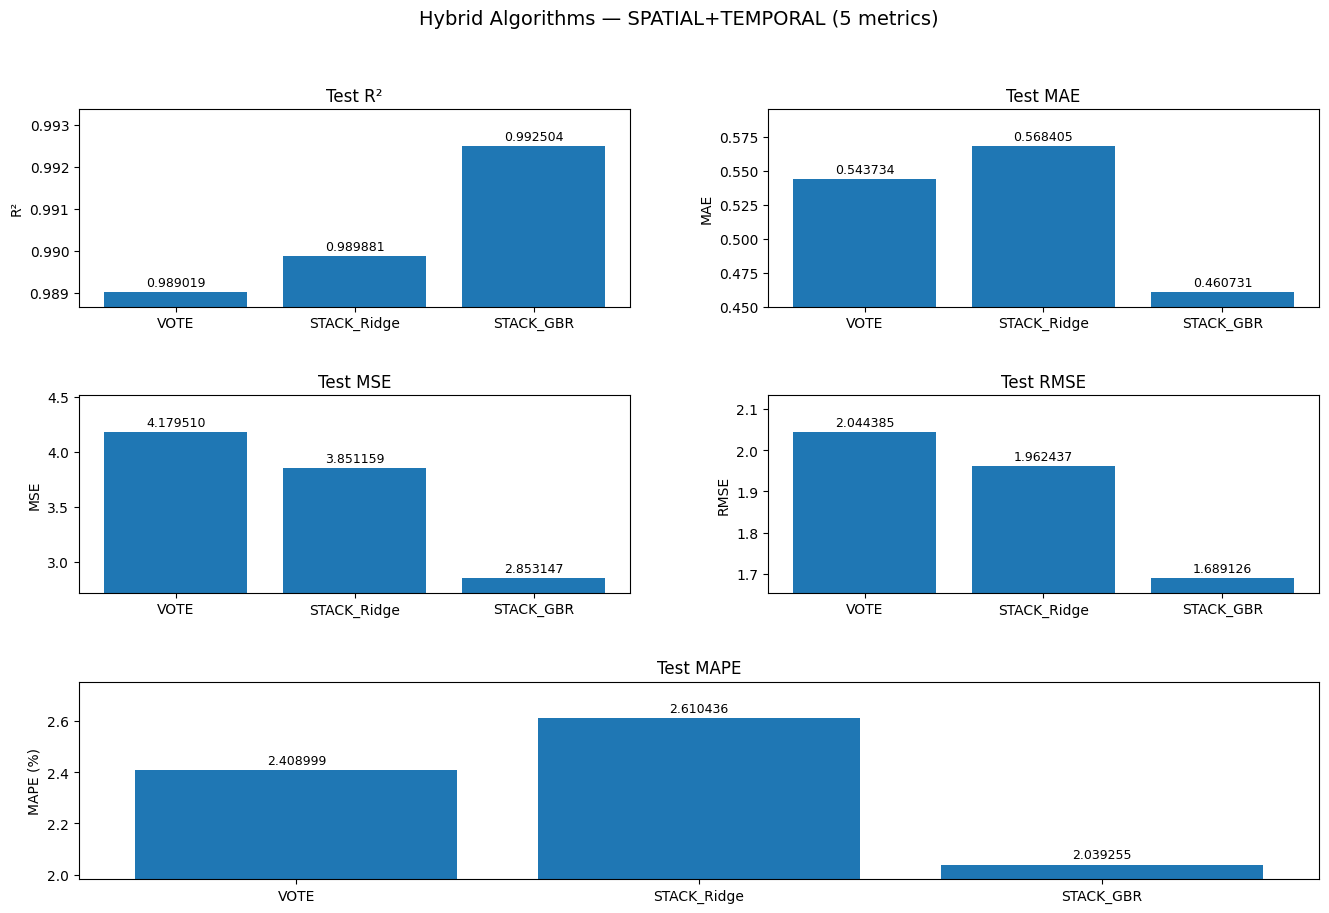

In [198]:
import numpy as np
import matplotlib.pyplot as plt

HYBRID_ORDER = ["VOTE", "STACK_Ridge", "STACK_GBR"]

def _prep_hybrid_values(df_h, metric, order=HYBRID_ORDER):
    # returns (labels, vals) in fixed order
    if df_h is None or len(df_h) == 0 or metric not in df_h.columns:
        return None, None

    d = df_h[["Hybrid", metric]].dropna(subset=["Hybrid", metric]).copy()
    if len(d) == 0:
        return None, None

    # one value per hybrid: take BEST by Score_H if available, else mean
    if "Score_H" in df_h.columns:
        d = (df_h[["Hybrid", metric, "Score_H"]]
             .dropna(subset=["Hybrid", metric])
             .sort_values(["Hybrid", "Score_H"], ascending=[True, False])
             .drop_duplicates("Hybrid", keep="first")[["Hybrid", metric]])
    else:
        d = d.groupby("Hybrid", as_index=False)[metric].mean()

    present = [h for h in order if h in set(d["Hybrid"].tolist())]
    if len(present) == 0:
        return None, None

    d = d.set_index("Hybrid").reindex(present).reset_index()
    labels = d["Hybrid"].tolist()
    vals = d[metric].to_numpy(dtype=float)
    return labels, vals

def plot_5_hybrid_metrics_2_2_1(
    df_h,
    metrics=("Test_R2", "Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"),  # 5 blocks
    titles=None,
    ylabels=None,
    fmt="{:.6f}",
    suptitle="Hybrid Algorithms — SPATIAL+TEMPORAL (5 metrics)"
):
    if titles is None:
        titles = {
            "Test_R2": "Test R²",
            "Test_MAE": "Test MAE",
            "Test_MSE": "Test MSE",
            "Test_RMSE": "Test RMSE",
            "Test_MAPE": "Test MAPE",
        }
    if ylabels is None:
        ylabels = {
            "Test_R2": "R²",
            "Test_MAE": "MAE",
            "Test_MSE": "MSE",
            "Test_RMSE": "RMSE",
            "Test_MAPE": "MAPE (%)",
        }

    # Layout: row1=2, row2=2, row3=1 centered (spans both columns)
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1], hspace=0.45, wspace=0.25)

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[2, :]),  # last row spans both columns -> centered
    ]

    for ax, metric in zip(axes, metrics):
        labels, vals = _prep_hybrid_values(df_h, metric)

        if labels is None:
            ax.set_title(f"{titles.get(metric, metric)} (no data)")
            ax.axis("off")
            continue

        x = np.arange(len(labels))
        bars = ax.bar(x, vals)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=0)
        ax.set_title(titles.get(metric, metric))
        ax.set_ylabel(ylabels.get(metric, metric))

        # no scientific offset text
        ax.ticklabel_format(style="plain", axis="y", useOffset=False)
        ax.yaxis.get_major_formatter().set_scientific(False)
        ax.yaxis.get_major_formatter().set_useOffset(False)

        # y-limits with headroom
        y_min, y_max = float(np.min(vals)), float(np.max(vals))
        rng = (y_max - y_min) if (y_max != y_min) else (abs(y_max) if y_max != 0 else 1.0)
        ax.set_ylim(y_min - 0.10*rng, y_max + 0.25*rng)

        # value labels
        pad = 0.02 * rng
        for rect, v in zip(bars, vals):
            ax.text(rect.get_x() + rect.get_width()/2,
                    rect.get_height() + pad,
                    fmt.format(v),
                    ha="center", va="bottom", fontsize=9)

    fig.suptitle(suptitle, fontsize=14, y=0.98)
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
    plt.show()

# ---- Call it (row1:2, row2:2, row3:1 centered) ----
plot_5_hybrid_metrics_2_2_1(
    df_h,
    metrics=("Test_R2", "Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"),
    suptitle="Hybrid Algorithms — SPATIAL+TEMPORAL (5 metrics)"
)

Best 20 features 

/var/folders/1d/g4zmv0kx6v910p8sldg41zfr0000gr/T/ipykernel_46945/119721240.py:9: DtypeWarning: Columns (0: home_origin) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH)


Numeric features: ['poi_id', 'date', 'count', 'duration', 'hh00', 'hh01', 'hh02', 'hh03', 'hh04', 'hh05', 'hh06', 'hh07', 'hh08', 'hh09', 'hh10', 'hh11', 'hh12', 'hh13', 'hh14', 'hh15', 'hh16', 'hh17', 'hh18', 'hh19', 'hh20', 'hh21', 'hh22', 'hh23', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female_15_17', 'female_18_19', 'female_20_20', 'female_21_21', 'female_22_24', 'female_25_29', 'female_30_34', 'female_3

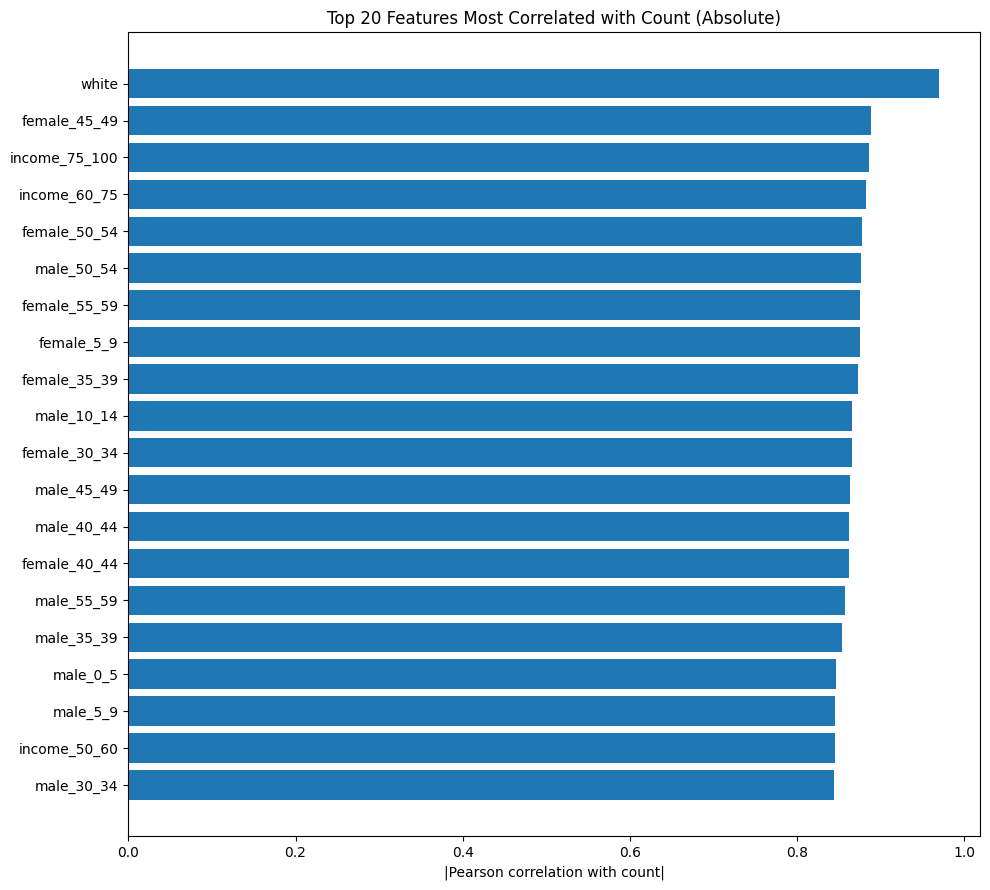

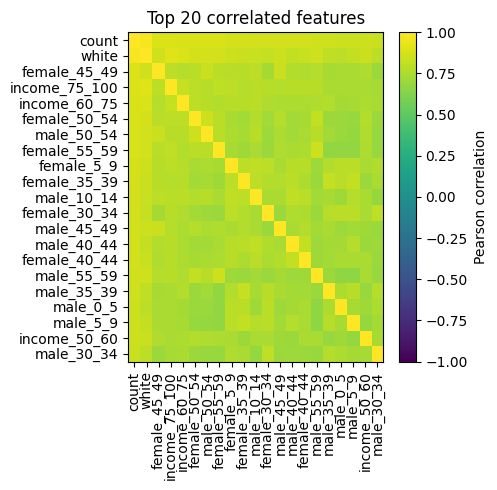

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"
# -------------------------
df = pd.read_csv(PATH)

# Ensure target is numeric
df["count"] = pd.to_numeric(df["count"], errors="coerce")

# -------------------------
# Select numeric features
# -------------------------
num_df = df.select_dtypes(include=[np.number]).dropna()

print("Numeric features:", num_df.columns.tolist())

# -------------------------
# Correlation matrix
# -------------------------
corr_matrix = num_df.corr(method="pearson")

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Top-20 features by |correlation|
# -------------------------
top20 = (
    corr_matrix["count"]
    .drop("count")
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

top20_feats = top20.index.tolist()

# =========================
# (A) Bar chart: Top-20 |corr|
# =========================
plt.figure(figsize=(10, 9))
vals = top20.sort_values()  # so bars go from small->large
y = np.arange(len(vals))
plt.barh(y, vals.values)
plt.yticks(y, vals.index)
plt.xlabel("|Pearson correlation with count|")
plt.title("Top 20 Features Most Correlated with Count (Absolute)")
plt.tight_layout()
plt.show()

# =========================
# (B) Heatmap: correlation among count + Top-20
# =========================
sub_cols = ["count"] + top20_feats
sub_corr = corr_matrix.loc[sub_cols, sub_cols].copy()

plt.figure(figsize=(5, 5))
im = plt.imshow(sub_corr.values, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson correlation")

ticks = np.arange(len(sub_cols))
plt.xticks(ticks, sub_cols, rotation=90)
plt.yticks(ticks, sub_cols)
plt.title("Top 20 correlated features")
plt.tight_layout()
plt.show()


K-Fold validation. Hybrid and Base model campare in terms of Bias and Varience 


BASE MODEL K-FOLD SUMMARY — R², MAE, MSE, RMSE, MAPE, BIAS, ABSOLUTE BIAS, AND VARIANCE
           Combo            Model  R2_Mean   R2_Std  MAE_Mean  MAE_Std    MSE_Mean     MSE_Std  RMSE_Mean  RMSE_Std  MAPE_Mean  MAPE_Std  Bias_Mean  Bias_Std  Absolute_Bias_Mean  Absolute_Bias_Std  Variance_Mean  Variance_Std
SPATIAL+TEMPORAL              ETR 0.989912 0.005182  4.787487 0.359544 2688.005923 1484.750109  50.640347 13.614027   1.705265  0.023713  -2.336445  0.433180            2.336445           0.433180    2682.487006   1482.655097
SPATIAL+TEMPORAL     MLP (128,64) 0.999982 0.000002  1.220413 0.028799    4.843032    0.589684   2.198009  0.132967   4.515617  0.079776  -0.061934  0.116348            0.109839           0.034548       4.830290      0.586470
SPATIAL+TEMPORAL MLP (256,128,64) 0.999980 0.000003  1.218274 0.070181    5.367377    0.814909   2.312365  0.174688   4.491139  0.121055   0.146197  0.063876            0.146197           0.063876       5.343412      0.832454

HYBRID

/var/folders/1d/g4zmv0kx6v910p8sldg41zfr0000gr/T/ipykernel_46945/89101404.py:487: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.97])


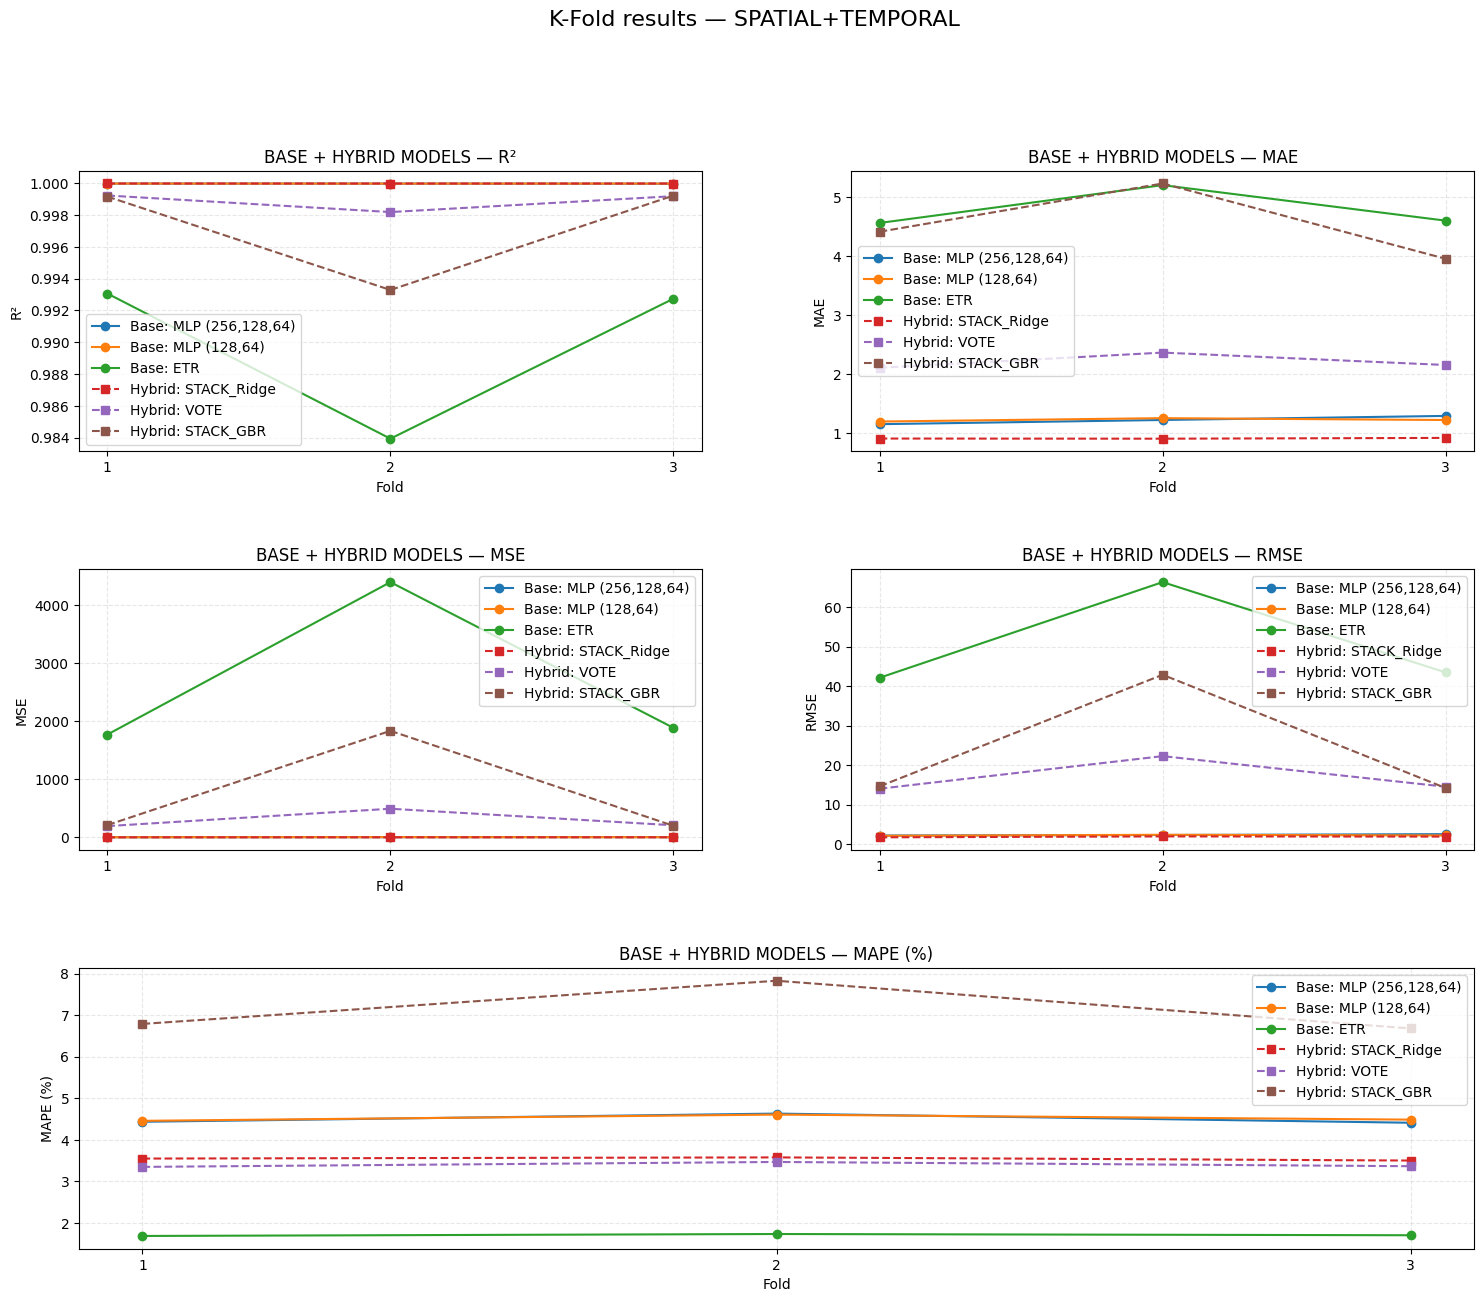


=== TOP-3 BASE by mean Test_MAE ===
           Model  Test_MAE_mean
MLP (256,128,64)       1.218274
    MLP (128,64)       1.220413
             ETR       4.787487

=== TOP-3 HYBRID by mean Test_MAE ===
     Hybrid  Test_MAE_mean
STACK_Ridge       0.906990
       VOTE       2.205798
  STACK_GBR       4.531633

Diagnostic skipped: STACK_Lin or STACK_Ridge not in hyb_fold_tbl.

SELECTED MODELS FOR BIAS AND VARIANCE PLOT

Best base model:
Combo        : SPATIAL+TEMPORAL
Model        : MLP (256,128,64)
Bias         : 0.146197
Absolute Bias: 0.146197
Variance     : 5.343412
R²           : 0.999980
MAE          : 1.218274
MSE          : 5.367377
RMSE         : 2.312365
MAPE         : 4.491139%

Best hybrid model:
Combo        : SPATIAL+TEMPORAL
Hybrid       : STACK_Ridge
Bias         : -0.070647
Absolute Bias: 0.070647
Variance     : 3.372670
R²           : 0.999987
MAE          : 0.906990
MSE          : 3.377647
RMSE         : 1.835120
MAPE         : 3.540943%


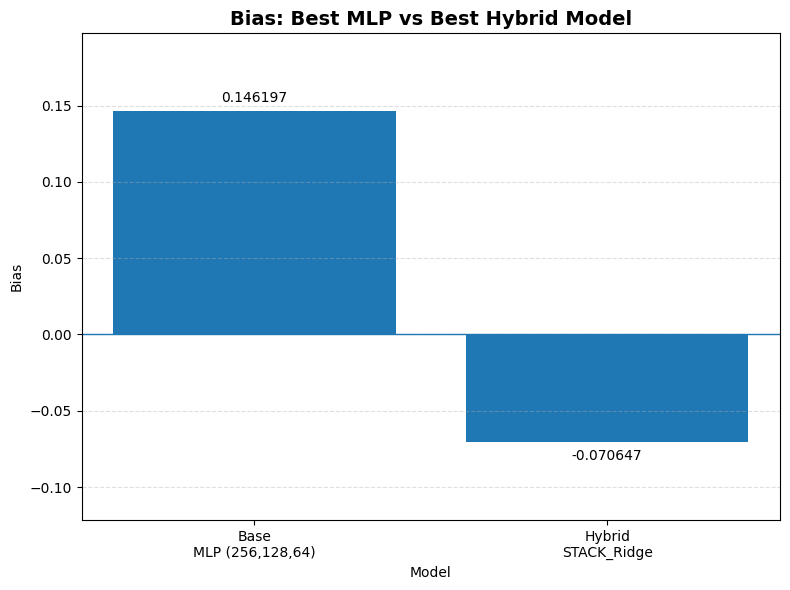

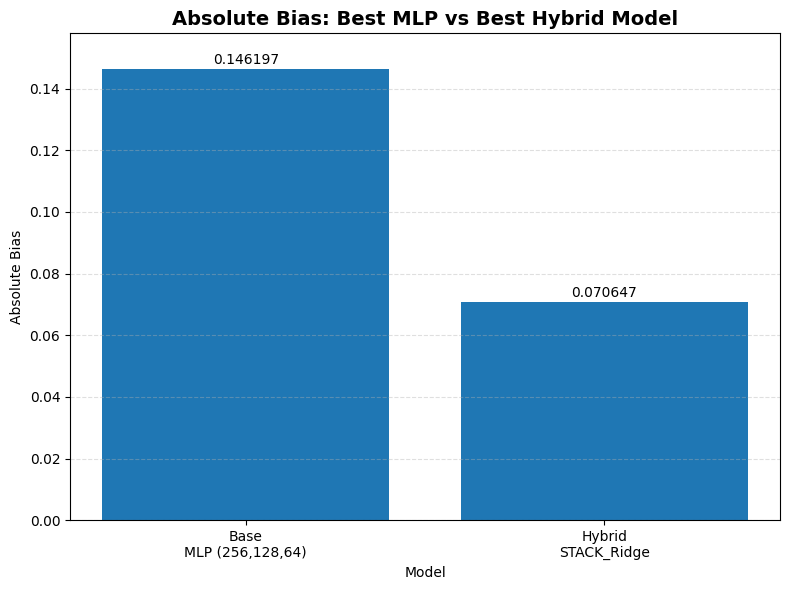

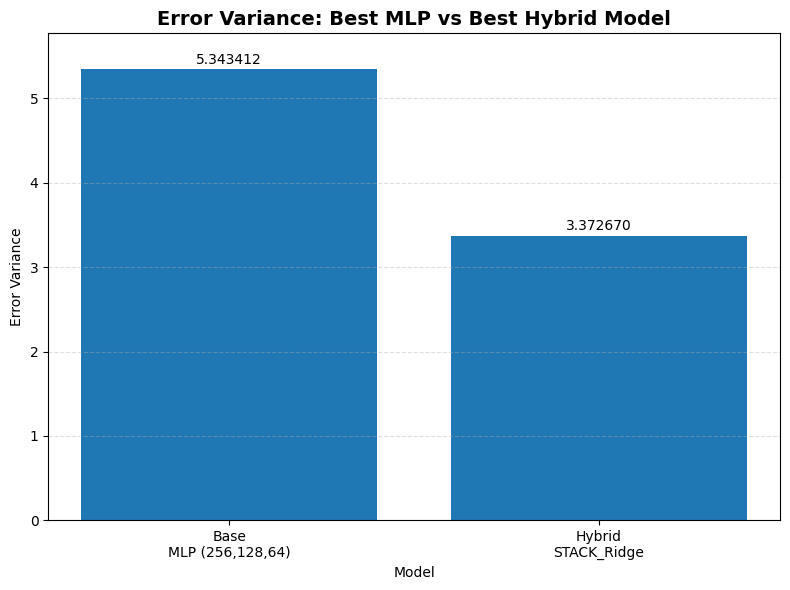

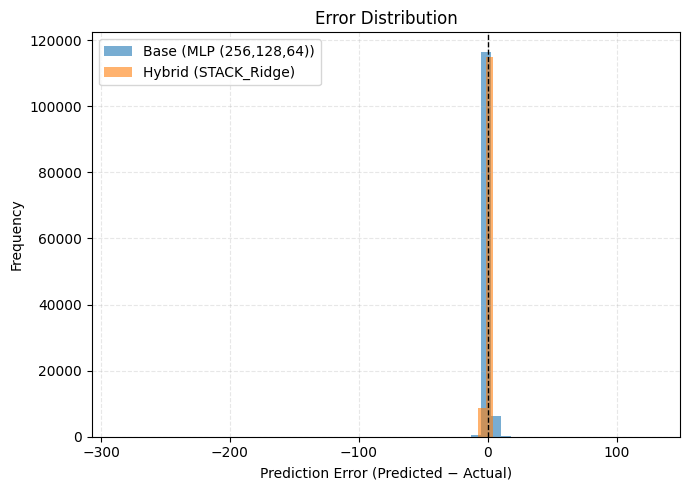

In [200]:
# =====================================================================================
# K-FOLD TABLES + TOP-3 BASE / TOP-3 HYBRID PLOTS
# Paste this AFTER your hybrid block, after df_h is created.
# =====================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import VotingRegressor, StackingRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

N_SPLITS = 3
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ---------------- Helpers ----------------
def _get_model_def(name):
    name = str(name).strip()

    for mname, mdl in MODELS:
        if str(mname).strip() == name:
            return mdl

    return None


def _parse_base_names_safely(bases_str):
    """
    Safely parse model names from df_h['Bases'], including names with commas:
    Example: MLP (256,128,64)
    """
    bases_str = str(bases_str)
    model_names = [str(mname).strip() for mname, _ in MODELS]

    found = []
    remaining = bases_str

    for mname in sorted(model_names, key=len, reverse=True):
        if mname in remaining:
            found.append(mname)
            remaining = remaining.replace(mname, "")

    return found


def _safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.where(
        np.abs(y_true) < 1e-8,
        np.nan,
        np.abs(y_true)
    )

    return float(
        np.nanmean(
            np.abs((y_true - y_pred) / denominator)
        ) * 100
    )


# =====================================================================================
# 1) CREATE base_fold_tbl
# =====================================================================================

base_fold_rows = []

for combo_name, feats in BASE_COMBOS.items():

    feats = [f for f in feats if f in df.columns]

    if len(feats) == 0:
        continue

    X, y = build_Xy(df, feats)

    if len(X) == 0 or X.shape[1] == 0:
        continue

    top3_base_names = (
        final_tbl[final_tbl["Combo"] == combo_name]
        .sort_values("Score", ascending=False)
        .head(3)["Model"]
        .astype(str)
        .tolist()
    )

    if len(top3_base_names) == 0:
        continue

    for fold, (tr_idx, te_idx) in enumerate(kf.split(X), start=1):

        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        for model_name in top3_base_names:

            base_def = _get_model_def(model_name)

            if base_def is None:
                continue

            model = clone(base_def)
            model.fit(X_tr, y_tr)

            pred_te = model.predict(X_te)

            # Bias, absolute bias, and residual/error variance
            errors = pred_te - y_te
            bias = float(np.mean(errors))
            absolute_bias = float(abs(bias))
            variance = float(np.var(errors, ddof=1))

            test_mse = mean_squared_error(y_te, pred_te)

            base_fold_rows.append({
                "Fold": fold,
                "Combo": combo_name,
                "Model": model_name,
                "Test_R2": r2_score(y_te, pred_te),
                "Test_MAE": mean_absolute_error(y_te, pred_te),
                "Test_MSE": test_mse,
                "Test_RMSE": np.sqrt(test_mse),
                "Test_MAPE": _safe_mape(y_te, pred_te),
                "Bias": bias,
                "Absolute_Bias": absolute_bias,
                "Variance": variance,
                "Errors": np.asarray(errors, dtype=float).ravel()
            })

base_fold_tbl = pd.DataFrame(base_fold_rows)


# =====================================================================================
# 2) CREATE hyb_fold_tbl
# =====================================================================================

hyb_fold_rows = []

for combo_name, feats in BASE_COMBOS.items():

    feats = [f for f in feats if f in df.columns]

    if len(feats) == 0:
        continue

    X, y = build_Xy(df, feats)

    if len(X) == 0 or X.shape[1] == 0:
        continue

    top_hybrids = (
        df_h[df_h["Combo"] == combo_name]
        .sort_values("Score_H", ascending=False)
        .head(8)
    )

    for fold, (tr_idx, te_idx) in enumerate(kf.split(X), start=1):

        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        for _, hr in top_hybrids.iterrows():

            hybrid_name = hr["Hybrid"]

            base_names = _parse_base_names_safely(hr["Bases"])

            bases = []

            for name in base_names:

                base_def = _get_model_def(name)

                if base_def is not None:
                    bases.append((name, clone(base_def)))

            if len(bases) == 0:
                continue

            try:

                if hybrid_name == "VOTE":

                    model = VotingRegressor(bases)

                elif hybrid_name == "STACK_Ridge":

                    model = StackingRegressor(
                        estimators=bases,
                        final_estimator=Ridge(alpha=1.0),
                        cv=3,
                        passthrough=True
                    )

                elif hybrid_name == "STACK_GBR":

                    model = StackingRegressor(
                        estimators=bases,
                        final_estimator=GradientBoostingRegressor(
                            random_state=RANDOM_STATE,
                            n_estimators=200,
                            learning_rate=0.05,
                            max_depth=3
                        ),
                        cv=3,
                        passthrough=True
                    )

                else:
                    continue

                model.fit(X_tr, y_tr)
                pred_te = model.predict(X_te)

                # Bias, absolute bias, and residual/error variance
                errors = pred_te - y_te
                bias = float(np.mean(errors))
                absolute_bias = float(abs(bias))
                variance = float(np.var(errors, ddof=1))

                test_mse = mean_squared_error(y_te, pred_te)

                hyb_fold_rows.append({
                    "Fold": fold,
                    "Combo": combo_name,
                    "Hybrid": hybrid_name,
                    "Test_R2": r2_score(y_te, pred_te),
                    "Test_MAE": mean_absolute_error(y_te, pred_te),
                    "Test_MSE": test_mse,
                    "Test_RMSE": np.sqrt(test_mse),
                    "Test_MAPE": _safe_mape(y_te, pred_te),
                    "Bias": bias,
                    "Absolute_Bias": absolute_bias,
                    "Variance": variance,
                    "Errors": np.asarray(errors, dtype=float).ravel()
                })

            except Exception as e:
                print(f"[skip] {hybrid_name} fold={fold}: {type(e).__name__}: {e}")

hyb_fold_tbl = pd.DataFrame(hyb_fold_rows)


# =====================================================================================
# 2A) CREATE K-FOLD SUMMARY TABLES
# Metrics updated: R², MAE, MSE, RMSE, and MAPE
# Bias, Absolute Bias, and Variance remain unchanged
# =====================================================================================

if not base_fold_tbl.empty:
    base_kfold_summary = (
        base_fold_tbl
        .groupby(["Combo", "Model"], as_index=False)
        .agg(
            R2_Mean=("Test_R2", "mean"),
            R2_Std=("Test_R2", "std"),
            MAE_Mean=("Test_MAE", "mean"),
            MAE_Std=("Test_MAE", "std"),
            MSE_Mean=("Test_MSE", "mean"),
            MSE_Std=("Test_MSE", "std"),
            RMSE_Mean=("Test_RMSE", "mean"),
            RMSE_Std=("Test_RMSE", "std"),
            MAPE_Mean=("Test_MAPE", "mean"),
            MAPE_Std=("Test_MAPE", "std"),
            Bias_Mean=("Bias", "mean"),
            Bias_Std=("Bias", "std"),
            Absolute_Bias_Mean=("Absolute_Bias", "mean"),
            Absolute_Bias_Std=("Absolute_Bias", "std"),
            Variance_Mean=("Variance", "mean"),
            Variance_Std=("Variance", "std")
        )
    )
else:
    base_kfold_summary = pd.DataFrame()

if not hyb_fold_tbl.empty:
    hybrid_kfold_summary = (
        hyb_fold_tbl
        .groupby(["Combo", "Hybrid"], as_index=False)
        .agg(
            R2_Mean=("Test_R2", "mean"),
            R2_Std=("Test_R2", "std"),
            MAE_Mean=("Test_MAE", "mean"),
            MAE_Std=("Test_MAE", "std"),
            MSE_Mean=("Test_MSE", "mean"),
            MSE_Std=("Test_MSE", "std"),
            RMSE_Mean=("Test_RMSE", "mean"),
            RMSE_Std=("Test_RMSE", "std"),
            MAPE_Mean=("Test_MAPE", "mean"),
            MAPE_Std=("Test_MAPE", "std"),
            Bias_Mean=("Bias", "mean"),
            Bias_Std=("Bias", "std"),
            Absolute_Bias_Mean=("Absolute_Bias", "mean"),
            Absolute_Bias_Std=("Absolute_Bias", "std"),
            Variance_Mean=("Variance", "mean"),
            Variance_Std=("Variance", "std")
        )
    )
else:
    hybrid_kfold_summary = pd.DataFrame()


print("\n" + "=" * 160)
print("BASE MODEL K-FOLD SUMMARY — R², MAE, MSE, RMSE, MAPE, BIAS, ABSOLUTE BIAS, AND VARIANCE")
print("=" * 160)

if not base_kfold_summary.empty:
    print(
        base_kfold_summary.to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}"
        )
    )
else:
    print("No base-model K-fold summary was created.")


print("\n" + "=" * 160)
print("HYBRID MODEL K-FOLD SUMMARY — R², MAE, MSE, RMSE, MAPE, BIAS, ABSOLUTE BIAS, AND VARIANCE")
print("=" * 160)

if not hybrid_kfold_summary.empty:
    print(
        hybrid_kfold_summary.to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}"
        )
    )
else:
    print("No hybrid-model K-fold summary was created.")


print("\n=== K-FOLD TABLE SUMMARY ===")
print(f"Base K-fold rows   : {len(base_fold_tbl):,}")
print(f"Hybrid K-fold rows : {len(hyb_fold_tbl):,}")

if not base_fold_tbl.empty:
    print("\nBase K-fold models:")
    print(base_fold_tbl["Model"].drop_duplicates().tolist())

if not hyb_fold_tbl.empty:
    print("\nHybrid K-fold models:")
    print(hyb_fold_tbl["Hybrid"].drop_duplicates().tolist())


# =====================================================================================
# 3) PLOT TOP-3 BASE + TOP-3 HYBRID
# Five separate metric diagrams; all selected base and hybrid models in every diagram
# =====================================================================================

def pick_topk_by_mean(tbl, name_col, metric="Test_MAE", k=3, lower_is_better=True):

    if tbl is None or tbl.empty:
        return [], pd.DataFrame(columns=[name_col, f"{metric}_mean"])

    agg = (
        tbl.groupby(name_col, as_index=False)[metric]
        .mean()
        .rename(columns={metric: f"{metric}_mean"})
    )

    agg = agg.sort_values(
        f"{metric}_mean",
        ascending=lower_is_better
    )

    return agg[name_col].head(k).tolist(), agg


def plot_kfold_top3(base_fold_tbl, hyb_fold_tbl, combo_title="SPATIAL+TEMPORAL"):

    if base_fold_tbl.empty:
        print("\nNo base K-fold results were created. Check final_tbl, BASE_COMBOS, and features.")
        return [], []

    if hyb_fold_tbl.empty:
        print("\nNo hybrid K-fold results were created. Check df_h and hybrid bases.")
        return [], []

    top3_base, base_rank = pick_topk_by_mean(
        base_fold_tbl,
        name_col="Model",
        metric="Test_MAE",
        k=3,
        lower_is_better=True
    )

    top3_hyb, hyb_rank = pick_topk_by_mean(
        hyb_fold_tbl,
        name_col="Hybrid",
        metric="Test_MAE",
        k=3,
        lower_is_better=True
    )

    b = base_fold_tbl[base_fold_tbl["Model"].isin(top3_base)].copy()
    h = hyb_fold_tbl[hyb_fold_tbl["Hybrid"].isin(top3_hyb)].copy()

    folds = sorted(set(b["Fold"].unique()) | set(h["Fold"].unique()))

    metric_settings = [
        ("Test_R2", "R²", "BASE + HYBRID MODELS — R²"),
        ("Test_MAE", "MAE", "BASE + HYBRID MODELS — MAE"),
        ("Test_MSE", "MSE", "BASE + HYBRID MODELS — MSE"),
        ("Test_RMSE", "RMSE", "BASE + HYBRID MODELS — RMSE"),
        ("Test_MAPE", "MAPE (%)", "BASE + HYBRID MODELS — MAPE (%)")
    ]

    # One frame containing all five K-fold metric diagrams
    fig = plt.figure(figsize=(18, 14))

    gs = fig.add_gridspec(
        3,
        2,
        height_ratios=[1, 1, 1],
        hspace=0.42,
        wspace=0.24
    )

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[2, :])
    ]

    for ax, (metric, ylabel, title) in zip(axes, metric_settings):

        b_metric = (
            b.pivot_table(
                index="Fold",
                columns="Model",
                values=metric,
                aggfunc="mean"
            )
            .reindex(folds)
        )

        h_metric = (
            h.pivot_table(
                index="Fold",
                columns="Hybrid",
                values=metric,
                aggfunc="mean"
            )
            .reindex(folds)
        )

        for m in top3_base:
            if m in b_metric.columns:
                ax.plot(
                    b_metric.index,
                    b_metric[m].values,
                    marker="o",
                    label=f"Base: {m}"
                )

        for m in top3_hyb:
            if m in h_metric.columns:
                ax.plot(
                    h_metric.index,
                    h_metric[m].values,
                    marker="s",
                    linestyle="--",
                    label=f"Hybrid: {m}"
                )

        ax.set_title(title)
        ax.set_xlabel("Fold")
        ax.set_ylabel(ylabel)
        ax.set_xticks(folds)
        ax.legend(loc="best")
        ax.grid(alpha=0.3, linestyle="--")

    fig.suptitle(
        f"K-Fold results — {combo_title}",
        fontsize=16,
        y=0.995
    )

    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.97])
    plt.show()

    print("\n=== TOP-3 BASE by mean Test_MAE ===")
    print(
        base_rank.sort_values("Test_MAE_mean", ascending=True)
        .head(10)
        .to_string(index=False)
    )

    print("\n=== TOP-3 HYBRID by mean Test_MAE ===")
    print(
        hyb_rank.sort_values("Test_MAE_mean", ascending=True)
        .head(10)
        .to_string(index=False)
    )

    return top3_base, top3_hyb


# =====================================================================================
# 4) DIAGNOSTIC
# =====================================================================================

def diagnose_stack_similarity(hyb_fold_tbl, a="STACK_Lin", b="STACK_Ridge"):

    if (
        a not in hyb_fold_tbl["Hybrid"].unique()
        or b not in hyb_fold_tbl["Hybrid"].unique()
    ):
        print(f"\nDiagnostic skipped: {a} or {b} not in hyb_fold_tbl.")
        return

    aa = hyb_fold_tbl[hyb_fold_tbl["Hybrid"] == a].sort_values("Fold")
    bb = hyb_fold_tbl[hyb_fold_tbl["Hybrid"] == b].sort_values("Fold")

    merged = aa.merge(
        bb,
        on=["Fold"],
        suffixes=(f"_{a}", f"_{b}")
    )

    merged["dR2"] = merged[f"Test_R2_{a}"] - merged[f"Test_R2_{b}"]
    merged["dMAE"] = merged[f"Test_MAE_{a}"] - merged[f"Test_MAE_{b}"]
    merged["dMSE"] = merged[f"Test_MSE_{a}"] - merged[f"Test_MSE_{b}"]
    merged["dRMSE"] = merged[f"Test_RMSE_{a}"] - merged[f"Test_RMSE_{b}"]
    merged["dMAPE"] = merged[f"Test_MAPE_{a}"] - merged[f"Test_MAPE_{b}"]

    print(f"\n=== {a} vs {b} per-fold differences ===")

    print(
        merged[
            [
                "Fold",
                f"Test_R2_{a}",
                f"Test_R2_{b}",
                "dR2",
                f"Test_MAE_{a}",
                f"Test_MAE_{b}",
                "dMAE",
                f"Test_MSE_{a}",
                f"Test_MSE_{b}",
                "dMSE",
                f"Test_RMSE_{a}",
                f"Test_RMSE_{b}",
                "dRMSE",
                f"Test_MAPE_{a}",
                f"Test_MAPE_{b}",
                "dMAPE"
            ]
        ].to_string(index=False, float_format=lambda x: f"{x:.6f}")
    )


# ===================== RUN =====================
top3_base, top3_hyb = plot_kfold_top3(
    base_fold_tbl,
    hyb_fold_tbl,
    combo_title="SPATIAL+TEMPORAL"
)

diagnose_stack_similarity(
    hyb_fold_tbl,
    a="STACK_Lin",
    b="STACK_Ridge"
)


# =============================================================================
# PLOT BIAS AND VARIANCE
# BEST BASE MODEL = MLP
# BEST HYBRID MODEL = LOWEST MAE
# No model training occurs here
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# 1. SELECT BEST MLP BASE MODEL
# Primary criterion: lowest MAE
# Tie-breaker: highest R²
# -----------------------------------------------------------------------------

if (
    "base_kfold_summary" not in globals()
    or base_kfold_summary is None
    or base_kfold_summary.empty
):
    raise ValueError(
        "base_kfold_summary is empty or undefined. "
        "Run the K-fold section first."
    )

mlp_results = base_kfold_summary[
    base_kfold_summary["Model"]
    .astype(str)
    .str.contains("MLP", case=False, na=False)
].copy()

if mlp_results.empty:
    raise ValueError(
        "No MLP model was found in base_kfold_summary.\n"
        f"Available models:\n"
        f"{base_kfold_summary['Model'].unique()}"
    )

best_mlp = (
    mlp_results
    .sort_values(
        ["MAE_Mean", "R2_Mean"],
        ascending=[True, False]
    )
    .iloc[0]
)


# -----------------------------------------------------------------------------
# 2. SELECT BEST HYBRID MODEL
# Primary criterion: lowest MAE
# Tie-breaker: highest R²
# -----------------------------------------------------------------------------

if (
    "hybrid_kfold_summary" not in globals()
    or hybrid_kfold_summary is None
    or hybrid_kfold_summary.empty
):
    raise ValueError(
        "hybrid_kfold_summary is empty or undefined. "
        "Run the K-fold section first."
    )

best_hybrid = (
    hybrid_kfold_summary
    .sort_values(
        ["MAE_Mean", "R2_Mean"],
        ascending=[True, False]
    )
    .iloc[0]
)


# -----------------------------------------------------------------------------
# 3. PRINT SELECTED MODELS
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("SELECTED MODELS FOR BIAS AND VARIANCE PLOT")
print("=" * 90)

print("\nBest base model:")
print(f"Combo        : {best_mlp['Combo']}")
print(f"Model        : {best_mlp['Model']}")
print(f"Bias         : {best_mlp['Bias_Mean']:.6f}")
print(
    f"Absolute Bias: "
    f"{best_mlp['Absolute_Bias_Mean']:.6f}"
)
print(f"Variance     : {best_mlp['Variance_Mean']:.6f}")
print(f"R²           : {best_mlp['R2_Mean']:.6f}")
print(f"MAE          : {best_mlp['MAE_Mean']:.6f}")
print(f"MSE          : {best_mlp['MSE_Mean']:.6f}")
print(f"RMSE         : {best_mlp['RMSE_Mean']:.6f}")
print(f"MAPE         : {best_mlp['MAPE_Mean']:.6f}%")

print("\nBest hybrid model:")
print(f"Combo        : {best_hybrid['Combo']}")
print(f"Hybrid       : {best_hybrid['Hybrid']}")

print(f"Bias         : {best_hybrid['Bias_Mean']:.6f}")
print(
    f"Absolute Bias: "
    f"{best_hybrid['Absolute_Bias_Mean']:.6f}"
)
print(
    f"Variance     : "
    f"{best_hybrid['Variance_Mean']:.6f}"
)
print(f"R²           : {best_hybrid['R2_Mean']:.6f}")
print(f"MAE          : {best_hybrid['MAE_Mean']:.6f}")
print(f"MSE          : {best_hybrid['MSE_Mean']:.6f}")
print(f"RMSE         : {best_hybrid['RMSE_Mean']:.6f}")
print(f"MAPE         : {best_hybrid['MAPE_Mean']:.6f}%")


# -----------------------------------------------------------------------------
# 4. PREPARE PLOT DATA
# Signed bias is used; no absolute value
# -----------------------------------------------------------------------------

model_labels = [
    f"Base\n{best_mlp['Model']}",
    f"Hybrid\n{best_hybrid['Hybrid']}"
]

bias_values = [
    float(best_mlp["Bias_Mean"]),
    float(best_hybrid["Bias_Mean"])
]

absolute_bias_values = [
    float(best_mlp["Absolute_Bias_Mean"]),
    float(best_hybrid["Absolute_Bias_Mean"])
]

variance_values = [
    float(best_mlp["Variance_Mean"]),
    float(best_hybrid["Variance_Mean"])
]


# -----------------------------------------------------------------------------
# 5. BIAS PLOT
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    model_labels,
    bias_values
)

ax.set_title(
    "Bias: Best MLP vs Best Hybrid Model",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Model")
ax.set_ylabel("Bias")

# Zero-reference line
ax.axhline(
    y=0,
    linewidth=1
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Add space above and below bars
largest_bias = max(
    abs(value) for value in bias_values
)

bias_margin = (
    largest_bias * 0.35
    if largest_bias > 0
    else 0.1
)

ax.set_ylim(
    min(bias_values + [0]) - bias_margin,
    max(bias_values + [0]) + bias_margin
)

for bar, value in zip(bars, bias_values):

    if value >= 0:
        label_y = value + bias_margin * 0.08
        vertical_alignment = "bottom"
    else:
        label_y = value - bias_margin * 0.08
        vertical_alignment = "top"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"{value:.6f}",
        ha="center",
        va=vertical_alignment,
        fontsize=10
    )

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 6. ABSOLUTE BIAS PLOT
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    model_labels,
    absolute_bias_values
)

ax.set_title(
    "Absolute Bias: Best MLP vs Best Hybrid Model",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Model")
ax.set_ylabel("Absolute Bias")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

largest_absolute_bias = max(absolute_bias_values)

absolute_bias_margin = (
    largest_absolute_bias * 0.08
    if largest_absolute_bias > 0
    else 0.1
)

ax.set_ylim(
    0,
    largest_absolute_bias + absolute_bias_margin
)

for bar, value in zip(bars, absolute_bias_values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + absolute_bias_margin * 0.08,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 7. VARIANCE PLOT
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    model_labels,
    variance_values
)

ax.set_title(
    "Error Variance: Best MLP vs Best Hybrid Model",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Model")
ax.set_ylabel("Error Variance")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

largest_variance = max(variance_values)

variance_margin = (
    largest_variance * 0.08
    if largest_variance > 0
    else 0.1
)

ax.set_ylim(
    0,
    largest_variance + variance_margin
)

for bar, value in zip(bars, variance_values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + variance_margin * 0.08,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()



# =============================================================================
# PREPARE ERROR ARRAYS FOR ERROR DISTRIBUTION
# Uses the fold-level Errors already saved above
# =============================================================================

base_error_rows = base_fold_tbl[
    (base_fold_tbl["Combo"].astype(str) == str(best_mlp["Combo"]))
    &
    (base_fold_tbl["Model"].astype(str) == str(best_mlp["Model"]))
].copy()

hybrid_error_rows = hyb_fold_tbl[
    (hyb_fold_tbl["Combo"].astype(str) == str(best_hybrid["Combo"]))
    &
    (hyb_fold_tbl["Hybrid"].astype(str) == str(best_hybrid["Hybrid"]))
].copy()

if base_error_rows.empty:
    raise ValueError(
        "No fold-level error rows were found for the selected best MLP."
    )

if hybrid_error_rows.empty:
    raise ValueError(
        "No fold-level error rows were found for the selected best hybrid."
    )

best_base_errors = np.concatenate(
    [
        np.asarray(fold_errors, dtype=float).ravel()
        for fold_errors in base_error_rows["Errors"]
    ]
)

best_hybrid_errors = np.concatenate(
    [
        np.asarray(fold_errors, dtype=float).ravel()
        for fold_errors in hybrid_error_rows["Errors"]
    ]
)

best_base_errors = best_base_errors[
    np.isfinite(best_base_errors)
]

best_hybrid_errors = best_hybrid_errors[
    np.isfinite(best_hybrid_errors)
]


# =============================================================================
# ERROR DISTRIBUTION
# =============================================================================

plt.figure(figsize=(7,5))

plt.hist(
    best_base_errors,
    bins=50,
    alpha=0.6,
    label=f"Base ({best_mlp['Model']})"
)

plt.hist(
    best_hybrid_errors,
    bins=50,
    alpha=0.6,
    label=f"Hybrid ({best_hybrid['Hybrid']})"
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Prediction Error (Predicted − Actual)")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.legend()

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()
plt.show()

| Hybrid      | R² Rank | MAE Rank | MSE Rank | RMSE Rank | MAPE Rank | Total Rank |        Score        |
| ----------- | :-----: | :------: | :------: | :-------: | :-------: | :--------: | :-----------------: |
| STACK_GBR   |    1    |     2    |     1    |     1     |     2     |    **7**   |  **15 − 7 + 1 = 9** |
| VOTE        |    2    |     1    |     2    |     2     |     1     |    **8**   |  **15 − 8 + 1 = 8** |
| STACK_Ridge |    3    |     3    |     3    |     3     |     3     |   **15**   | **15 − 15 + 1 = 1** |

The calculations are:

Rank each metric:
R²: higher is better → Rank 1 is the highest R².
MAE, MSE, RMSE, MAPE: lower is better → Rank 1 is the lowest value.
Compute the total rank:
Total Rank=R2 Rank+MAE Rank+MSE Rank+RMSE Rank+MAPE Rank
Convert it to a score:
Score=max(Total Rank)−Total Rank+1
	​


In your example, the maximum total rank is 15, so:

STACK_GBR: 15−7+1=9
VOTE: 15−8+1=8
STACK_Ridge: 15−15+1=1

In [201]:
# =============================================================================
# Mean Hybrid Results After IQR Removal
# =============================================================================

IQR_Hybrid_MAE_Table = (
    hyb_fold_tbl
    .groupby(["Combo", "Hybrid"], as_index=False)
    .agg(
        Mean_MAE=("Test_MAE", "mean"),
        Mean_R2=("Test_R2", "mean"),
        Mean_MSE=("Test_MSE", "mean"),
        Mean_RMSE=("Test_RMSE", "mean"),
        Mean_MAPE=("Test_MAPE", "mean"),
    )
    .reset_index(drop=True)
)

# Higher R² is better
r2_rank = IQR_Hybrid_MAE_Table["Mean_R2"].rank(ascending=False)

r2_rank   = IQR_Hybrid_MAE_Table["Mean_R2"].rank(ascending=False)
mae_rank  = IQR_Hybrid_MAE_Table["Mean_MAE"].rank()
mse_rank  = IQR_Hybrid_MAE_Table["Mean_MSE"].rank()
rmse_rank = IQR_Hybrid_MAE_Table["Mean_RMSE"].rank()
mape_rank = IQR_Hybrid_MAE_Table["Mean_MAPE"].rank()

total_rank = (
    r2_rank +
    mae_rank +
    mse_rank +
    rmse_rank +
    mape_rank
)

IQR_Hybrid_MAE_Table["Score"] = (
    total_rank.max() - total_rank + 1
)

IQR_Hybrid_MAE_Table = (
    IQR_Hybrid_MAE_Table
    .sort_values("Score", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Mean Hybrid Results After IQR Removal ===")
print(
    IQR_Hybrid_MAE_Table.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


=== Mean Hybrid Results After IQR Removal ===
           Combo      Hybrid  Mean_MAE  Mean_R2   Mean_MSE  Mean_RMSE  Mean_MAPE     Score
SPATIAL+TEMPORAL STACK_Ridge  0.906990 0.999987   3.377647   1.835120   3.540943 10.000000
SPATIAL+TEMPORAL        VOTE  2.205798 0.998871 300.798465  16.927260   3.392077  7.000000
SPATIAL+TEMPORAL   STACK_GBR  4.531633 0.997227 750.901946  23.888775   7.099465  1.000000


Now Applying Anomaly detection 3 Technique Isolation Forest, LocalOutlierFactor and  OneClassSVM

# =============================================================================
# This code implements the complete prediction pipeline, including data
# preprocessing, feature engineering, model training, base model evaluation,
# and performance comparison before and after anomaly filtering.
# =============================================================================


ANOMALY DETECTION: IF + LOF + OCSVM MAJORITY VOTING
Rows before anomaly removal : 123,627
Anomaly feature count       : 96
Rows used to fit LOF/OCSVM  : 20,000
Detector contamination      : 5.00000%
Final anomaly vote rule     : >= 2 detectors
------------------------------------------------------------------------
Isolation Forest anomalies : 6,182
LOF anomalies              : 6,245
OCSVM anomalies            : 6,428
Raw majority-vote anomalies: 5,705
Exact target anomalies     : 6,181
Final anomalies removed    : 6,181
Rows after removal         : 117,446
Percent removed            : 5.00%
Expected exact percent     : 5.00%
Anomaly features           : ['asian', 'black', 'duration', 'female_0_5', 'female_10_14', 'female_15_17', 'female_18_19', 'female_20_20', 'female_21_21', 'female_22_24', 'female_25_29', 'female_30_34', 'female_35_39', 'female_40_44', 'female_45_49', 'female_50_54', 'female_55_59', 'female_5_9', 'female_60_61', 'female_62_64', 'female_65_66', 'female_67_69', 'fema

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.28512e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



=== Train/Test metrics by Combo (sorted by Score desc) ===
           Combo            Model  Score  Train_R2  Train_MAE  Train_MSE  Train_RMSE  Train_MAPE  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
SPATIAL+TEMPORAL            Bayes  0.976     1.000      0.878      2.659       1.631       3.688    1.000     0.902     6.352      2.520      3.734
SPATIAL+TEMPORAL MLP (256,128,64)  0.975     1.000      0.981      2.540       1.594       3.435    1.000     1.048     6.447      2.539      3.492
SPATIAL+TEMPORAL     MLP (128,64)  0.971     1.000      1.047      2.856       1.690       3.710    1.000     1.090     6.634      2.576      3.706
SPATIAL+TEMPORAL            Ridge  0.968     1.000      0.981      2.989       1.729       4.087    1.000     0.997     6.684      2.585      4.113
SPATIAL+TEMPORAL         MLP (64)  0.968     1.000      1.087      3.239       1.800       3.857    1.000     1.127     7.228      2.688      3.845
SPATIAL+TEMPORAL              ETR  0.842     1.000  

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.34789e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.28512e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Pyt


MODEL PERFORMANCE: BEFORE vs AFTER MAJORITY-VOTE ANOMALY REMOVAL
           Model  MAE_Before  R2_Before  Score_Before  MAE_After  R2_After  Score_After  MAE_Change  MAE_Improvement_%  R2_Change  Score_Change
           Bayes      0.8936     1.0000        0.9766     0.9023    0.9999       0.9755      0.0087            -0.9752    -0.0001       -0.0011
           Ridge      0.9846     1.0000        0.9708     0.9967    0.9999       0.9683      0.0121            -1.2298    -0.0001       -0.0025
MLP (256,128,64)      1.7047     1.0000        0.9475     1.0476    0.9999       0.9753     -0.6571            38.5470    -0.0001        0.0279
    MLP (128,64)      1.4036     1.0000        0.9582     1.0902    0.9999       0.9715     -0.3134            22.3309    -0.0001        0.0133
        MLP (64)      1.5877     1.0000        0.9500     1.1265    0.9999       0.9679     -0.4612            29.0464    -0.0001        0.0179
             ETR      4.4680     0.9938        0.8150     2.1995    0.

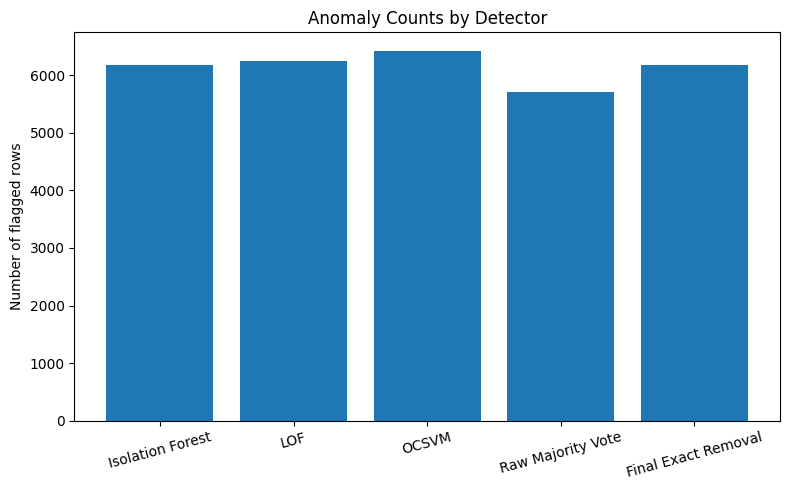

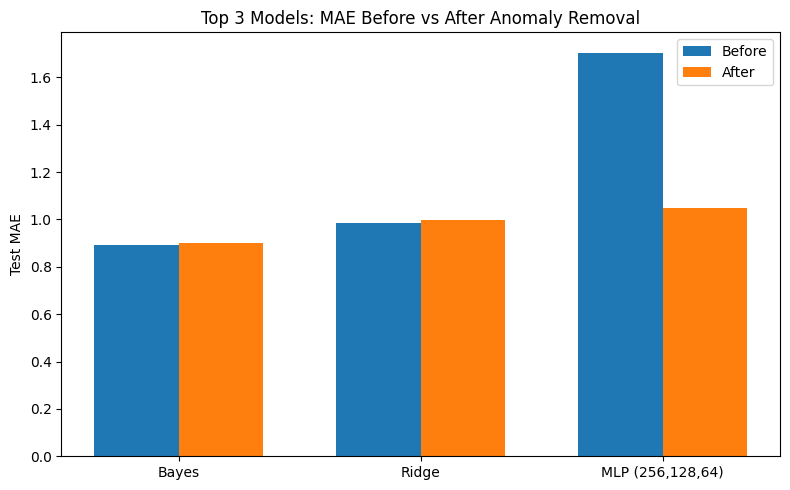

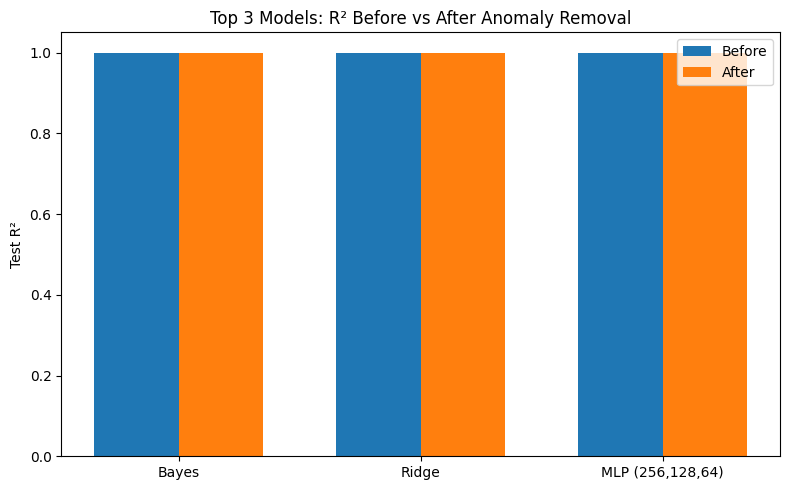

In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    IsolationForest
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor
#from xgboost import XGBRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20

PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ============================================================================
# ANOMALY DETECTION ENSEMBLE: IF + LOF + OCSVM
# A row is removed only when at least 2 of the 3 detectors vote anomaly.
# No IQR trimming is used.
# ============================================================================

# ---------------- Anomaly configuration ----------------
ANOMALY_CONTAMINATION = 0.05
ANOMALY_VOTE_THRESHOLD = 2
ANOMALY_MAX_FIT_ROWS = 20000
ANOMALY_RANDOM_STATE = 42

# Keep an untouched copy before anomaly removal
df_before_anomaly = df.copy()

# Use the same numeric predictor columns in every script.
# Exclude the target (count) so anomaly filtering is consistent and does not
# directly remove rows only because their visitation count is high or low.
anomaly_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "count"
    and df[c].notna().sum() > 0
    and df[c].nunique(dropna=True) > 1
]

# Keep feature ordering deterministic across all scripts.
anomaly_features = sorted(anomaly_features)

if not anomaly_features:
    raise RuntimeError("No usable numeric columns were found for anomaly detection.")

# Median imputation + scaling is important for LOF and OCSVM.
anomaly_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_anomaly = anomaly_preprocessor.fit_transform(df[anomaly_features])
X_anomaly = np.asarray(X_anomaly, dtype=np.float32)

# Fit LOF and OCSVM on a reproducible subset when the dataset is large.
rng = np.random.default_rng(ANOMALY_RANDOM_STATE)
if len(X_anomaly) > ANOMALY_MAX_FIT_ROWS:
    fit_idx = rng.choice(
        len(X_anomaly), size=ANOMALY_MAX_FIT_ROWS, replace=False
    )
else:
    fit_idx = np.arange(len(X_anomaly))

X_fit_anomaly = X_anomaly[fit_idx]

print("\n" + "=" * 72)
print("ANOMALY DETECTION: IF + LOF + OCSVM MAJORITY VOTING")
print("=" * 72)
print(f"Rows before anomaly removal : {len(df):,}")
print(f"Anomaly feature count       : {len(anomaly_features):,}")
print(f"Rows used to fit LOF/OCSVM  : {len(X_fit_anomaly):,}")
print(f"Detector contamination      : {ANOMALY_CONTAMINATION:.5%}")
print(f"Final anomaly vote rule     : >= {ANOMALY_VOTE_THRESHOLD} detectors")

# ---------------- 1) Isolation Forest ----------------
if_detector = IsolationForest(
    n_estimators=300,
    contamination=ANOMALY_CONTAMINATION,
    max_samples="auto",
    n_jobs=-1,
    random_state=ANOMALY_RANDOM_STATE,
)
if_raw = if_detector.fit_predict(X_anomaly)
if_flag = (if_raw == -1).astype(np.int8)

# ---------------- 2) Local Outlier Factor ----------------
# novelty=True allows fitting on a subset and predicting all rows.
lof_detector = LocalOutlierFactor(
    n_neighbors=35,
    contamination=ANOMALY_CONTAMINATION,
    novelty=True,
    n_jobs=-1,
)
lof_detector.fit(X_fit_anomaly)
lof_raw = lof_detector.predict(X_anomaly)
lof_flag = (lof_raw == -1).astype(np.int8)

# ---------------- 3) One-Class SVM ----------------
ocsvm_detector = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=ANOMALY_CONTAMINATION,
    cache_size=2000,
)
ocsvm_detector.fit(X_fit_anomaly)
ocsvm_raw = ocsvm_detector.predict(X_anomaly)
ocsvm_flag = (ocsvm_raw == -1).astype(np.int8)

# ---------------- Majority vote + exact final removal amount ----------------
anomaly_votes = if_flag + lof_flag + ocsvm_flag
majority_anomaly_flag = (
    anomaly_votes >= ANOMALY_VOTE_THRESHOLD
).astype(np.int8)

# Raw detector scores: larger values mean "more anomalous".
if_score = -if_detector.decision_function(X_anomaly)
lof_score = -lof_detector.decision_function(X_anomaly)
ocsvm_score = -ocsvm_detector.decision_function(X_anomaly)

def _rank_score_01(values):
    """Convert detector scores to deterministic percentile ranks in [0, 1]."""
    return (
        pd.Series(np.asarray(values, dtype=float))
        .rank(method="average", pct=True)
        .to_numpy(dtype=float)
    )

combined_anomaly_score = (
    _rank_score_01(if_score)
    + _rank_score_01(lof_score)
    + _rank_score_01(ocsvm_score)
) / 3.0

# Force the final removed amount to exactly the configured percentage.
# Rows with more detector votes are selected first; ties are resolved using
# the combined detector score and then original row position.
target_anomaly_rows = int(round(len(df) * ANOMALY_CONTAMINATION))
target_anomaly_rows = min(max(target_anomaly_rows, 0), len(df))

selection_table = pd.DataFrame({
    "Position": np.arange(len(df), dtype=int),
    "Votes": anomaly_votes,
    "CombinedScore": combined_anomaly_score,
})

selected_positions = (
    selection_table
    .sort_values(
        ["Votes", "CombinedScore", "Position"],
        ascending=[False, False, True],
        kind="mergesort",
    )
    .head(target_anomaly_rows)["Position"]
    .to_numpy(dtype=int)
)

final_anomaly_flag = np.zeros(len(df), dtype=np.int8)
final_anomaly_flag[selected_positions] = 1

# Keep a flagged table for verification.
df_anomaly_flagged = df.copy()
df_anomaly_flagged["IF_Anomaly"] = if_flag
df_anomaly_flagged["LOF_Anomaly"] = lof_flag
df_anomaly_flagged["OCSVM_Anomaly"] = ocsvm_flag
df_anomaly_flagged["Anomaly_Votes"] = anomaly_votes
df_anomaly_flagged["Majority_Anomaly"] = majority_anomaly_flag
df_anomaly_flagged["Combined_Anomaly_Score"] = combined_anomaly_score
df_anomaly_flagged["Final_Anomaly"] = final_anomaly_flag

# Save only majority-vote anomalies separately.
df_detected_anomalies = df_anomaly_flagged.loc[
    df_anomaly_flagged["Final_Anomaly"] == 1
].copy()

# Remove majority-vote anomalies.
df = df_anomaly_flagged.loc[
    df_anomaly_flagged["Final_Anomaly"] == 0
].copy()

# Remove detector metadata before model feature construction.
anomaly_output_cols = [
    "IF_Anomaly", "LOF_Anomaly", "OCSVM_Anomaly",
    "Anomaly_Votes", "Majority_Anomaly",
    "Combined_Anomaly_Score", "Final_Anomaly"
]
df = df.drop(columns=anomaly_output_cols, errors="ignore")

df_after_anomaly = df.copy()

rows_before_anomaly = len(df_before_anomaly)
rows_after_anomaly = len(df_after_anomaly)
rows_removed_anomaly = rows_before_anomaly - rows_after_anomaly
pct_removed_anomaly = (
    100.0 * rows_removed_anomaly / rows_before_anomaly
    if rows_before_anomaly else 0.0
)

print("-" * 72)
print(f"Isolation Forest anomalies : {int(if_flag.sum()):,}")
print(f"LOF anomalies              : {int(lof_flag.sum()):,}")
print(f"OCSVM anomalies            : {int(ocsvm_flag.sum()):,}")
print(f"Raw majority-vote anomalies: {int(majority_anomaly_flag.sum()):,}")
print(f"Exact target anomalies     : {target_anomaly_rows:,}")
print(f"Final anomalies removed    : {rows_removed_anomaly:,}")
print(f"Rows after removal         : {rows_after_anomaly:,}")
print(f"Percent removed            : {pct_removed_anomaly:.2f}%")
print(f"Expected exact percent     : {ANOMALY_CONTAMINATION:.2%}")
print(f"Anomaly features           : {anomaly_features}")
print("=" * 72)

if len(df) == 0:
    raise RuntimeError(
        "All rows were marked anomalous. Reduce ANOMALY_CONTAMINATION or "
        "increase ANOMALY_VOTE_THRESHOLD."
    )

# ---------------- Show detected anomaly table ----------------
show_cols = [
    c for c in [
        "poi_id", "poi", "date", "count",
        "IF_Anomaly", "LOF_Anomaly", "OCSVM_Anomaly",
        "Anomaly_Votes", "Majority_Anomaly",
        "Combined_Anomaly_Score", "Final_Anomaly"
    ] if c in df_detected_anomalies.columns
]

print("\n=== DETECTED ANOMALIES: FIRST 30 ROWS ===")
if not df_detected_anomalies.empty:
    print(
        df_detected_anomalies[show_cols]
        .sort_values(["Anomaly_Votes", "count"], ascending=[False, False])
        .head(30)
        .to_string(index=False)
    )
else:
    print("No rows received at least two anomaly votes.")

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',#'income_75_100','male_45_49','female_50_54','female_45_49','male_55_59',
   # 'income_30_35','male_5_9','income_25_30','female_55_59','male_10_14','male_50_54',
   # 'income_60_75','income_50_60','male_35_39','female_35_39','income_40_45','female_5_9',
   # 'female_30_34','female_10_14','income_100_125'
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable, but using only hours for TEMPORAL combo) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day
def _m2s(m): return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3
df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

#TEMPORAL with calendar + hours (commented out per your choice)
FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

#FEATS_TEMPORAL_ALL = hour_cols[:]

# ---- SIMPLE lag for TEMPORAL only (lag1; leak-safe) ----
keys = ["poi_id","date"] if "poi_id" in df.columns else ["date"]
df_lag = df[keys + ["count"]].sort_values(keys).copy()

# ---- Fast leak-safe lag1 (no merge, stable sort, original order preserved) ----
orig_idx = df.index

if "poi_id" in df.columns:
    s = (
        df[["poi_id", "date", "count"]]
        .sort_values(["poi_id", "date"], kind="mergesort")
        .groupby("poi_id", sort=False)["count"]
        .shift(1)
    )
else:
    s = (
        df[["date", "count"]]
        .sort_values(["date"], kind="mergesort")["count"]
        .shift(1)
    )

#f["lag1"] = s.reindex(orig_idx)

# (You currently don't include lag1 in TEMPORAL; keeping that as-is)
# if "lag1" not in FEATS_TEMPORAL_ALL:
#EATS_TEMPORAL_ALL.append("lag1")

# ---------------- Feature combos ----------------
BASE_COMBOS = {
   # "SPATIAL": spatial_numeric,
  #  "TEMPORAL": FEATS_TEMPORAL_ALL,
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models (existing + MLPs) ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
   # ("XGB",  XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
   #                       subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
   #                       n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist")),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25, random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    """Normalize a metric to [0,1]; handle NaNs & constant series."""
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    rows = []
    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)
        train_mse = mean_squared_error(y_tr, pred_tr)
        train_rmse = np.sqrt(train_mse)
        train_mape = np.nanmean(
            np.abs(
                (y_tr - pred_tr) /
                np.where(np.abs(y_tr) < 1e-8, np.nan, np.abs(y_tr))
            )
        ) * 100

        test_r2 = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)
        test_rmse = np.sqrt(test_mse)
        test_mape = np.nanmean(
            np.abs(
                (y_te - pred_te) /
                np.where(np.abs(y_te) < 1e-8, np.nan, np.abs(y_te))
            )
        ) * 100

        rows.append({
            "Combo": combo_name,
            "Model": name,
            "Train_R2": train_r2,
            "Train_MAE": train_mae,
            "Train_MSE": train_mse,
            "Train_RMSE": train_rmse,
            "Train_MAPE": train_mape,
            "Test_R2": test_r2,
            "Test_MAE": test_mae,
            "Test_MSE": test_mse,
            "Test_RMSE": test_rmse,
            "Test_MAPE": test_mape,
        })

    res = pd.DataFrame(rows)

    # build combined score using all test metrics
    for mname in ["Test_R2"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=False)

    norm_cols = [
        "Test_R2_N",
        "Test_MAE_N", "Test_MSE_N", "Test_RMSE_N", "Test_MAPE_N",
    ]
    res["Score"] = res[norm_cols].mean(axis=1)

    res = (res
           .sort_values(["Combo","Score"], ascending=[True, False])
           .reset_index(drop=True))
    return res

# ---------------- Run all combos ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# ---------------- Print full table ----------------
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE","Train_MSE","Train_RMSE","Train_MAPE",
            "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE"
        ]].sort_values(["Combo","Score"], ascending=[True, False])
          .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

# ---------------- TOP 3 per Combo (by combined Score) ----------------
if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO (by combined Score) ===")
    print(ranked[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE","Train_MSE","Train_RMSE","Train_MAPE",
            "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE"
        ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# =====================================================================================
# =============== MODEL COMPARISON: BEFORE vs AFTER ANOMALY REMOVAL ===================
# =====================================================================================

def run_pipeline_for_anomaly_stage(_df, stage_name):
    _df = _df.copy()

    # Remove anomaly flag columns if a flagged dataframe is passed accidentally.
    _df = _df.drop(columns=[
        "IF_Anomaly", "LOF_Anomaly", "OCSVM_Anomaly",
        "Anomaly_Votes", "Majority_Anomaly",
        "Combined_Anomaly_Score", "Final_Anomaly"
    ], errors="ignore")

    _df["poi_id_code"] = _df["poi_id"].astype("category").cat.codes

    spatial_cols_stage = []
    for c in _df.columns:
        if (
            c in spatial_exact
            or c in spatial_race
            or any(str(c).startswith(p) for p in spatial_prefixes)
        ):
            spatial_cols_stage.append(c)

    spatial_numeric_stage = [
        c for c in spatial_cols_stage
        if pd.api.types.is_numeric_dtype(_df[c]) and c != "count"
    ]

    if "poi_id_code" not in spatial_numeric_stage:
        spatial_numeric_stage.append("poi_id_code")

    spatial_numeric_stage = [
        c for c in spatial_numeric_stage if c not in LEAKY
    ]

    _df["dow"] = _df["date"].dt.dayofweek
    _df["is_weekend"] = (_df["dow"] >= 5).astype(int)
    _df["week"] = _df["date"].dt.isocalendar().week.astype(int)
    _df["month"] = _df["date"].dt.month
    _df["day"] = _df["date"].dt.day
    _df["season"] = _df["month"].apply(lambda m: _m2s(int(m)))
    _df["date_ordinal"] = _df["date"].map(
        lambda x: x.toordinal() if pd.notnull(x) else np.nan
    )
    _df["is_month_start"] = _df["date"].dt.is_month_start.astype(int)
    _df["is_month_end"] = _df["date"].dt.is_month_end.astype(int)
    _df["is_quarter_start"] = _df["date"].dt.is_quarter_start.astype(int)
    _df["is_quarter_end"] = _df["date"].dt.is_quarter_end.astype(int)

    hour_cols_stage = [
        c for c in _df.columns
        if isinstance(c, str) and len(c) == 4
        and c.startswith("hh") and c[2:].isdigit()
    ]

    feats_temporal_stage = [
        "is_weekend", "season", "month", "week", "dow", "day",
        "date_ordinal", "is_month_start", "is_month_end",
        "is_quarter_start", "is_quarter_end"
    ] + hour_cols_stage

    feats = list(dict.fromkeys(spatial_numeric_stage + feats_temporal_stage))
    feats = [f for f in feats if f in _df.columns]

    if not feats:
        return pd.DataFrame()

    X_stage, y_stage = build_Xy(_df, feats)
    if len(X_stage) == 0 or X_stage.shape[1] == 0:
        return pd.DataFrame()

    result = eval_models_both(
        X_stage, y_stage, MODELS, "SPATIAL+TEMPORAL"
    )
    result.insert(0, "Stage", stage_name)
    return result


final_tbl_before_anomaly = run_pipeline_for_anomaly_stage(
    df_before_anomaly, "BEFORE_ANOMALY_REMOVAL"
)
final_tbl_after_anomaly = run_pipeline_for_anomaly_stage(
    df_after_anomaly, "AFTER_ANOMALY_REMOVAL"
)

tbl_anomaly_compare = pd.concat(
    [final_tbl_before_anomaly, final_tbl_after_anomaly],
    ignore_index=True
)

print("\n" + "=" * 90)
print("MODEL PERFORMANCE: BEFORE vs AFTER MAJORITY-VOTE ANOMALY REMOVAL")
print("=" * 90)

if not final_tbl_before_anomaly.empty and not final_tbl_after_anomaly.empty:
    compare_cols = ["Model", "Test_MAE", "Test_R2", "Score"]

    before_small = final_tbl_before_anomaly[compare_cols].rename(columns={
        "Test_MAE": "MAE_Before",
        "Test_R2": "R2_Before",
        "Score": "Score_Before",
    })
    after_small = final_tbl_after_anomaly[compare_cols].rename(columns={
        "Test_MAE": "MAE_After",
        "Test_R2": "R2_After",
        "Score": "Score_After",
    })

    model_compare = before_small.merge(after_small, on="Model", how="inner")
    model_compare["MAE_Change"] = (
        model_compare["MAE_After"] - model_compare["MAE_Before"]
    )
    model_compare["MAE_Improvement_%"] = np.where(
        model_compare["MAE_Before"] != 0,
        100.0 * (model_compare["MAE_Before"] - model_compare["MAE_After"])
        / model_compare["MAE_Before"],
        np.nan,
    )
    model_compare["R2_Change"] = (
        model_compare["R2_After"] - model_compare["R2_Before"]
    )
    model_compare["Score_Change"] = (
        model_compare["Score_After"] - model_compare["Score_Before"]
    )

    model_compare = model_compare.sort_values(
        ["MAE_After", "R2_After"], ascending=[True, False]
    ).reset_index(drop=True)

    print(model_compare.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    ))

    print("\n=== TOP 3 MODELS AFTER ANOMALY REMOVAL ===")
    print(model_compare.head(3).to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    ))

    # ---------------- Detector anomaly counts ----------------
    detector_counts = pd.Series({
        "Isolation Forest": int(if_flag.sum()),
        "LOF": int(lof_flag.sum()),
        "OCSVM": int(ocsvm_flag.sum()),
        "Raw Majority Vote": int(majority_anomaly_flag.sum()),
        "Final Exact Removal": int(final_anomaly_flag.sum()),
    })

    plt.figure(figsize=(8, 5))
    plt.bar(detector_counts.index, detector_counts.values)
    plt.ylabel("Number of flagged rows")
    plt.title("Anomaly Counts by Detector")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # ---------------- Top 3 MAE before vs after ----------------
    top3_models = model_compare.head(3)["Model"].tolist()
    top3_plot = model_compare.set_index("Model").loc[top3_models]
    x = np.arange(len(top3_models))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width / 2, top3_plot["MAE_Before"], width, label="Before")
    plt.bar(x + width / 2, top3_plot["MAE_After"], width, label="After")
    plt.xticks(x, top3_models)
    plt.ylabel("Test MAE")
    plt.title("Top 3 Models: MAE Before vs After Anomaly Removal")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------- Top 3 R2 before vs after ----------------
    plt.figure(figsize=(8, 5))
    plt.bar(x - width / 2, top3_plot["R2_Before"], width, label="Before")
    plt.bar(x + width / 2, top3_plot["R2_After"], width, label="After")
    plt.xticks(x, top3_models)
    plt.ylabel("Test R²")
    plt.title("Top 3 Models: R² Before vs After Anomaly Removal")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Comparison could not be produced. Check feature availability and row counts.")



# =============================================================================
# This section develops and evaluates the visitor prediction framework using
# anomaly detection, spatial and interpretable temporal features, and lag analysis.
# The prediction performance is compared before and after anomaly removal.
# =============================================================================


Rows BEFORE anomaly removal saved for comparison: 123,626

ANOMALY DETECTION: IF + LOF + OCSVM MAJORITY VOTING
Rows before anomaly removal : 123,626
Anomaly feature count       : 96
Rows used to fit LOF/OCSVM  : 20,000
Detector contamination      : 5.00000%
Final anomaly vote rule     : >= 2 detectors
------------------------------------------------------------------------
Isolation Forest anomalies : 6,182
LOF anomalies              : 6,164
OCSVM anomalies            : 6,497
Raw majority-vote anomalies: 5,652
Exact 5% anomalies removed : 6,181
Rows after anomaly removal : 117,445
Percent removed            : 5.00%

=== DETECTED ANOMALIES: FIRST 30 ROWS ===
 poi_id                            poi       date   count  IF_Anomaly  LOF_Anomaly  OCSVM_Anomaly  Anomaly_Votes  Majority_Vote_Anomaly  Combined_Anomaly_Score  Final_Anomaly
 5710.0                    Carter Lake 2023-04-08 16386.0           1            1              1              3                      1                0.76124

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.29818e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



=== Train/Test metrics by Combo (sorted by Score desc) ===
           Combo            Model  Score  Train_R2  Train_MAE  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE  Test_AUC  Test_P  Test_R
SPATIAL+TEMPORAL            Ridge  0.997     1.000      0.906    1.000     0.913     4.002      2.000      3.815     1.000   0.999   0.999
SPATIAL+TEMPORAL            Bayes  0.995     1.000      0.881    1.000     0.889     3.946      1.987      3.714     1.000   0.999   0.999
SPATIAL+TEMPORAL MLP (256,128,64)  0.989     1.000      0.981    1.000     1.043     4.243      2.060      3.611     1.000   0.999   0.997
SPATIAL+TEMPORAL     MLP (128,64)  0.989     1.000      1.015    1.000     1.058     4.315      2.077      3.566     1.000   0.999   0.997
SPATIAL+TEMPORAL         MLP (64)  0.981     1.000      1.110    1.000     1.135     4.842      2.200      3.901     1.000   0.999   0.996
SPATIAL+TEMPORAL              ETR  0.964     1.000      0.000    0.997     2.242   160.312     12.661     

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.35106e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.24476e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.29818e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.27889e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



BEFORE/AFTER ANOMALY REMOVAL + NO_LAG/WITH_LAG RESULTS
         Stage      Lag            Combo            Model  Score  Train_R2  Train_MAE  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
 AFTER_ANOMALY   NO_LAG SPATIAL+TEMPORAL            Bayes  0.778     1.000      0.881    1.000     0.889     3.946      1.987      3.714
 AFTER_ANOMALY   NO_LAG SPATIAL+TEMPORAL            Ridge  0.609     1.000      0.906    1.000     0.913     4.002      2.000      3.815
 AFTER_ANOMALY   NO_LAG SPATIAL+TEMPORAL MLP (256,128,64)  0.167     1.000      0.981    1.000     1.043     4.243      2.060      3.611
 AFTER_ANOMALY WITH_LAG SPATIAL+TEMPORAL MLP (256,128,64)  0.833     1.000      0.959    1.000     1.003     2.292      1.514      3.605
 AFTER_ANOMALY WITH_LAG SPATIAL+TEMPORAL            Ridge  0.444     1.000      0.887    1.000     0.886     2.411      1.553      3.682
 AFTER_ANOMALY WITH_LAG SPATIAL+TEMPORAL            Bayes  0.208     1.000      0.881    1.000     0.880     2.396      1.

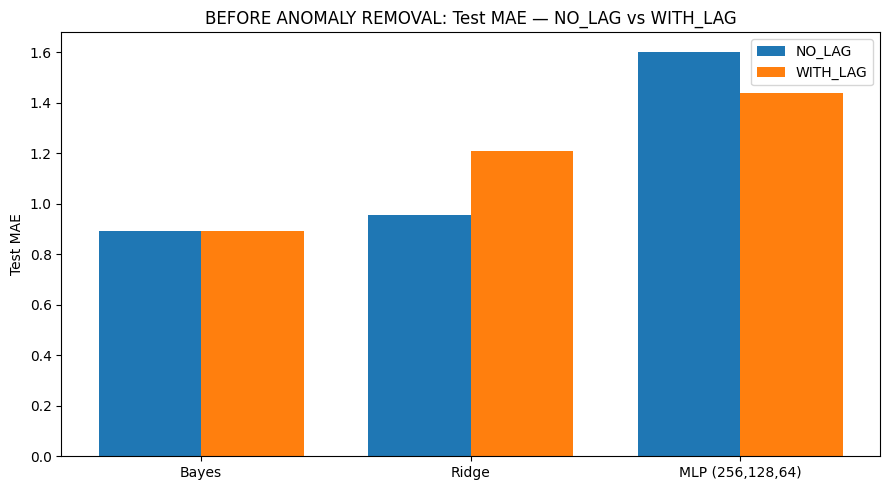

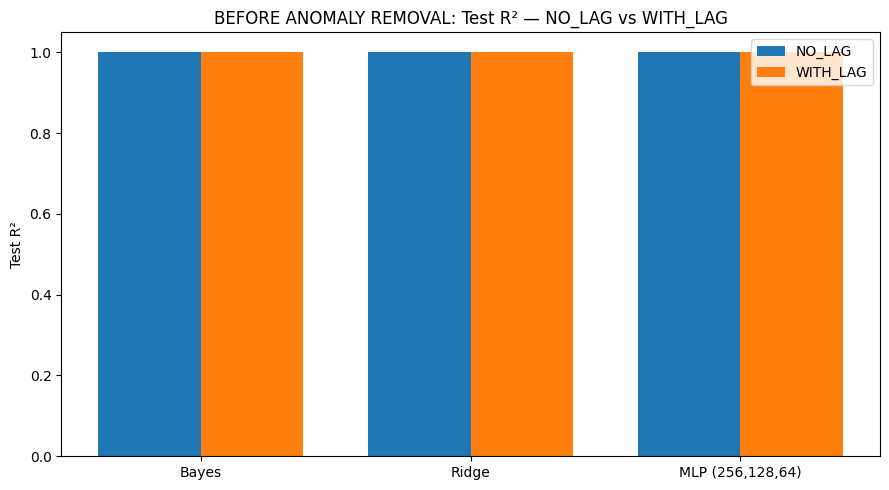

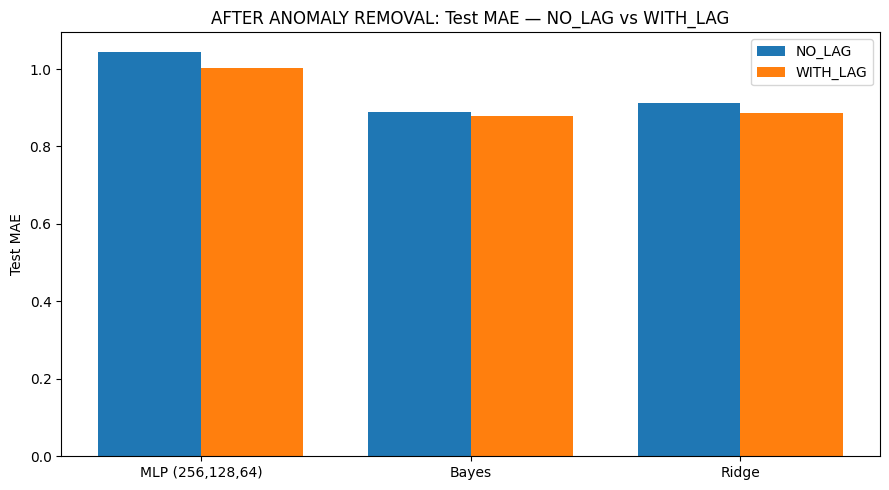

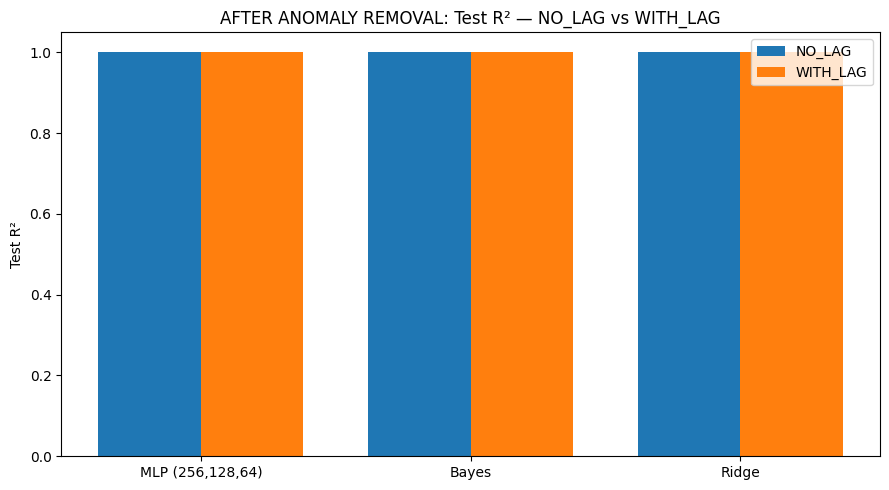


=== TOP 3: BEFORE_ANOMALY | NO_LAG ===
         Stage    Lag            Combo            Model  Score  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
BEFORE_ANOMALY NO_LAG SPATIAL+TEMPORAL            Bayes  0.974    1.000     0.890     2.949      1.717      3.574
BEFORE_ANOMALY NO_LAG SPATIAL+TEMPORAL            Ridge  0.928    1.000     0.957     3.161      1.778      3.859
BEFORE_ANOMALY NO_LAG SPATIAL+TEMPORAL MLP (256,128,64)  0.000    1.000     1.600     8.076      2.842      4.704

=== TOP 3: BEFORE_ANOMALY | WITH_LAG ===
         Stage      Lag            Combo            Model  Score  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
BEFORE_ANOMALY WITH_LAG SPATIAL+TEMPORAL            Bayes  0.958    1.000     0.891     4.494      2.120      3.617
BEFORE_ANOMALY WITH_LAG SPATIAL+TEMPORAL            Ridge  0.463    1.000     1.211     5.589      2.364      4.681
BEFORE_ANOMALY WITH_LAG SPATIAL+TEMPORAL MLP (256,128,64)  0.237    1.000     1.437     7.956      2.821      4.79

In [203]:
# ==== Experiments over SPATIAL / TEMPORAL / SPATIAL+TEMPORAL (Train & Test: multi-metric score)
#      + Compare WITH vs WITHOUT lag1 (single-split) + Visualize best-3 MODELS (not hybrids)
# NOTE: Keeps your existing logic; only adds the lag-compare + plots at the end.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    IsolationForest
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20

PATH = r"/Users/izarin2/Desktop/My Research/Project1/My Project/Dataset/Airsage Dataset/UNL/NebraskaLakes_Cleaned_round_agg2.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ============================================================================
# ANOMALY DETECTION ENSEMBLE: IF + LOF + OCSVM
# A row is removed only when at least 2 of the 3 detectors vote anomaly.
# No IQR trimming is used.
# ============================================================================

# ---------------- Anomaly configuration ----------------
ANOMALY_CONTAMINATION = 0.05
ANOMALY_VOTE_THRESHOLD = 2
ANOMALY_MAX_FIT_ROWS = 20000
ANOMALY_RANDOM_STATE = 42  

# ---------------- Save dataset BEFORE anomaly removal ----------------
df_before_anomaly = df.copy()
print(f"\nRows BEFORE anomaly removal saved for comparison: {len(df_before_anomaly):,}")

# Use numeric predictors only; exclude the target count.
anomaly_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "count"
    and df[c].notna().sum() > 0
    and df[c].nunique(dropna=True) > 1
]

if not anomaly_features:
    raise RuntimeError("No usable numeric predictor columns were found for anomaly detection.")

# Median imputation and standardization for LOF and OCSVM.
anomaly_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_anomaly = anomaly_preprocessor.fit_transform(df[anomaly_features])
X_anomaly = np.asarray(X_anomaly, dtype=np.float32)

# Fit LOF and OCSVM on a reproducible subset when the dataset is large.
rng = np.random.default_rng(ANOMALY_RANDOM_STATE)
if len(X_anomaly) > ANOMALY_MAX_FIT_ROWS:
    fit_idx = rng.choice(len(X_anomaly), size=ANOMALY_MAX_FIT_ROWS, replace=False)
else:
    fit_idx = np.arange(len(X_anomaly))

X_fit_anomaly = X_anomaly[fit_idx]

print("\n" + "=" * 72)
print("ANOMALY DETECTION: IF + LOF + OCSVM MAJORITY VOTING")
print("=" * 72)
print(f"Rows before anomaly removal : {len(df):,}")
print(f"Anomaly feature count       : {len(anomaly_features):,}")
print(f"Rows used to fit LOF/OCSVM  : {len(X_fit_anomaly):,}")
print(f"Detector contamination      : {ANOMALY_CONTAMINATION:.5%}")
print(f"Final anomaly vote rule     : >= {ANOMALY_VOTE_THRESHOLD} detectors")

# ---------------- 1) Isolation Forest ----------------
if_detector = IsolationForest(
    n_estimators=300,
    contamination=ANOMALY_CONTAMINATION,
    max_samples="auto",
    n_jobs=-1,
    random_state=ANOMALY_RANDOM_STATE,
)
if_raw = if_detector.fit_predict(X_anomaly)
if_flag = (if_raw == -1).astype(np.int8)

# ---------------- 2) Local Outlier Factor ----------------
lof_detector = LocalOutlierFactor(
    n_neighbors=35,
    contamination=ANOMALY_CONTAMINATION,
    novelty=True,
    n_jobs=-1,
)
lof_detector.fit(X_fit_anomaly)
lof_raw = lof_detector.predict(X_anomaly)
lof_flag = (lof_raw == -1).astype(np.int8)

# ---------------- 3) One-Class SVM ----------------
ocsvm_detector = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=ANOMALY_CONTAMINATION,
    cache_size=2000,
)
ocsvm_detector.fit(X_fit_anomaly)
ocsvm_raw = ocsvm_detector.predict(X_anomaly)
ocsvm_flag = (ocsvm_raw == -1).astype(np.int8)

# ---------------- Majority vote + exact 5% deterministic removal ----------------
anomaly_votes = if_flag + lof_flag + ocsvm_flag

# Raw majority-vote result for inspection only
majority_vote_flag = (
    anomaly_votes >= ANOMALY_VOTE_THRESHOLD
).astype(np.int8)

# Build comparable anomaly-severity scores from all 3 detectors.
# Higher score means more anomalous.
if_score = -if_detector.score_samples(X_anomaly)
lof_score = -lof_detector.score_samples(X_anomaly)
ocsvm_score = -ocsvm_detector.score_samples(X_anomaly)

def _minmax_score(a):
    a = np.asarray(a, dtype=float)
    amin = np.nanmin(a)
    amax = np.nanmax(a)
    if not np.isfinite(amin) or not np.isfinite(amax) or amax == amin:
        return np.zeros_like(a, dtype=float)
    return (a - amin) / (amax - amin)

combined_anomaly_score = (
    _minmax_score(if_score)
    + _minmax_score(lof_score)
    + _minmax_score(ocsvm_score)
) / 3.0

# Remove exactly 5% of the ORIGINAL rows.
target_remove = int(round(len(df) * ANOMALY_CONTAMINATION))
target_remove = max(0, min(target_remove, len(df)))

rank_df = pd.DataFrame({
    "Anomaly_Votes": anomaly_votes,
    "Combined_Anomaly_Score": combined_anomaly_score,
    "Original_Position": np.arange(len(df)),
}, index=df.index)

remove_index = (
    rank_df
    .sort_values(
        ["Anomaly_Votes", "Combined_Anomaly_Score", "Original_Position"],
        ascending=[False, False, True]
    )
    .head(target_remove)
    .index
)

final_anomaly_flag = pd.Series(0, index=df.index, dtype=np.int8)
final_anomaly_flag.loc[remove_index] = 1

# Keep anomaly flags for verification.
df_anomaly_flagged = df.copy()
df_anomaly_flagged["IF_Anomaly"] = if_flag
df_anomaly_flagged["LOF_Anomaly"] = lof_flag
df_anomaly_flagged["OCSVM_Anomaly"] = ocsvm_flag
df_anomaly_flagged["Anomaly_Votes"] = anomaly_votes
df_anomaly_flagged["Majority_Vote_Anomaly"] = majority_vote_flag
df_anomaly_flagged["Combined_Anomaly_Score"] = combined_anomaly_score
df_anomaly_flagged["Final_Anomaly"] = final_anomaly_flag.to_numpy()

df_detected_anomalies = df_anomaly_flagged.loc[
    df_anomaly_flagged["Final_Anomaly"] == 1
].copy()

# Remove the exact ranked 5% anomalies.
df = df_anomaly_flagged.loc[
    df_anomaly_flagged["Final_Anomaly"] == 0
].copy()

detector_cols = [
    "IF_Anomaly", "LOF_Anomaly", "OCSVM_Anomaly",
    "Anomaly_Votes", "Majority_Vote_Anomaly",
    "Combined_Anomaly_Score", "Final_Anomaly"
]
df = df.drop(columns=detector_cols, errors="ignore")

# ---------------- Save dataset AFTER anomaly removal ----------------
df_after_anomaly = df.copy()

rows_before_anomaly = len(df_before_anomaly)
rows_after_anomaly = len(df_after_anomaly)
rows_removed_anomaly = rows_before_anomaly - rows_after_anomaly
pct_removed_anomaly = (
    rows_removed_anomaly / rows_before_anomaly * 100
    if rows_before_anomaly > 0 else 0
)

print("-" * 72)
print(f"Isolation Forest anomalies : {int(if_flag.sum()):,}")
print(f"LOF anomalies              : {int(lof_flag.sum()):,}")
print(f"OCSVM anomalies            : {int(ocsvm_flag.sum()):,}")
print(f"Raw majority-vote anomalies: {int(majority_vote_flag.sum()):,}")
print(f"Exact 5% anomalies removed : {rows_removed_anomaly:,}")
print(f"Rows after anomaly removal : {rows_after_anomaly:,}")
print(f"Percent removed            : {pct_removed_anomaly:.2f}%")
print("=" * 72)

if len(df) == 0:
    raise RuntimeError(
        "All rows were marked anomalous. Reduce ANOMALY_CONTAMINATION or "
        "increase ANOMALY_VOTE_THRESHOLD."
    )

show_cols = [
    c for c in [
        "poi_id", "poi", "date", "count",
        "IF_Anomaly", "LOF_Anomaly", "OCSVM_Anomaly",
        "Anomaly_Votes", "Majority_Vote_Anomaly",
        "Combined_Anomaly_Score", "Final_Anomaly"
    ] if c in df_detected_anomalies.columns
]

print("\n=== DETECTED ANOMALIES: FIRST 30 ROWS ===")
if not df_detected_anomalies.empty:
    print(
        df_detected_anomalies[show_cols]
        .sort_values(["Anomaly_Votes", "count"], ascending=[False, False])
        .head(30)
        .to_string(index=False)
    )
else:
    print("No rows received at least two anomaly votes.")

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day

def _m2s(m):
    return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3

df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

# ---- leak-safe lag1 ----
orig_idx = df.index
if "poi_id" in df.columns:
    s = (df[["poi_id", "date", "count"]]
         .sort_values(["poi_id", "date"], kind="mergesort")
         .groupby("poi_id", sort=False)["count"]
         .shift(1))
else:
    s = (df[["date", "count"]]
         .sort_values(["date"], kind="mergesort")["count"]
         .shift(1))

df["lag1"] = s.reindex(orig_idx)

# ---------------- Feature combos (BASE) ----------------
BASE_COMBOS = {
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25,
                             random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    thr = np.quantile(y_te, 0.8)   # top 20% busy
    y_te_bin = (y_te >= thr).astype(int)

    rows = []
    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)

        test_r2  = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)
        test_rmse = np.sqrt(test_mse)
        test_mape = np.mean(
            np.abs((y_te - pred_te) / np.clip(np.abs(y_te), 1e-8, None))
        ) * 100

        try:
            if len(np.unique(y_te_bin)) < 2:
                test_auc = np.nan
            else:
                test_auc = roc_auc_score(y_te_bin, pred_te)
        except Exception:
            test_auc = np.nan

        try:
            y_pred_bin = (pred_te >= thr).astype(int)
            test_p = precision_score(y_te_bin, y_pred_bin, zero_division=0)
            test_r = recall_score(y_te_bin, y_pred_bin, zero_division=0)
        except Exception:
            test_p, test_r = np.nan, np.nan

        rows.append({
            "Combo": combo_name,
            "Model": name,
            "Train_R2":  train_r2,
            "Train_MAE": train_mae,
            "Test_R2":   test_r2,
            "Test_MAE":  test_mae,
            "Test_MSE":  test_mse,
            "Test_RMSE": test_rmse,
            "Test_MAPE": test_mape,
            "Test_AUC":  test_auc,
            "Test_P":    test_p,
            "Test_R":    test_r,
        })

    res = pd.DataFrame(rows)

    for mname in ["Test_R2", "Test_AUC", "Test_P", "Test_R"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=False)

    res["Score"] = res[
        ["Test_R2_N","Test_AUC_N","Test_P_N","Test_R_N","Test_MAE_N","Test_MSE_N"]
    ].mean(axis=1)

    return (res.sort_values(["Combo","Score"], ascending=[True, False])
              .reset_index(drop=True))

# ---------------- Run all combos (BASE) ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE",
        "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE",
        "Test_AUC","Test_P","Test_R"
    ]].sort_values(["Combo","Score"], ascending=[True, False])
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO AFTER ANOMALY REMOVAL (by combined Score) ===")
    print(ranked[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE",
        "Test_R2","Test_MAE","Test_MSE","Test_RMSE","Test_MAPE",
        "Test_AUC","Test_P","Test_R"
    ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))



# =========================================================================================
# =============== ADD-ON: BEFORE/AFTER ANOMALY REMOVAL + LAG/NO_LAG — 4 PLOTS =========================
# =========================================================================================

def prepare_stage_features(_df):
    """
    Rebuild spatial, temporal, and lag1 features for either BEFORE_ANOMALY or AFTER_ANOMALY.
    """
    _df = _df.copy()

    _df["poi_id_code"] = _df["poi_id"].astype("category").cat.codes

    spatial_cols_stage = []
    for c in _df.columns:
        if (
            c in spatial_exact
            or c in spatial_race
            or any(str(c).startswith(p) for p in spatial_prefixes)
        ):
            spatial_cols_stage.append(c)

    spatial_numeric_stage = [
        c for c in spatial_cols_stage
        if pd.api.types.is_numeric_dtype(_df[c]) and c != "count"
    ]

    if "poi_id_code" not in spatial_numeric_stage:
        spatial_numeric_stage.append("poi_id_code")

    spatial_numeric_stage = [
        c for c in spatial_numeric_stage
        if c not in LEAKY
    ]

    _df["dow"] = _df["date"].dt.dayofweek
    _df["is_weekend"] = (_df["dow"] >= 5).astype(int)
    _df["week"] = _df["date"].dt.isocalendar().week.astype(int)
    _df["month"] = _df["date"].dt.month
    _df["day"] = _df["date"].dt.day

    _df["season"] = _df["month"].apply(lambda m: _m2s(int(m)))
    _df["date_ordinal"] = _df["date"].map(
        lambda x: x.toordinal() if pd.notnull(x) else np.nan
    )

    _df["is_month_start"] = _df["date"].dt.is_month_start.astype(int)
    _df["is_month_end"] = _df["date"].dt.is_month_end.astype(int)
    _df["is_quarter_start"] = _df["date"].dt.is_quarter_start.astype(int)
    _df["is_quarter_end"] = _df["date"].dt.is_quarter_end.astype(int)

    hour_cols_stage = [
        c for c in _df.columns
        if isinstance(c, str)
        and len(c) == 4
        and c.startswith("hh")
        and c[2:].isdigit()
    ]

    temporal_stage = [
        "is_weekend", "season", "month", "week", "dow", "day", "date_ordinal",
        "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end"
    ] + [c for c in hour_cols_stage if c in _df.columns]

    orig_idx_stage = _df.index

    if "poi_id" in _df.columns:
        s_stage = (
            _df[["poi_id", "date", "count"]]
            .sort_values(["poi_id", "date"], kind="mergesort")
            .groupby("poi_id", sort=False)["count"]
            .shift(1)
        )
    else:
        s_stage = (
            _df[["date", "count"]]
            .sort_values(["date"], kind="mergesort")["count"]
            .shift(1)
        )

    _df["lag1"] = s_stage.reindex(orig_idx_stage)

    combos_stage = {
        "SPATIAL+TEMPORAL": list(
            dict.fromkeys(spatial_numeric_stage + temporal_stage)
        )
    }

    return _df, combos_stage


def _make_combos_no_lag_stage(base_combos):
    return {
        k: [f for f in v if f != "lag1"]
        for k, v in base_combos.items()
    }


def _make_combos_with_lag_stage(base_combos):
    out = {}

    for k, v in base_combos.items():
        vv = list(v)

        if "lag1" not in vv:
            vv.append("lag1")

        out[k] = list(dict.fromkeys(vv))

    return out


def run_lag_compare_for_stage(_df_stage, stage_name):
    """
    Runs both NO_LAG and WITH_LAG models for one dataset stage.
    """
    _df_stage, combos_stage = prepare_stage_features(_df_stage)

    combos_no_lag = _make_combos_no_lag_stage(combos_stage)
    combos_with_lag = _make_combos_with_lag_stage(combos_stage)

    results = []

    for lag_name, combos_dict in [
        ("NO_LAG", combos_no_lag),
        ("WITH_LAG", combos_with_lag),
    ]:
        for combo_name, feats in combos_dict.items():

            feats = [f for f in feats if f in _df_stage.columns]

            if not feats:
                continue

            X, y = build_Xy(_df_stage, feats)

            if len(X) == 0 or X.shape[1] == 0:
                continue

            res = eval_models_both(X, y, MODELS_TOP3_FOR_PLOTS, combo_name)
            res.insert(0, "Lag", lag_name)
            res.insert(0, "Stage", stage_name)
            results.append(res)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


def plot_lag_vs_no_lag_for_stage(tbl_stage, stage_title, metric, title_metric, ylabel):
    """
    Make one grouped bar plot for one stage and one metric.
    """

    if tbl_stage.empty:
        print(f"No data for {stage_title} - {metric}")
        return

    top_models = (
        tbl_stage
        .sort_values("Score", ascending=False)["Model"]
        .drop_duplicates()
        .head(3)
        .tolist()
    )

    plot_df = tbl_stage[tbl_stage["Model"].isin(top_models)].copy()

    metric_pivot = (
        plot_df
        .pivot_table(
            index="Model",
            columns="Lag",
            values=metric,
            aggfunc="mean"
        )
        .reindex(top_models)
    )

    for col in ["NO_LAG", "WITH_LAG"]:
        if col not in metric_pivot.columns:
            metric_pivot[col] = np.nan

    x = np.arange(len(top_models))
    w = 0.38

    plt.figure(figsize=(9, 5))

    plt.bar(
        x - w / 2,
        metric_pivot["NO_LAG"].values,
        width=w,
        label="NO_LAG"
    )

    plt.bar(
        x + w / 2,
        metric_pivot["WITH_LAG"].values,
        width=w,
        label="WITH_LAG"
    )

    plt.xticks(x, top_models, rotation=0)
    plt.ylabel(ylabel)
    plt.title(f"{stage_title}: {title_metric} — NO_LAG vs WITH_LAG")
    plt.legend()
    plt.tight_layout()
    plt.show()



# ---------------- Use only TOP-3 models for faster before/after lag plots ----------------
TOP3_MODELS_FOR_PLOTS = (
    final_tbl
    .sort_values("Score", ascending=False)
    .head(3)["Model"]
    .tolist()
)

MODELS_TOP3_FOR_PLOTS = [
    (name, model)
    for name, model in MODELS
    if name in TOP3_MODELS_FOR_PLOTS
]

if len(MODELS_TOP3_FOR_PLOTS) == 0:
    MODELS_TOP3_FOR_PLOTS = MODELS

print("\nUsing only TOP-3 models for BEFORE/AFTER ANOMALY REMOVAL lag/no-lag plots:")
print([name for name, _ in MODELS_TOP3_FOR_PLOTS])

# ---------------- Run comparison BEFORE and AFTER ANOMALY REMOVAL ----------------
tbl_before_anomaly = run_lag_compare_for_stage(df_before_anomaly, "BEFORE_ANOMALY")
tbl_after_anomaly = run_lag_compare_for_stage(df_after_anomaly, "AFTER_ANOMALY")

tbl_anomaly_lag_compare = pd.concat(
    [tbl_before_anomaly, tbl_after_anomaly],
    ignore_index=True
)

print("\n" + "=" * 90)
print("BEFORE/AFTER ANOMALY REMOVAL + NO_LAG/WITH_LAG RESULTS")
print("=" * 90)

if not tbl_anomaly_lag_compare.empty:
    print(
        tbl_anomaly_lag_compare[[
            "Stage", "Lag", "Combo", "Model", "Score",
            "Train_R2", "Train_MAE",
            "Test_R2", "Test_MAE", "Test_MSE",
            "Test_RMSE", "Test_MAPE"
        ]]
        .sort_values(["Stage", "Lag", "Score"], ascending=[True, True, False])
        .to_string(index=False, float_format=lambda x: f"{x:.3f}")
    )
else:
    print("No BEFORE/AFTER ANOMALY REMOVAL lag comparison results.")


# =====================================================================================
# FOUR SEPARATE PLOTS
# =====================================================================================

# 1) BEFORE ANOMALY REMOVAL — MAE
plot_lag_vs_no_lag_for_stage(
    tbl_before_anomaly,
    stage_title="BEFORE ANOMALY REMOVAL",
    metric="Test_MAE",
    title_metric="Test MAE",
    ylabel="Test MAE"
)

# 2) BEFORE ANOMALY REMOVAL — R²
plot_lag_vs_no_lag_for_stage(
    tbl_before_anomaly,
    stage_title="BEFORE ANOMALY REMOVAL",
    metric="Test_R2",
    title_metric="Test R²",
    ylabel="Test R²"
)

# 3) AFTER ANOMALY REMOVAL — MAE
plot_lag_vs_no_lag_for_stage(
    tbl_after_anomaly,
    stage_title="AFTER ANOMALY REMOVAL",
    metric="Test_MAE",
    title_metric="Test MAE",
    ylabel="Test MAE"
)

# 4) AFTER ANOMALY REMOVAL — R²
plot_lag_vs_no_lag_for_stage(
    tbl_after_anomaly,
    stage_title="AFTER ANOMALY REMOVAL",
    metric="Test_R2",
    title_metric="Test R²",
    ylabel="Test R²"
)


# ---------------- Optional: Top-3 tables for each case ----------------
for stage_name, tbl_stage in [
    ("BEFORE_ANOMALY", tbl_before_anomaly),
    ("AFTER_ANOMALY", tbl_after_anomaly),
]:
    for lag_name in ["NO_LAG", "WITH_LAG"]:

        sub = tbl_stage[tbl_stage["Lag"] == lag_name]

        if sub.empty:
            continue

        print(f"\n=== TOP 3: {stage_name} | {lag_name} ===")
        print(
            sub
            .sort_values("Score", ascending=False)
            .head(3)[[
                "Stage", "Lag", "Combo", "Model", "Score",
                "Test_R2", "Test_MAE", "Test_MSE",
                "Test_RMSE", "Test_MAPE"
            ]]
            .to_string(index=False, float_format=lambda x: f"{x:.3f}")
        )

Visualization of ACTUAL vs PREDICTED — BEST 3 BASE MODELS


BEST 3 BASE MODELS — AFTER ANOMALY REMOVAL + WITH_LAG
        Stage      Lag            Combo            Model  Score  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
AFTER_ANOMALY WITH_LAG SPATIAL+TEMPORAL MLP (256,128,64) 0.8333   1.0000    1.0030    2.2922     1.5140     3.6052
AFTER_ANOMALY WITH_LAG SPATIAL+TEMPORAL            Ridge 0.4435   1.0000    0.8863    2.4113     1.5528     3.6820
AFTER_ANOMALY WITH_LAG SPATIAL+TEMPORAL            Bayes 0.2078   1.0000    0.8796    2.3959     1.5479     3.6676

Dataset stage      : AFTER ANOMALY REMOVAL
Lag condition      : WITH_LAG
Feature combination: SPATIAL+TEMPORAL
Number of features : 107
Lag1 included      : True
Base models        : ['MLP (256,128,64)', 'Ridge', 'Bayes']
Training after-anomaly WITH_LAG model: MLP (256,128,64)
Training after-anomaly WITH_LAG model: Ridge
Training after-anomaly WITH_LAG model: Bayes


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.27889e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


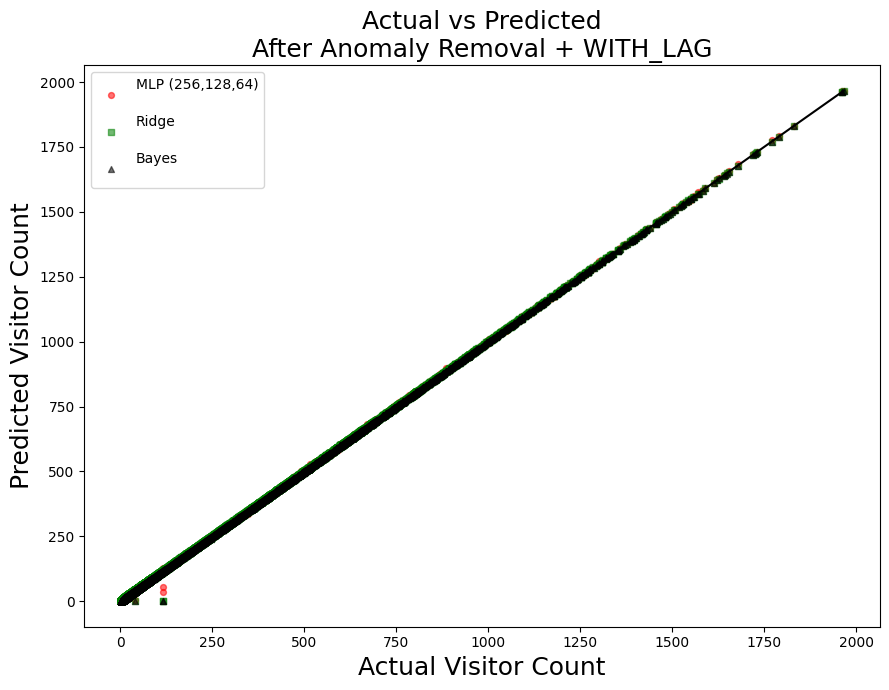

In [204]:
# =============================================================================
# ACTUAL vs PREDICTED — BEST 3 BASE MODELS
# AFTER ANOMALY REMOVAL + WITH_LAG ONLY
# Paste directly after your existing anomaly and lag comparison code
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# -------------------------------------------------------------------------
# 1. Check AFTER-ANOMALY and WITH_LAG results
# -------------------------------------------------------------------------
if tbl_after_anomaly.empty:
    raise ValueError(
        "tbl_after_anomaly is empty. "
        "Run the anomaly and lag comparison code first."
    )


# -------------------------------------------------------------------------
# 2. Keep only AFTER ANOMALY REMOVAL + WITH_LAG results
# -------------------------------------------------------------------------
after_anomaly_with_lag = (
    tbl_after_anomaly[
        tbl_after_anomaly["Lag"] == "WITH_LAG"
    ]
    .copy()
)

if after_anomaly_with_lag.empty:
    raise ValueError(
        "No WITH_LAG results were found after anomaly removal."
    )


# -------------------------------------------------------------------------
# 3. Select the best three BASE models using the combined Score
# -------------------------------------------------------------------------
best_3_base = (
    after_anomaly_with_lag
    .sort_values("Score", ascending=False)
    .drop_duplicates(subset=["Model"])
    .head(3)
    .reset_index(drop=True)
)

best_3_names = best_3_base["Model"].tolist()


print("\n" + "=" * 85)
print("BEST 3 BASE MODELS — AFTER ANOMALY REMOVAL + WITH_LAG")
print("=" * 85)

print(
    best_3_base[
        [
            "Stage",
            "Lag",
            "Combo",
            "Model",
            "Score",
            "Test_R2",
            "Test_MAE",
            "Test_MSE",
            "Test_RMSE",
            "Test_MAPE"
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("=" * 85)


# -------------------------------------------------------------------------
# 4. Create a dictionary of the original base models
# -------------------------------------------------------------------------
base_model_dictionary = {
    model_name: model_object
    for model_name, model_object in MODELS
}


# Confirm all selected models are available
missing_models = [
    model_name
    for model_name in best_3_names
    if model_name not in base_model_dictionary
]

if missing_models:
    raise ValueError(
        f"Selected models are missing from MODELS: {missing_models}"
    )


# -------------------------------------------------------------------------
# 5. Rebuild features using the AFTER-ANOMALY dataset
# -------------------------------------------------------------------------
df_after_anomaly_plot, after_anomaly_base_combos = (
    prepare_stage_features(df_after_anomaly)
)


# -------------------------------------------------------------------------
# 6. Create WITH_LAG feature combinations
# -------------------------------------------------------------------------
after_anomaly_with_lag_combos = (
    _make_combos_with_lag_stage(
        after_anomaly_base_combos
    )
)


# -------------------------------------------------------------------------
# 7. Use the feature combination associated with the best base model
# -------------------------------------------------------------------------
combo_name = best_3_base.iloc[0]["Combo"]

if combo_name not in after_anomaly_with_lag_combos:
    raise ValueError(
        f"{combo_name} was not found in "
        "after_anomaly_with_lag_combos."
    )


features = [
    feature
    for feature in after_anomaly_with_lag_combos[combo_name]
    if feature in df_after_anomaly_plot.columns
]


# Ensure lag1 is included
if "lag1" not in features:
    features.append("lag1")


features = list(dict.fromkeys(features))


if not features:
    raise ValueError(
        f"No usable features were found for {combo_name}."
    )


print("\nDataset stage      : AFTER ANOMALY REMOVAL")
print("Lag condition      : WITH_LAG")
print(f"Feature combination: {combo_name}")
print(f"Number of features : {len(features)}")
print(f"Lag1 included      : {'lag1' in features}")
print(f"Base models        : {best_3_names}")


# -------------------------------------------------------------------------
# 8. Rebuild X and y using AFTER-ANOMALY + WITH_LAG data
# -------------------------------------------------------------------------
X, y = build_Xy(
    df_after_anomaly_plot,
    features
)

if len(X) == 0:
    raise ValueError(
        "No complete rows were available after anomaly removal "
        "and lag1 construction."
    )


# -------------------------------------------------------------------------
# 9. Recreate the same train/test split used in model evaluation
# -------------------------------------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

y_actual = np.asarray(
    y_te,
    dtype=float
)


# -------------------------------------------------------------------------
# 10. Train the best three BASE models and predict
# -------------------------------------------------------------------------
base_predictions = {}

for model_name in best_3_names:

    model = clone(
        base_model_dictionary[model_name]
    )

    print(
        f"Training after-anomaly WITH_LAG model: "
        f"{model_name}"
    )

    model.fit(
        X_tr,
        y_tr
    )

    base_predictions[model_name] = np.asarray(
        model.predict(X_te),
        dtype=float
    )


# -------------------------------------------------------------------------
# 11. Plot settings
# -------------------------------------------------------------------------
markers = ["o", "s", "^"]
colors = ["red", "green", "black"]


# -------------------------------------------------------------------------
# 12. Actual vs Predicted — three base models in one diagram
# -------------------------------------------------------------------------
plt.figure(figsize=(9, 7))

all_values = [y_actual]


for index, model_name in enumerate(best_3_names):

    y_pred = base_predictions[model_name]

    r2 = r2_score(
        y_actual,
        y_pred
    )

    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    mse = mean_squared_error(
        y_actual,
        y_pred
    )

    rmse = np.sqrt(
        mse
    )

    mape = np.mean(
        np.abs(
            (y_actual - y_pred) /
            np.clip(
                np.abs(y_actual),
                1e-8,
                None
            )
        )
    ) * 100

    all_values.append(y_pred)

    plt.scatter(
        y_actual,
        y_pred,
        s=18,
        alpha=0.55,
        marker=markers[index],
        color=colors[index],
        label=(
            f"{model_name}\n"
           # f"R²={r2:.4f}, "
           # f"MAE={mae:.3f}, "
           # f"MSE={mse:.3f}, "
           # f"RMSE={rmse:.3f}, "
           # f"MAPE={mape:.3f}%"
        )
    )


# -------------------------------------------------------------------------
# 13. Perfect-prediction reference line
# -------------------------------------------------------------------------
minimum_value = min(
    np.nanmin(values)
    for values in all_values
)

maximum_value = max(
    np.nanmax(values)
    for values in all_values
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="black",
    linewidth=1.5
)


# -------------------------------------------------------------------------
# 14. Figure formatting
# -------------------------------------------------------------------------
plt.xlabel(
    "Actual Visitor Count",
    fontsize=18
)

plt.ylabel(
    "Predicted Visitor Count",
    fontsize=18
)

plt.title(
    "Actual vs Predicted\n"
    "After Anomaly Removal + WITH_LAG",
    fontsize=18
)

plt.legend(
    fontsize=10,
    loc="upper left"
)

plt.grid(False)
plt.tight_layout()
plt.show()

Apply Hybrid models (Stack and Vote) using top 3 base models 

In [205]:
# ---------------- HYBRID / STACKING over top-3 models per combo (single split) ----------------
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor,
)
from sklearn.model_selection import KFold  # for K-fold
# features for this combo

# ---------- Print feature information (only) ----------
print("\n" + "="*80)
print(f"Feature Combination : {combo_name}")
print(f"Total Features      : {len(feats)}")
print("Features:")
print(feats)
print("="*80)

# features for this combo
X, y = build_Xy(df, feats)

hybrid_rows = []

if not final_tbl.empty:
    # Get top-3 base models per combo according to single-split Score
    top3_per_combo_single = (
        final_tbl
        .sort_values(["Combo", "Score"], ascending=[True, False])
        .groupby("Combo", group_keys=False)
        .head(3)
        .reset_index(drop=True)
    )

    for combo_name, feats in BASE_COMBOS.items():
        if not feats:
            continue

        # features for this combo
        X, y = build_Xy(df, feats)
        if len(X) == 0 or X.shape[1] == 0:
            continue

        # single split (same config as eval_models_both)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )

        # top-3 model names for this combo
        subset = top3_per_combo_single[
            top3_per_combo_single["Combo"] == combo_name
        ]

        base_names = subset["Model"].unique().tolist()

        if len(base_names) == 0:
            continue

        # ---- fit base models once and collect predictions (for stacking input) ----
        P_tr_list = []
        P_te_list = []
        used_bases = []

        for name in base_names:
            # find model definition in MODELS
            base_def = None

            for mname, mdl in MODELS:
                if mname == name:
                    base_def = mdl
                    break

            if base_def is None:
                continue

            est = clone(base_def)
            est.fit(X_tr, y_tr)

            P_tr_list.append(est.predict(X_tr))
            P_te_list.append(est.predict(X_te))
            used_bases.append(name)

        if len(used_bases) == 0:
            continue

        P_tr = np.vstack(P_tr_list).T  # shape (n_train, k)
        P_te = np.vstack(P_te_list).T  # shape (n_test, k)

        # also prepare fresh (name, estimator) tuples for Voting / Stacking
        bases = []

        for name in used_bases:
            base_def = None

            for mname, mdl in MODELS:
                if mname == name:
                    base_def = mdl
                    break

            if base_def is None:
                continue

            bases.append((name, clone(base_def)))

        if len(bases) == 0:
            continue

        def eval_hybrid(hname, pred_te):
            # regression metrics
            test_r2 = r2_score(y_te, pred_te)
            test_mae = mean_absolute_error(y_te, pred_te)
            test_mse = mean_squared_error(y_te, pred_te)
            test_rmse = np.sqrt(test_mse)

            test_mape = (
                np.nanmean(
                    np.abs(
                        (y_te - pred_te)
                        / np.where(
                            np.abs(y_te) < 1e-8,
                            np.nan,
                            np.abs(y_te)
                        )
                    )
                )
                * 100
            )

            hybrid_rows.append({
                "Combo":     combo_name,
                "Hybrid":    hname,
                "Bases":     ",".join(used_bases),
                "Test_R2":   test_r2,
                "Test_MAE":  test_mae,
                "Test_MSE":  test_mse,
                "Test_RMSE": test_rmse,
                "Test_MAPE": test_mape,
            })

        # ---- Hybrid 1: VotingRegressor (equal weights across Top-3) ----
        vote = VotingRegressor(bases)
        vote.fit(X_tr, y_tr)

        pred_vote = vote.predict(X_te)
        eval_hybrid("VOTE", pred_vote)

        # ---- Hybrid 2–4: StackingRegressor with different meta-learners ----
        if len(bases) >= 2:
            # Linear meta
            stack_lin = StackingRegressor(
                estimators=bases,
                final_estimator=LinearRegression(),
                cv=3,
                passthrough=True,
            )

            # stack_lin.fit(X_tr, y_tr)
            # pred_stack_lin = stack_lin.predict(X_te)
            # eval_hybrid("STACK_Lin", pred_stack_lin)

            # Ridge meta
            stack_ridge = StackingRegressor(
                estimators=bases,
                final_estimator=Ridge(
                    alpha=1.0,
                    random_state=RANDOM_STATE
                ),
                cv=3,
                passthrough=True,
            )

            stack_ridge.fit(X_tr, y_tr)
            pred_stack_ridge = stack_ridge.predict(X_te)

            eval_hybrid(
                "STACK_Ridge",
                pred_stack_ridge
            )

            # Gradient Boosting meta
            stack_gbr = StackingRegressor(
                estimators=bases,
                final_estimator=GradientBoostingRegressor(
                    random_state=RANDOM_STATE,
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                ),
                cv=3,
                passthrough=True,
            )

            stack_gbr.fit(X_tr, y_tr)
            pred_stack_gbr = stack_gbr.predict(X_te)

            eval_hybrid(
                "STACK_GBR",
                pred_stack_gbr
            )

# Build hybrid score table (single split)
if hybrid_rows:
    df_h = pd.DataFrame(hybrid_rows)

    # normalize metrics and compute Score_H (same style as before)
    for mname in ["Test_R2"]:
        df_h[f"{mname}_N"] = _norm_series(
            df_h[mname],
            higher_is_better=True
        )

    for mname in [
        "Test_MAE",
        "Test_MSE",
        "Test_RMSE",
        "Test_MAPE"
    ]:
        df_h[f"{mname}_N"] = _norm_series(
            df_h[mname],
            higher_is_better=False
        )

    norm_cols_h = [
        "Test_R2_N",
        "Test_MAE_N",
        "Test_MSE_N",
        "Test_RMSE_N",
        "Test_MAPE_N",
    ]

    df_h["Score_H"] = df_h[norm_cols_h].mean(axis=1)

    df_h = (
        df_h
        .sort_values(
            "Score_H",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(
        "\n=== ALL HYBRID / STACKING MODELS "
        "(single split, sorted by Score_H desc) ==="
    )

    print(
        df_h[
            [
                "Combo",
                "Hybrid",
                "Bases",
                "Score_H",
                "Test_R2",
                "Test_MAE",
                "Test_MSE",
                "Test_RMSE",
                "Test_MAPE",
            ]
        ].to_string(
            index=False,
            float_format=lambda x: f"{x:.3f}"
        )
    )

else:
    print(
        "\nNo hybrid models were built "
        "(check that final_tbl and features are non-empty)."
    )


Feature Combination : SPATIAL+TEMPORAL
Total Features      : 106
Features:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female_15_17', 'female_18_19', 'female_20_20', 'female_21_21', 'female_22_24', 'female_25_29', 'female_30_34', 'female_35_39', 'female_40_44', 'female_45_49', 'female_50_54', 'female_55_59', 'female_60_61', 'female_62_64', 'female_65_66', 'female_67_69', 'female_70_74', 'female_75_7

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.29818e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.29818e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.29818e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.24969e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/p


=== ALL HYBRID / STACKING MODELS (single split, sorted by Score_H desc) ===
           Combo      Hybrid                        Bases  Score_H  Test_R2  Test_MAE  Test_MSE  Test_RMSE  Test_MAPE
SPATIAL+TEMPORAL   STACK_GBR Ridge,Bayes,MLP (256,128,64)    0.600    1.000     0.951     3.099      1.760      3.406
SPATIAL+TEMPORAL        VOTE Ridge,Bayes,MLP (256,128,64)    0.400    1.000     0.862     3.687      1.920      3.325
SPATIAL+TEMPORAL STACK_Ridge Ridge,Bayes,MLP (256,128,64)    0.393    1.000     0.865     3.721      1.929      3.310


Rank hybrid models interm of score

In [206]:
# ============================================================
# SAVE HYBRID RESULTS AFTER EXACT 5% ANOMALY DETECTION
# ============================================================

if "df_h" not in globals() or df_h.empty:
    raise ValueError(
        "Anomaly hybrid results were not created. "
        "Run the hybrid-model section using df_after first."
    )

df_h_after_anomaly_2pct = df_h.copy()

required_result_columns = [
    "Combo",
    "Hybrid",
    "Bases",
    "Score_H",
    "Test_MAE",
    "Test_MSE",
    "Test_R2",
    "Test_RMSE",
    "Test_MAPE"
]

available_result_columns = [
    column
    for column in required_result_columns
    if column in df_h_after_anomaly_2pct.columns
]

print(
    "\nSaved hybrid results after exact 5% "
    "anomaly detection:"
)

print(
    df_h_after_anomaly_2pct[
        available_result_columns
    ]
    .sort_values(
        "Score_H",
        ascending=False
    )
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


Saved hybrid results after exact 5% anomaly detection:
           Combo      Hybrid                        Bases  Score_H  Test_MAE  Test_MSE  Test_R2  Test_RMSE  Test_MAPE
SPATIAL+TEMPORAL   STACK_GBR Ridge,Bayes,MLP (256,128,64) 0.600000  0.951414  3.098564 0.999946   1.760274   3.406121
SPATIAL+TEMPORAL        VOTE Ridge,Bayes,MLP (256,128,64) 0.400412  0.861507  3.686931 0.999936   1.920138   3.325083
SPATIAL+TEMPORAL STACK_Ridge Ridge,Bayes,MLP (256,128,64) 0.393020  0.864645  3.721086 0.999935   1.929012   3.309615


     Model_Type  Model  Test_MAE
0    Base Model  Bayes  0.879613
1  Hybrid Model   VOTE  0.861507


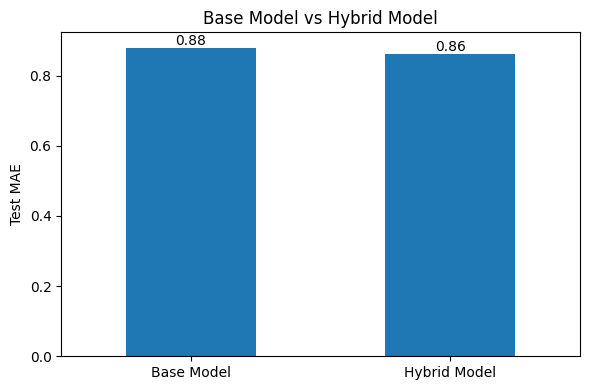

In [207]:
# Best base model
best_base = (
    tbl_after_anomaly
    .sort_values("Test_MAE")
    .iloc[0]
)

# Best hybrid model
best_hybrid = (
    df_h
    .sort_values("Test_MAE")
    .iloc[0]
)

# Comparison table
compare_df = pd.DataFrame({
    "Model_Type": ["Base Model", "Hybrid Model"],
    "Model": [
        best_base["Model"],
        best_hybrid["Hybrid"]
    ],
    "Test_MAE": [
        best_base["Test_MAE"],
        best_hybrid["Test_MAE"]
    ]
})

print(compare_df)

# Plot
ax = compare_df.plot(
    x="Model_Type",
    y="Test_MAE",
    kind="bar",
    legend=False,
    figsize=(6, 4)
)

plt.title("Base Model vs Hybrid Model")
plt.ylabel("Test MAE")
plt.xlabel("")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

EXACT 2% ANOMALY ROW IDENTIFIERS SAVED

In [208]:
# =============================================================================
# SAVE EXACT 2% ANOMALY ROW IDENTIFIERS
# Run immediately after the exact 2% anomaly-removal section
# =============================================================================

# Confirm that the original row index was preserved
if not df_before_anomaly.index.is_unique:
    raise ValueError(
        "df_before_anomaly has duplicate index values. "
        "A unique row identifier is required."
    )

if not df_after_anomaly.index.isin(df_before_anomaly.index).all():
    raise ValueError(
        "df_after_anomaly does not preserve the original row indices."
    )

# Save the original, retained, and removed row identifiers
ANOMALY_2PCT_ORIGINAL_IDS = set(
    df_before_anomaly.index.tolist()
)

ANOMALY_2PCT_RETAINED_IDS = set(
    df_after_anomaly.index.tolist()
)

ANOMALY_2PCT_REMOVED_IDS = (
    ANOMALY_2PCT_ORIGINAL_IDS
    - ANOMALY_2PCT_RETAINED_IDS
)

print("\n" + "=" * 72)
print("EXACT 2% ANOMALY ROW IDENTIFIERS SAVED")
print("=" * 72)
print(
    f"Original rows : "
    f"{len(ANOMALY_2PCT_ORIGINAL_IDS):,}"
)
print(
    f"Retained rows : "
    f"{len(ANOMALY_2PCT_RETAINED_IDS):,}"
)
print(
    f"Removed rows  : "
    f"{len(ANOMALY_2PCT_REMOVED_IDS):,}"
)
print("=" * 72)

# Verify that the saved count matches the anomaly-removal result
assert (
    len(ANOMALY_2PCT_REMOVED_IDS)
    == len(df_before_anomaly) - len(df_after_anomaly)
), (
    "The saved anomaly row IDs do not match the number "
    "of rows removed by anomaly detection."
)


EXACT 2% ANOMALY ROW IDENTIFIERS SAVED
Original rows : 123,626
Retained rows : 117,445
Removed rows  : 6,181


In [209]:
# =============================================================================
# EXACT COMPARISON: IQR FILTERING vs EXACT 2% ANOMALY DETECTION
#
# IMPORTANT:
# This section uses the row identifiers saved directly from the existing
# IQR section and the existing exact-2% anomaly section. It does not
# recalculate either method, so all totals must match the notebook output.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. CHECK THAT THE REQUIRED SAVED RESULTS EXIST
# -----------------------------------------------------------------------------
required_saved_objects = [
    "IQR_ORIGINAL_IDS",
    "IQR_REMOVED_IDS",
    "ANOMALY_2PCT_ORIGINAL_IDS",
    "ANOMALY_2PCT_REMOVED_IDS",
]

missing_objects = [
    name for name in required_saved_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the existing IQR section and the exact 2% anomaly section first. "
        f"Missing saved objects: {missing_objects}"
    )


# -----------------------------------------------------------------------------
# 2. VERIFY THAT BOTH METHODS USED THE SAME ORIGINAL ROWS
# -----------------------------------------------------------------------------
same_original_rows = (
    IQR_ORIGINAL_IDS == ANOMALY_2PCT_ORIGINAL_IDS
)




ORIGINAL_IDS = IQR_ORIGINAL_IDS


# -----------------------------------------------------------------------------
# 3. CALCULATE THE EXACT OVERLAP
# -----------------------------------------------------------------------------
both_removed_ids = (
    IQR_REMOVED_IDS
    & ANOMALY_2PCT_REMOVED_IDS
)

iqr_only_ids = (
    IQR_REMOVED_IDS
    - ANOMALY_2PCT_REMOVED_IDS
)

anomaly_only_ids = (
    ANOMALY_2PCT_REMOVED_IDS
    - IQR_REMOVED_IDS
)

removed_by_either_ids = (
    IQR_REMOVED_IDS
    | ANOMALY_2PCT_REMOVED_IDS
)

retained_by_both_ids = (
    ORIGINAL_IDS
    - removed_by_either_ids
)

n_original = len(ORIGINAL_IDS)
n_iqr_only = len(iqr_only_ids)
n_both = len(both_removed_ids)
n_anomaly_only = len(anomaly_only_ids)
n_retained_both = len(retained_by_both_ids)

n_iqr_total = len(IQR_REMOVED_IDS)
n_anomaly_total = len(ANOMALY_2PCT_REMOVED_IDS)

overlap_summary = pd.DataFrame({
    "Category": [
        "IQR only",
        "Both IQR and anomaly detection",
        "Anomaly detection only",
        "Retained by both",
    ],
    "Rows": [
        n_iqr_only,
        n_both,
        n_anomaly_only,
        n_retained_both,
    ],
})

overlap_summary["Percent_of_Original"] = (
    overlap_summary["Rows"] / n_original * 100.0
)

jaccard_overlap = (
    n_both / len(removed_by_either_ids)
    if removed_by_either_ids
    else np.nan
)

iqr_overlap_percent = (
    n_both / n_iqr_total * 100.0
    if n_iqr_total
    else np.nan
)

anomaly_overlap_percent = (
    n_both / n_anomaly_total * 100.0
    if n_anomaly_total
    else np.nan
)

print("\n" + "=" * 82)
print("EXACT OVERLAP: IQR vs EXACT 2% ANOMALY DETECTION")
print("=" * 82)
print(
    overlap_summary.to_string(
        index=False,
        formatters={
            "Rows": lambda x: f"{int(x):,}",
            "Percent_of_Original": lambda x: f"{x:.3f}%",
        },
    )
)
print("-" * 82)
print(f"Total rows removed by IQR             : {n_iqr_total:,}")
print(f"Total rows removed by anomaly method  : {n_anomaly_total:,}")
print(f"Rows removed by both methods          : {n_both:,}")
print(f"Jaccard overlap                       : {jaccard_overlap:.4f}")
print(f"IQR removals also flagged anomalous   : {iqr_overlap_percent:.2f}%")
print(f"Anomalies also removed by IQR         : {anomaly_overlap_percent:.2f}%")
print("=" * 82)


EXACT OVERLAP: IQR vs EXACT 2% ANOMALY DETECTION
                      Category   Rows Percent_of_Original
                      IQR only 37,313             30.182%
Both IQR and anomaly detection  6,098              4.933%
        Anomaly detection only     83              0.067%
              Retained by both 80,133             64.818%
----------------------------------------------------------------------------------
Total rows removed by IQR             : 43,411
Total rows removed by anomaly method  : 6,181
Rows removed by both methods          : 6,098
Jaccard overlap                       : 0.1402
IQR removals also flagged anomalous   : 14.05%
Anomalies also removed by IQR         : 98.66%


MATCHED HYBRID PERFORMANCE: IQR vs EXACT 2% ANOMALY

In [210]:
# ============================================================
# HYBRID MODEL COMPARISON:
# IQR FILTERING vs EXACT 2% ANOMALY DETECTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Check required hybrid tables
# ------------------------------------------------------------
required_hybrid_tables = [
    "df_h_after_iqr",
    "df_h_after_anomaly_2pct"
]

missing_hybrid_tables = [
    name
    for name in required_hybrid_tables
    if name not in globals()
]

if missing_hybrid_tables:
    raise NameError(
        "Run both hybrid-model sections first. "
        f"Missing: {missing_hybrid_tables}"
    )

required_columns = [
    "Combo",
    "Hybrid",
    "Bases",
    "Score_H",
    "Test_MAE",
    "Test_MSE",
    "Test_R2"
]

for table_name, table_value in {
    "df_h_after_iqr": df_h_after_iqr,
    "df_h_after_anomaly_2pct": df_h_after_anomaly_2pct
}.items():

    missing_columns = [
        column
        for column in required_columns
        if column not in table_value.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{table_name} is missing columns: "
            f"{missing_columns}"
        )


# ------------------------------------------------------------
# Prepare IQR hybrid results
# ------------------------------------------------------------
iqr_hybrid_results = (
    df_h_after_iqr[
        required_columns
    ]
    .drop_duplicates(
        subset=["Combo", "Hybrid"],
        keep="first"
    )
    .rename(columns={
        "Bases": "IQR_Bases",
        "Score_H": "IQR_Score_H",
        "Test_MAE": "IQR_MAE",
        "Test_MSE": "IQR_MSE",
        "Test_R2": "IQR_R2"
    })
)


# ------------------------------------------------------------
# Prepare anomaly hybrid results
# ------------------------------------------------------------
anomaly_hybrid_results = (
    df_h_after_anomaly_2pct[
        required_columns
    ]
    .drop_duplicates(
        subset=["Combo", "Hybrid"],
        keep="first"
    )
    .rename(columns={
        "Bases": "Anomaly_Bases",
        "Score_H": "Anomaly_Score_H",
        "Test_MAE": "Anomaly_MAE",
        "Test_MSE": "Anomaly_MSE",
        "Test_R2": "Anomaly_R2"
    })
)


# ------------------------------------------------------------
# Match the same feature combination and hybrid model
# ------------------------------------------------------------
hybrid_performance_comparison = (
    iqr_hybrid_results.merge(
        anomaly_hybrid_results,
        on=["Combo", "Hybrid"],
        how="inner",
        validate="one_to_one"
    )
)

if hybrid_performance_comparison.empty:
    raise ValueError(
        "No matching Combo + Hybrid pairs were found between "
        "the IQR and anomaly hybrid-result tables."
    )


# ------------------------------------------------------------
# Calculate differences
# Negative difference means anomaly detection has lower error.
# ------------------------------------------------------------
hybrid_performance_comparison[
    "MAE_Difference_Anomaly_minus_IQR"
] = (
    hybrid_performance_comparison["Anomaly_MAE"]
    - hybrid_performance_comparison["IQR_MAE"]
)

hybrid_performance_comparison[
    "MSE_Difference_Anomaly_minus_IQR"
] = (
    hybrid_performance_comparison["Anomaly_MSE"]
    - hybrid_performance_comparison["IQR_MSE"]
)

hybrid_performance_comparison[
    "R2_Difference_Anomaly_minus_IQR"
] = (
    hybrid_performance_comparison["Anomaly_R2"]
    - hybrid_performance_comparison["IQR_R2"]
)


# ------------------------------------------------------------
# Identify winner for MAE and MSE
# ------------------------------------------------------------
hybrid_performance_comparison["MAE_Winner"] = np.select(
    [
        hybrid_performance_comparison["IQR_MAE"]
        < hybrid_performance_comparison["Anomaly_MAE"],

        hybrid_performance_comparison["Anomaly_MAE"]
        < hybrid_performance_comparison["IQR_MAE"]
    ],
    [
        "IQR Filtering",
        "Anomaly Detection"
    ],
    default="Tie"
)

hybrid_performance_comparison["MSE_Winner"] = np.select(
    [
        hybrid_performance_comparison["IQR_MSE"]
        < hybrid_performance_comparison["Anomaly_MSE"],

        hybrid_performance_comparison["Anomaly_MSE"]
        < hybrid_performance_comparison["IQR_MSE"]
    ],
    [
        "IQR Filtering",
        "Anomaly Detection"
    ],
    default="Tie"
)


# ------------------------------------------------------------
# Average metrics for fair hybrid selection
# ------------------------------------------------------------
hybrid_performance_comparison["Average_MAE"] = (
    hybrid_performance_comparison["IQR_MAE"]
    + hybrid_performance_comparison["Anomaly_MAE"]
) / 2.0

hybrid_performance_comparison["Average_MSE"] = (
    hybrid_performance_comparison["IQR_MSE"]
    + hybrid_performance_comparison["Anomaly_MSE"]
) / 2.0

hybrid_performance_comparison["Average_Score_H"] = (
    hybrid_performance_comparison["IQR_Score_H"]
    + hybrid_performance_comparison["Anomaly_Score_H"]
) / 2.0


# ------------------------------------------------------------
# Display all matched hybrid results
# ------------------------------------------------------------
hybrid_performance_comparison = (
    hybrid_performance_comparison
    .sort_values(
        [
            "Average_MAE",
            "Average_MSE"
        ],
        ascending=True
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 150)
print("MATCHED HYBRID PERFORMANCE: IQR vs EXACT 2% ANOMALY")
print("=" * 150)

print(
    hybrid_performance_comparison[
        [
            "Combo",
            "Hybrid",
            "IQR_Bases",
            "Anomaly_Bases",
            "IQR_MAE",
            "Anomaly_MAE",
            "IQR_MSE",
            "Anomaly_MSE",
            "IQR_R2",
            "Anomaly_R2",
            "IQR_Score_H",
            "Anomaly_Score_H",
            "MAE_Winner",
            "MSE_Winner"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("=" * 150)


MATCHED HYBRID PERFORMANCE: IQR vs EXACT 2% ANOMALY
           Combo      Hybrid                         IQR_Bases                Anomaly_Bases  IQR_MAE  Anomaly_MAE  IQR_MSE  Anomaly_MSE   IQR_R2  Anomaly_R2  IQR_Score_H  Anomaly_Score_H    MAE_Winner        MSE_Winner
SPATIAL+TEMPORAL        VOTE MLP (256,128,64),MLP (128,64),ETR Ridge,Bayes,MLP (256,128,64) 0.543734     0.861507 4.179510     3.686931 0.989019    0.999936     0.116358         0.400412 IQR Filtering Anomaly Detection
SPATIAL+TEMPORAL   STACK_GBR MLP (256,128,64),MLP (128,64),ETR Ridge,Bayes,MLP (256,128,64) 0.460731     0.951414 2.853147     3.098564 0.992504    0.999946     1.000000         0.600000 IQR Filtering     IQR Filtering
SPATIAL+TEMPORAL STACK_Ridge MLP (256,128,64),MLP (128,64),ETR Ridge,Bayes,MLP (256,128,64) 0.568405     0.864645 3.851159     3.721086 0.989881    0.999935     0.145157         0.393020 IQR Filtering Anomaly Detection


Visulization of total number of rows deducted by Hybrid Performance

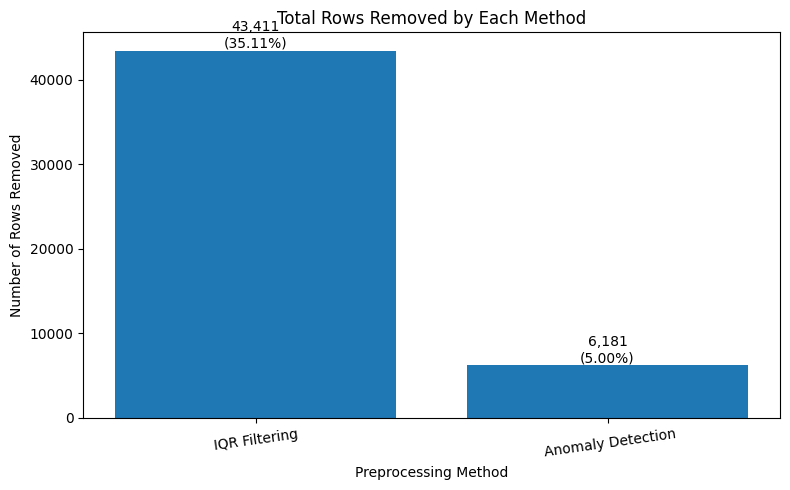

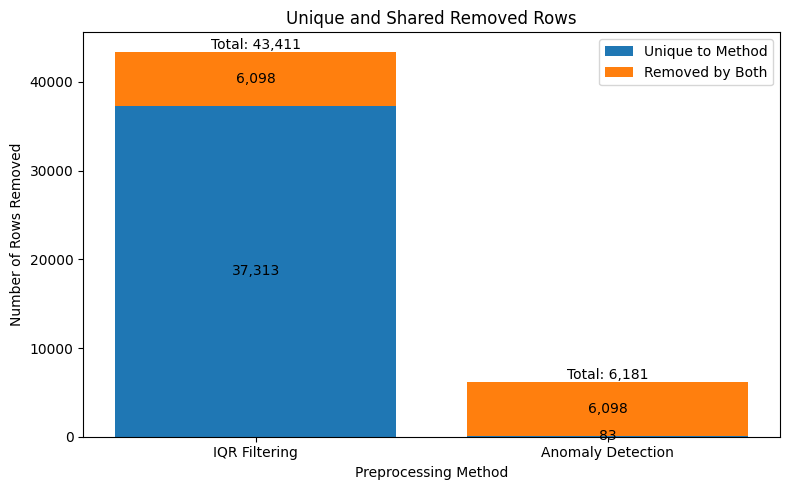

In [211]:


# -----------------------------------------------------------------------------
# 3. TOTAL REMOVED ROWS BY EACH METHOD
# -----------------------------------------------------------------------------
method_total_summary = pd.DataFrame({
    "Method": [
        "IQR Filtering",
        " Anomaly Detection"
    ],
    "Rows_Removed": [
        n_iqr_total,
        n_anomaly_total
    ],
    "Percent_of_Original": [
        n_iqr_total / n_original * 100,
        n_anomaly_total / n_original * 100
    ]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    method_total_summary["Method"],
    method_total_summary["Rows_Removed"]
)

plt.title("Total Rows Removed by Each Method")
plt.xlabel("Preprocessing Method")
plt.ylabel("Number of Rows Removed")
plt.xticks(rotation=8)

for bar, rows, percent in zip(
    bars,
    method_total_summary["Rows_Removed"],
    method_total_summary["Percent_of_Original"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(rows):,}\n({percent:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 4. STACKED BAR: SHARED VS UNIQUE REMOVALS
# -----------------------------------------------------------------------------
stacked_overlap = pd.DataFrame({
    "Method": [
        "IQR Filtering",
        "Anomaly Detection"
    ],
    "Unique_Removals": [
        n_iqr_only,
        n_anomaly_only
    ],
    "Shared_Removals": [
        n_both,
        n_both
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    stacked_overlap["Method"],
    stacked_overlap["Unique_Removals"],
    label="Unique to Method"
)

plt.bar(
    stacked_overlap["Method"],
    stacked_overlap["Shared_Removals"],
    bottom=stacked_overlap["Unique_Removals"],
    label="Removed by Both"
)

plt.title("Unique and Shared Removed Rows")
plt.xlabel("Preprocessing Method")
plt.ylabel("Number of Rows Removed")
plt.legend()

for i, row in stacked_overlap.iterrows():

    unique_value = row["Unique_Removals"]
    shared_value = row["Shared_Removals"]
    total_value = unique_value + shared_value

    if unique_value > 0:
        plt.text(
            i,
            unique_value / 2,
            f"{int(unique_value):,}",
            ha="center",
            va="center"
        )

    if shared_value > 0:
        plt.text(
            i,
            unique_value + shared_value / 2,
            f"{int(shared_value):,}",
            ha="center",
            va="center"
        )

    plt.text(
        i,
        total_value,
        f"Total: {int(total_value):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


    

Predicted Vs Actual 

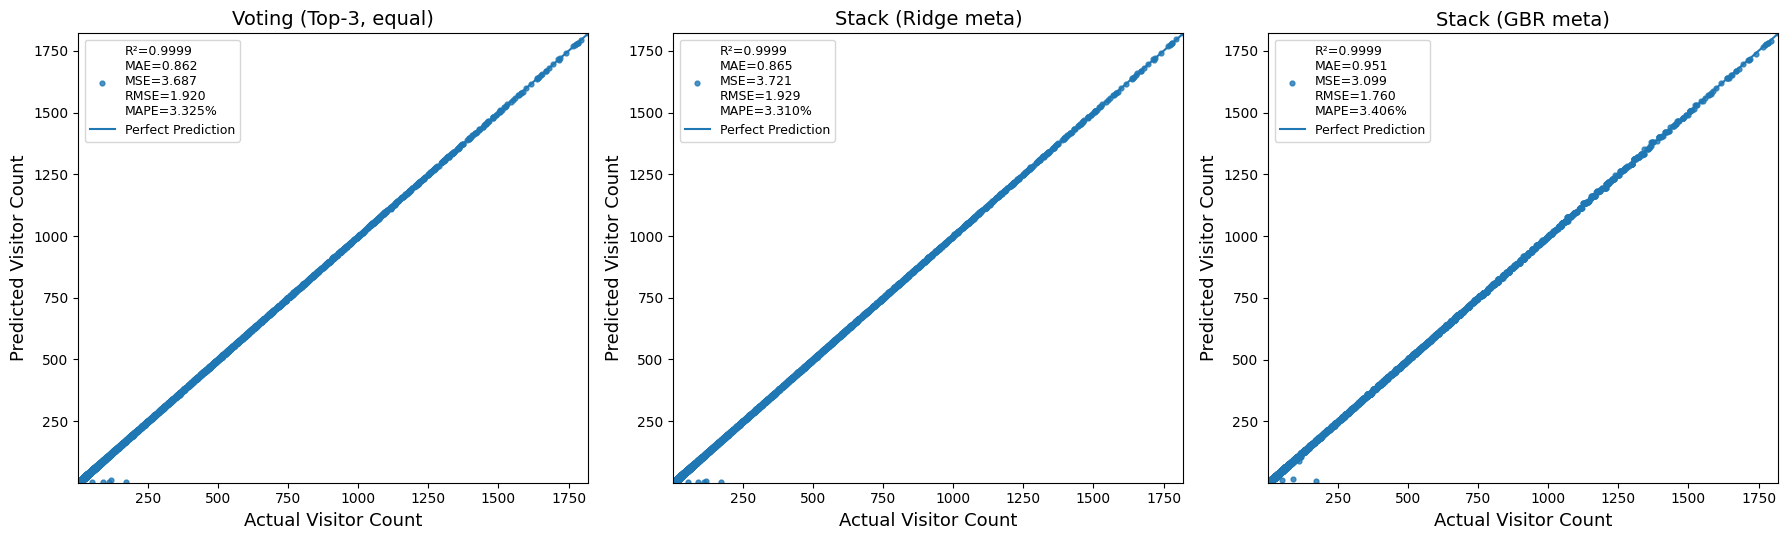

In [212]:
# ---------- 3 HYBRID ACTUAL vs PREDICTED PLOTS ----------
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


hybrid_candidates = [
    ("Voting (Top-3, equal)", pred_vote),
    ("Stack (Ridge meta)", pred_stack_ridge),
    ("Stack (GBR meta)", pred_stack_gbr),
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5)
)


for ax, (title, pred) in zip(
    axes,
    hybrid_candidates
):

    y_actual = np.asarray(
        y_te,
        dtype=float
    )

    y_pred = np.asarray(
        pred,
        dtype=float
    )


    # -------------------------------------------------------------
    # Calculate all regression metrics
    # -------------------------------------------------------------
    r2 = r2_score(
        y_actual,
        y_pred
    )

    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    mse = mean_squared_error(
        y_actual,
        y_pred
    )

    rmse = np.sqrt(
        mse
    )

    mape = np.mean(
        np.abs(
            (y_actual - y_pred)
            / np.clip(
                np.abs(y_actual),
                1e-8,
                None
            )
        )
    ) * 100


    # -------------------------------------------------------------
    # Actual vs predicted scatter plot
    # -------------------------------------------------------------
    ax.scatter(
        y_actual,
        y_pred,
        s=12,
        alpha=0.8,
        label=(
            f"R²={r2:.4f}\n"
            f"MAE={mae:.3f}\n"
            f"MSE={mse:.3f}\n"
            f"RMSE={rmse:.3f}\n"
            f"MAPE={mape:.3f}%"
        )
    )


    # -------------------------------------------------------------
    # Perfect-prediction reference line
    # -------------------------------------------------------------
    mn = min(
        np.nanmin(y_actual),
        np.nanmin(y_pred)
    )

    mx = max(
        np.nanmax(y_actual),
        np.nanmax(y_pred)
    )

    ax.plot(
        [mn, mx],
        [mn, mx],
        linewidth=1.5,
        label="Perfect Prediction"
    )


    # Keep same range on x-axis and y-axis
    ax.set_xlim(
        mn,
        mx
    )

    ax.set_ylim(
        mn,
        mx
    )


    # -------------------------------------------------------------
    # Figure formatting
    # -------------------------------------------------------------
    ax.set_xlabel(
        "Actual Visitor Count",
        fontsize=13
    )

    ax.set_ylabel(
        "Predicted Visitor Count",
        fontsize=13
    )

    ax.set_title(
        title,
        fontsize=14
    )

    ax.legend(
        fontsize=9,
        loc="upper left"
    )

    ax.grid(False)


plt.tight_layout()
plt.show()

Scatter Plot for Anomaly Detection 

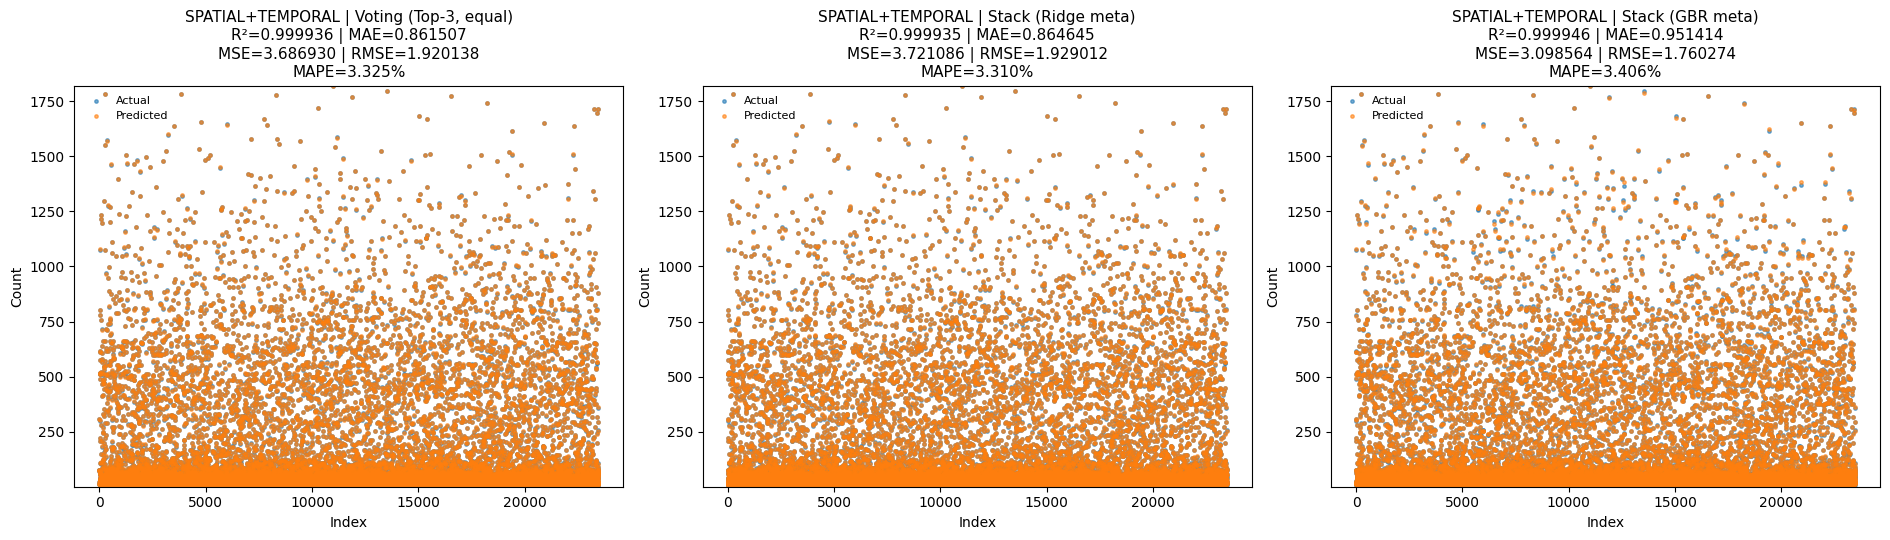


=== BEST 3 ENSEMBLES for SPATIAL+TEMPORAL (MAE asc, tie R² desc) ===
Voting (Top-3, equal)    | pred_vote         | R²=0.999936 | MAE=0.861507 | MSE=3.686930 | RMSE=1.920138 | MAPE=3.325%
Stack (Ridge meta)       | pred_stack_ridge  | R²=0.999935 | MAE=0.864645 | MSE=3.721086 | RMSE=1.929012 | MAPE=3.310%
Stack (GBR meta)         | pred_stack_gbr    | R²=0.999946 | MAE=0.951414 | MSE=3.098564 | RMSE=1.760274 | MAPE=3.406%


In [213]:
# ---------- 3 BEST panels (auto-select by MAE; tie-break by R²) ----------
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Candidate prediction arrays produced above in THIS combo loop
candidates = [
    ("Voting (Top-3, equal)", "pred_vote"),
    ("Stack (Linear meta)",   "pred_stack_lin"),
    ("Stack (Ridge meta)",    "pred_stack_ridge"),
    ("Stack (GBR meta)",      "pred_stack_gbr"),
    ("Hybrid (Top-3 avg)",    "pred_avg"),
]


# ---- gather available predictions from local loop scope ----
available = []

for title, varname in candidates:

    if varname in locals():

        yp = np.asarray(
            locals()[varname],
            dtype=float
        )

        # Sanity check: prediction length must match y_te
        if len(yp) == len(y_te):

            available.append(
                (
                    title,
                    varname,
                    yp
                )
            )


if len(available) == 0:

    print(
        f"[warn] No ensemble predictions found for "
        f"BEST-3 plot in combo={combo_name}."
    )

else:

    # ---------------------------------------------------------------------
    # Downsample indices once for responsiveness
    # ---------------------------------------------------------------------
    n = len(y_te)

    idx_all = np.arange(
        n
    )

    SAMPLE = min(
        50000,
        n
    )

    if SAMPLE < n:

        rng = np.random.RandomState(
            42
        )

        idx = np.sort(
            rng.choice(
                n,
                size=SAMPLE,
                replace=False
            )
        )

    else:

        idx = idx_all


    ya = np.asarray(
        y_te,
        dtype=float
    )[idx]


    # ---------------------------------------------------------------------
    # Score each candidate using the same sampled indices
    # ---------------------------------------------------------------------
    scored = []

    for title, varname, yp_full in available:

        yp = np.asarray(
            yp_full,
            dtype=float
        )[idx]

        # R²
        r2 = r2_score(
            ya,
            yp
        )

        # MAE
        mae = mean_absolute_error(
            ya,
            yp
        )

        # MSE
        mse = mean_squared_error(
            ya,
            yp
        )

        # RMSE
        rmse = np.sqrt(
            mse
        )

        # MAPE
        mape = np.mean(
            np.abs(
                (ya - yp)
                / np.clip(
                    np.abs(ya),
                    1e-8,
                    None
                )
            )
        ) * 100


        scored.append(
            (
                mae,
                -r2,
                title,
                varname,
                yp_full,
                r2,
                mse,
                rmse,
                mape
            )
        )


    # ---------------------------------------------------------------------
    # Sort by MAE ascending, then R² descending
    # ---------------------------------------------------------------------
    scored.sort(
        key=lambda result: (
            result[0],
            result[1]
        )
    )


    # Take best three
    topk = scored[:3]


    # ---------------------------------------------------------------------
    # Global y-axis limits across selected three ensembles
    # ---------------------------------------------------------------------
    y_min = float(
        np.nanmin(ya)
    )

    y_max = float(
        np.nanmax(ya)
    )


    for (
        _mae,
        _negative_r2,
        _title,
        _varname,
        yp_full,
        _r2,
        _mse,
        _rmse,
        _mape
    ) in topk:

        yp = np.asarray(
            yp_full,
            dtype=float
        )[idx]

        y_min = min(
            y_min,
            float(np.nanmin(yp))
        )

        y_max = max(
            y_max,
            float(np.nanmax(yp))
        )


    # ---------------------------------------------------------------------
    # Plot 1 × 3 panels
    # ---------------------------------------------------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(19, 5.5),
        squeeze=False
    )

    axes = axes[0]


    for ax, result in zip(
        axes,
        topk
    ):

        (
            mae,
            _negative_r2,
            title,
            varname,
            yp_full,
            r2,
            mse,
            rmse,
            mape
        ) = result


        yp = np.asarray(
            yp_full,
            dtype=float
        )[idx]


        ax.scatter(
            idx,
            ya,
            s=6,
            alpha=0.6,
            label="Actual"
        )

        ax.scatter(
            idx,
            yp,
            s=6,
            alpha=0.6,
            label="Predicted"
        )


        ax.set_ylim(
            y_min,
            y_max
        )


        # All regression metrics shown in title
        ax.set_title(
            f"{combo_name} | {title}\n"
            f"R²={r2:.6f} | MAE={mae:.6f}\n"
            f"MSE={mse:.6f} | RMSE={rmse:.6f}\n"
            f"MAPE={mape:.3f}%",
            fontsize=11
        )


        ax.set_xlabel(
            "Index"
        )

        ax.set_ylabel(
            "Count"
        )

        ax.legend(
            loc="best",
            fontsize=8,
            frameon=False
        )


    plt.tight_layout()
    plt.show()


    # ---------------------------------------------------------------------
    # Print selected best three with all regression metrics
    # ---------------------------------------------------------------------
    print(
        f"\n=== BEST 3 ENSEMBLES for {combo_name} "
        f"(MAE asc, tie R² desc) ==="
    )


    for result in topk:

        (
            mae,
            _negative_r2,
            title,
            varname,
            _yp_full,
            r2,
            mse,
            rmse,
            mape
        ) = result


        print(
            f"{title:24s} | "
            f"{varname:17s} | "
            f"R²={r2:.6f} | "
            f"MAE={mae:.6f} | "
            f"MSE={mse:.6f} | "
            f"RMSE={rmse:.6f} | "
            f"MAPE={mape:.3f}%"
        )

Scatter Plot different size

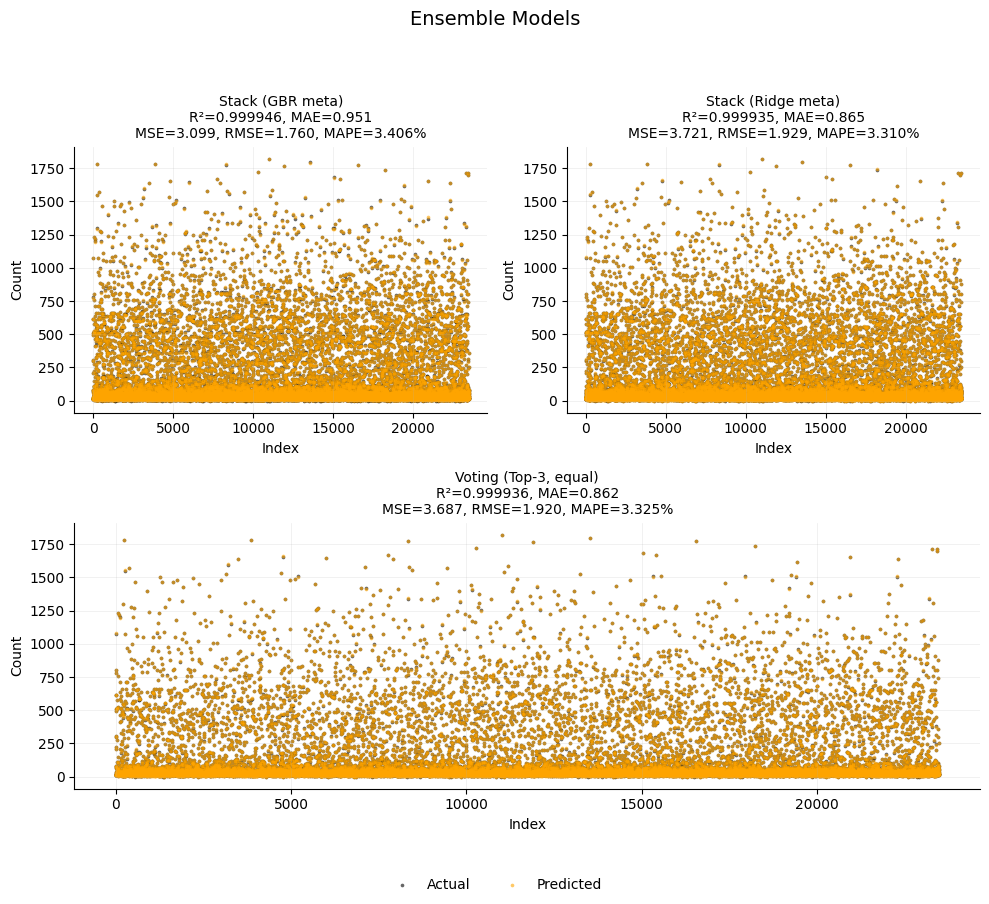

In [214]:
# ---------- Ensemble Models: 2 top + 1 wide bottom ----------
# All metrics included: R², MAE, MSE, RMSE, and MAPE

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


plots = [
    ("Stack (GBR meta)", pred_stack_gbr),
    ("Stack (Ridge meta)", pred_stack_ridge),
    ("Voting (Top-3, equal)", pred_vote),
]


fig = plt.figure(figsize=(10, 9))
gs = fig.add_gridspec(2, 2)


axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, :]),
]


for ax, (title, pred) in zip(axes, plots):

    y_actual = np.asarray(
        y_te,
        dtype=float
    )

    y_pred = np.asarray(
        pred,
        dtype=float
    )


    # -------------------------------------------------------------
    # Check prediction length
    # -------------------------------------------------------------
    if len(y_actual) != len(y_pred):
        raise ValueError(
            f"Length mismatch for {title}: "
            f"actual={len(y_actual)}, predicted={len(y_pred)}"
        )


    n = len(y_actual)
    idx = np.arange(n)


    # -------------------------------------------------------------
    # Calculate all regression metrics
    # -------------------------------------------------------------
    r2 = r2_score(
        y_actual,
        y_pred
    )

    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    mse = mean_squared_error(
        y_actual,
        y_pred
    )

    rmse = np.sqrt(
        mse
    )

    # MAPE with protection against zero actual values
    mape = np.mean(
        np.abs(
            (y_actual - y_pred)
            / np.clip(
                np.abs(y_actual),
                1e-8,
                None
            )
        )
    ) * 100


    # -------------------------------------------------------------
    # Plot actual and predicted values
    # -------------------------------------------------------------
    ax.scatter(
        idx,
        y_actual,
        s=7,
        alpha=0.6,
        c="black",
        linewidths=0,
        label="Actual"
    )

    ax.scatter(
        idx,
        y_pred,
        s=7,
        alpha=0.6,
        c="orange",
        linewidths=0,
        label="Predicted"
    )


    # -------------------------------------------------------------
    # Add all metrics to each panel title
    # -------------------------------------------------------------
    ax.set_title(
        f"{title}\n"
        f"R²={r2:.6f}, MAE={mae:.3f}\n"
        f"MSE={mse:.3f}, RMSE={rmse:.3f}, "
        f"MAPE={mape:.3f}%",
        fontsize=10
    )


    ax.set_ylabel(
        "Count"
    )

    ax.grid(
        True,
        linewidth=0.5,
        alpha=0.25
    )

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )


# Add x-axis labels
axes[0].set_xlabel("Index")
axes[1].set_xlabel("Index")
axes[2].set_xlabel("Index")


# Shared legend
handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False
)


fig.suptitle(
    "Ensemble Models",
    fontsize=14,
    y=0.99
)


fig.tight_layout(
    rect=[0, 0.06, 1, 0.95]
)

plt.show()

Combine diagram for Hybrid Models 

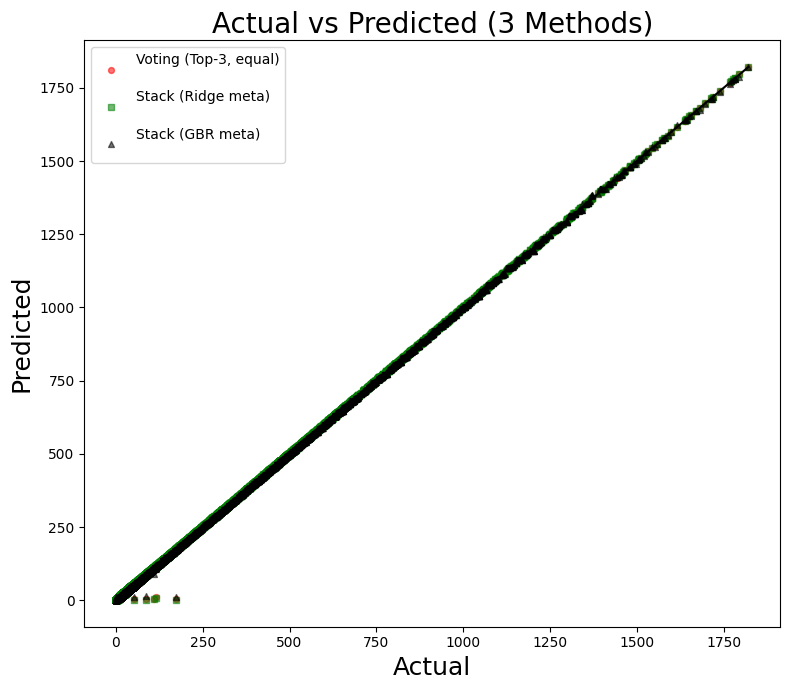

In [215]:
# ---------- Actual vs Predicted: 3 methods in one plot ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_actual = np.asarray(y_te).astype(float)

methods = [
    ("Voting (Top-3, equal)", pred_vote, "o", "red"),
    ("Stack (Ridge meta)", pred_stack_ridge, "s", "green"),
    ("Stack (GBR meta)", pred_stack_gbr, "^", "black"),
]

plt.figure(figsize=(8, 7))

for name, pred, marker, color in methods:

    y_pred = np.asarray(pred).astype(float)

    r2 = r2_score(y_actual, y_pred)
    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_actual - y_pred) /
            np.clip(np.abs(y_actual), 1e-8, None)
        )
    ) * 100

    plt.scatter(
        y_actual,
        y_pred,
        s=18,
        alpha=0.55,
        marker=marker,
        color=color,
        label=(
            f"{name}\n"
          #  f"R²={r2:.4f}, MAE={mae:.3f}, "
           # f"MSE={mse:.3f}, RMSE={rmse:.3f}, "
           # f"MAPE={mape:.3f}%"
        )
    )

mn = min(
    y_actual.min(),
    np.asarray(pred_vote).min(),
    np.asarray(pred_stack_ridge).min(),
    np.asarray(pred_stack_gbr).min()
)

mx = max(
    y_actual.max(),
    np.asarray(pred_vote).max(),
    np.asarray(pred_stack_ridge).max(),
    np.asarray(pred_stack_gbr).max()
)

plt.plot(
    [mn, mx],
    [mn, mx],
    color="black",
    linewidth=1.5
)

plt.xlabel("Actual", fontsize=18)
plt.ylabel("Predicted", fontsize=18)
plt.title("Actual vs Predicted (3 Methods)", fontsize=20)

plt.legend(fontsize=10, loc="upper left")
plt.grid(False)
plt.tight_layout()
plt.show()

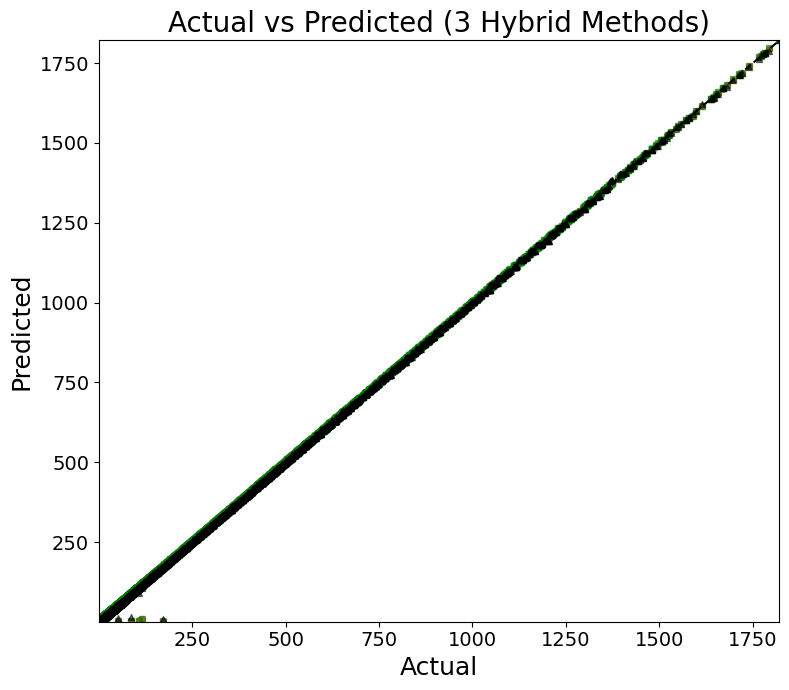

In [216]:
# ---------- Actual vs Predicted: 3 methods in one plot ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_actual = np.asarray(y_te, dtype=float).ravel()

methods = [
    ("Voting (Top-3, equal)", pred_vote, "o", "red"),
    ("Stack (Ridge meta)", pred_stack_ridge, "s", "green"),
    ("Stack (GBR meta)", pred_stack_gbr, "^", "black"),
]

plt.figure(figsize=(8, 7))

all_values = [y_actual]

for name, pred, marker, color in methods:

    y_pred = np.asarray(pred, dtype=float).ravel()

    if len(y_pred) != len(y_actual):
        raise ValueError(
            f"{name}: prediction length ({len(y_pred)}) does not match "
            f"actual length ({len(y_actual)})."
        )

    # Metrics (computed but not displayed)
    r2 = r2_score(y_actual, y_pred)
    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)

    nonzero_mask = np.abs(y_actual) > 1e-8
    mape = np.mean(
        np.abs(
            (y_actual[nonzero_mask] - y_pred[nonzero_mask]) /
            np.abs(y_actual[nonzero_mask])
        )
    ) * 100

    plt.scatter(
        y_actual,
        y_pred,
        s=18,
        alpha=0.55,
        marker=marker,
        color=color
    )

    all_values.append(y_pred)

# Common limits
mn = min(values.min() for values in all_values)
mx = max(values.max() for values in all_values)

# Perfect prediction line
plt.plot(
    [mn, mx],
    [mn, mx],
    color="black",
    linestyle="--",
    linewidth=1.5
)

plt.xlim(mn, mx)
plt.ylim(mn, mx)

plt.xlabel("Actual", fontsize=18)
plt.ylabel("Predicted", fontsize=18)
plt.title("Actual vs Predicted (3 Hybrid Methods)", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(False)
plt.tight_layout()
plt.show()

1. **Feature Engineering:** Convert the input date into temporal features (e.g., day, week, month, season, weekend) and combine them with the selected predictor variables.

2. **Hybrid Model Training:** Select and train the best-performing hybrid model using the chosen feature combination.

3. **POI–Date Matching:** Match the selected POI with records from the same calendar date (month–day) across available years and prepare the prediction input.

4. **Prediction & Uncertainty:** Predict visitation using the trained hybrid model and estimate uncertainty from the standard deviation of the base-model predictions plus Uncertainty
5. In term of perticular date and POI prediction 

 OUTPUT: Predicted Visits = 90 ± 4
 for given date and POI


Formula 1: Historical Robust Standard Deviation
"Historical Robust SD"=1.4826×"MAD"

where
"MAD"="Median" (∣x_i-"Median" ∣)

 
Formula 2: Historical Standard Error
"Historical SE"="Historical Robust SD" /√n

where:
    n= number of historical observations. 
 
Formula 3: Predicted Visits
"Predicted Visits"="Hybrid Model Prediction"±"Historical SE"

 
Example
Historical visits for the same lake and date:
Year	Visits
2022	115
2023	118
2024	122
Step 1: Median
"Median"=118

Step 2: MAD
∣115-118∣=3
∣118-118∣=0
∣122-118∣=4
"MAD"="Median" (3,0,4)=3

Step 3: Historical Robust SD
"Historical Robust SD"=1.4826×3=4.45

Step 4: Historical Standard Error
Number of historical observations:
n=3
"Historical SE"=4.45/√3=4.45/1.732=2.57

The code rounds the uncertainty to the nearest integer:
"Prediction Uncertainty"="round" (2.57)=3

Step 5: Final Prediction
Suppose the hybrid model predicts 120 visits.
"Predicted Visits"=120±3

Prediction range:
120-3=117
120+3=123



In [217]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    VotingRegressor,
    StackingRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import Ridge


df_use = df_after if "df_after" in globals() else df


def predict_selected_poi_date(poi_value, input_date):

    df_use2 = df_use.copy()

    # -------------------- Add extra temporal features --------------------
    # Keep original date values before conversion
    raw_date = df_use2["date"].copy()

    # Clean values such as 20230715.0
    clean_date = (
        raw_date
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

    # First try YYYYMMDD format
    parsed_date = pd.to_datetime(
        clean_date,
        format="%Y%m%d",
        errors="coerce"
    )

    # Try general date parsing for remaining values
    bad = parsed_date.isna()

    parsed_date.loc[bad] = pd.to_datetime(
        clean_date.loc[bad],
        errors="coerce"
    )

    df_use2["date"] = parsed_date

    print("\nDate parsing:")
    print("Total rows   :", len(df_use2))
    print("Valid dates  :", df_use2["date"].notna().sum())
    print("Invalid dates:", df_use2["date"].isna().sum())

    df_use2["dow"] = df_use2["date"].dt.dayofweek
    df_use2["is_weekend"] = (df_use2["dow"] >= 5).astype(int)

    df_use2["week"] = (
        df_use2["date"]
        .dt.isocalendar()
        .week
        .astype("Int64")
    )

    df_use2["month"] = df_use2["date"].dt.month
    df_use2["day"] = df_use2["date"].dt.day

    df_use2["season"] = df_use2["month"].apply(
        lambda m:
        0 if m in [12, 1, 2] else
        1 if m in [3, 4, 5] else
        2 if m in [6, 7, 8] else
        3 if pd.notna(m) else np.nan
    )

    df_use2["date_ordinal"] = df_use2["date"].map(
        lambda x: x.toordinal()
        if pd.notna(x)
        else np.nan
    )

    df_use2["is_month_start"] = (
        df_use2["date"]
        .dt.is_month_start
        .astype(int)
    )

    df_use2["is_month_end"] = (
        df_use2["date"]
        .dt.is_month_end
        .astype(int)
    )

    df_use2["is_quarter_start"] = (
        df_use2["date"]
        .dt.is_quarter_start
        .astype(int)
    )

    df_use2["is_quarter_end"] = (
        df_use2["date"]
        .dt.is_quarter_end
        .astype(int)
    )

    if "poi_id" in df_use2.columns:

        df_use2["poi_id_code"] = (
            df_use2["poi_id"]
            .astype("category")
            .cat.codes
        )

    # -------------------- Best VOTE Hybrid --------------------
    # VOTE produced the best test MAE/R² in the hybrid comparison,
    # so restrict selection to VOTE rows instead of selecting the
    # overall highest Score_H row (which previously selected STACK_GBR).

   

    best_h  = (
        df_h
        .sort_values("Score_H", ascending=False).iloc[0]
     
    )

    combo_name = best_h["Combo"]
    hybrid_nm =  best_h["Hybrid"]

    print("\nSelected hybrid model:")
    print("Hybrid      :", hybrid_nm)
    print("Feature Combo:", combo_name)
    print("Score_H     :", best_h["Score_H"])

    feats = (
        BASE_COMBOS_AFTER[combo_name]
        if "BASE_COMBOS_AFTER" in globals()
        else BASE_COMBOS[combo_name]
    )

    extra_feats = [
        "is_weekend",
        "season",
        "month",
        "week",
        "dow",
        "day",
        "date_ordinal",
        "is_month_start",
        "is_month_end",
        "is_quarter_start",
        "is_quarter_end",
        "poi_id_code"
    ]

    feats = list(
        dict.fromkeys(
            list(feats) + extra_feats
        )
    )

    feats = [
        f for f in feats
        if f in df_use2.columns
    ]

    # -------------------- Build X, y, aligned df --------------------
    X, y = build_Xy(
        df_use2,
        feats
    )

    mask = (
        df_use2[feats]
        .notna()
        .all(axis=1)
    )

    df_aligned = (
        df_use2.loc[mask]
        .reset_index(drop=True)
    )

    n = min(
        len(X),
        len(y),
        len(df_aligned)
    )

    print("\nRows after feature preparation:")
    print("Rows returned by build_Xy:", len(X))
    print("Target rows              :", len(y))
    print("Aligned dataframe rows   :", len(df_aligned))
    print("Final usable rows        :", n)

    if n == 0:

        print("\nNo valid rows remain after feature filtering.")

        print("\nFeatures with the most missing values:")

        missing_summary = (
            df_use2[feats]
            .isna()
            .sum()
            .sort_values(ascending=False)
        )

        print(
            missing_summary
            .head(30)
            .to_string()
        )

        print("\nFeatures used:")
        print(feats)

        return None

    X = X[:n]

    y = (
        np.asarray(y)
        .reshape(-1)[:n]
    )

    df_aligned = (
        df_aligned
        .iloc[:n]
        .reset_index(drop=True)
    )

    # Store actual historical target values
    df_aligned["_historical_visits"] = y

    if n < 2:

        print(
            "\nNot enough valid rows for train/test splitting. "
            f"Valid rows: {n}"
        )

        return None

    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    print("\nFeatures used:")
    print(feats)
    print("Total features:", len(feats))

    print(
        "Extra features present:",
        [
            f for f in extra_feats
            if f in feats
        ]
    )

    # -------------------- Columns --------------------
    poi_id_col = "poi_id"

    poi_name_col = (
        "poi"
        if "poi" in df_aligned.columns
        else poi_id_col
    )

    date_col = "date"

    # -------------------- Base Models --------------------
    base_names = [
        s.strip()
        for s in str(best_h["Bases"]).split(",")
        if s.strip()
    ]

    bases = []

    for name in base_names:

        for mname, mdl in MODELS:

            if mname == name:

                bases.append(
                    (
                        name,
                        clone(mdl)
                    )
                )

                break

    if len(bases) == 0:

        print("No base models found.")
        print("Requested base models:", base_names)

        return None

    # -------------------- Hybrid Model --------------------
    if hybrid_nm == "VOTE":

        model = VotingRegressor(
            estimators=bases
        )

    elif hybrid_nm == "STACK_Ridge":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=Ridge(
                alpha=1.0
            ),
            cv=2,
            passthrough=False
        )

    elif hybrid_nm == "STACK_GBR":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                n_estimators=50,
                learning_rate=0.05,
                max_depth=2
            ),
            cv=2,
            passthrough=False
        )

    else:

        print(
            f"Unknown hybrid model: {hybrid_nm}"
        )

        return None

    model.fit(
        X_tr,
        y_tr
    )

    # -------------------- POI Matching --------------------
    df_temp = df_aligned.copy()

    df_temp["_poi_num"] = pd.to_numeric(
        df_temp[poi_id_col],
        errors="coerce"
    )

    poi_num = pd.to_numeric(
        poi_value,
        errors="coerce"
    )

    if pd.notna(poi_num):

        poi_mask = (
            df_temp["_poi_num"]
            == float(poi_num)
        )

    else:

        poi_mask = (
            df_temp[poi_name_col]
            .astype(str)
            .str.lower()
            .str.contains(
                str(poi_value).lower(),
                na=False
            )
        )

    if poi_mask.sum() == 0:

        print("POI/Lake not found.")

        print("\nAvailable POI examples:")

        print(
            df_temp[
                [
                    poi_id_col,
                    poi_name_col
                ]
            ]
            .drop_duplicates()
            .head(20)
            .to_string(index=False)
        )

        return None

    # -------------------- Date Matching --------------------
    df_temp["_date_parsed"] = pd.to_datetime(
        df_temp[date_col],
        errors="coerce"
    )

    bad_date_mask = (
        df_temp["_date_parsed"]
        .isna()
    )

    df_temp.loc[
        bad_date_mask,
        "_date_parsed"
    ] = pd.to_datetime(
        df_temp.loc[
            bad_date_mask,
            date_col
        ]
        .astype(str)
        .str.replace(
            r"\.0$",
            "",
            regex=True
        ),
        format="%Y%m%d",
        errors="coerce"
    )

    df_temp["_month_day"] = (
        df_temp["_date_parsed"]
        .dt.strftime("%m-%d")
    )

    try:

        input_date_string = (
            str(input_date)
            .strip()
        )

        if "-" in input_date_string:

            dt = pd.to_datetime(
                "2024-" + input_date_string,
                format="%Y-%m-%d",
                errors="raise"
            )

        else:

            dt = pd.to_datetime(
                input_date_string + " 2024",
                errors="raise"
            )

        target_md = dt.strftime(
            "%m-%d"
        )

    except Exception:

        print(
            "Invalid date. Use 07-04 or July 4."
        )

        return None

    matched = df_temp.loc[
        poi_mask
        & (
            df_temp["_month_day"]
            == target_md
        )
    ].copy()

    if matched.empty:

        print(
            "No matching POI and date found."
        )

        print(
            "\nAvailable dates for this POI:"
        )

        available = (
            df_temp.loc[
                poi_mask,
                [
                    date_col,
                    "_month_day"
                ]
            ]
            .dropna()
            .drop_duplicates()
            .sort_values(date_col)
        )

        print(
            available.to_string(
                index=False
            )
        )

        return None

    # -------------------- Historical Same-Date Data --------------------
    historical = (
        matched[
            [
                "_date_parsed",
                "_historical_visits"
            ]
        ]
        .dropna()
        .sort_values("_date_parsed")
        .copy()
    )

    historical["Year"] = (
        historical["_date_parsed"]
        .dt.year
    )

    historical["Date"] = (
        historical["_date_parsed"]
        .dt.strftime("%Y-%m-%d")
    )

    historical = historical.rename(
        columns={
            "_historical_visits":
            "Actual_Visits"
        }
    )

    historical = (
        historical[
            [
                "Year",
                "Date",
                "Actual_Visits"
            ]
        ]
        .reset_index(drop=True)
    )

    historical_mean = float(
        historical["Actual_Visits"]
        .mean()
    )

    historical_min = float(
        historical["Actual_Visits"]
        .min()
    )

    historical_max = float(
        historical["Actual_Visits"]
        .max()
    )

    historical_std = float(
        historical["Actual_Visits"]
        .std(ddof=0)
    )

    # If multiple years have the same month-day,
    # average the feature rows
    row = (
        matched[feats]
        .mean(numeric_only=True)
        .to_frame()
        .T
    )

    # -------------------- Overwrite requested-date features --------------------
    update_vals = {
        "dow": dt.dayofweek,
        "is_weekend": int(
            dt.dayofweek >= 5
        ),
        "week": int(
            dt.isocalendar().week
        ),
        "month": dt.month,
        "day": dt.day,

        "season": (
            0 if dt.month in [12, 1, 2] else
            1 if dt.month in [3, 4, 5] else
            2 if dt.month in [6, 7, 8] else
            3
        ),

        "date_ordinal": dt.toordinal(),
        "is_month_start": int(
            dt.is_month_start
        ),
        "is_month_end": int(
            dt.is_month_end
        ),
        "is_quarter_start": int(
            dt.is_quarter_start
        ),
        "is_quarter_end": int(
            dt.is_quarter_end
        )
    }

    for c, v in update_vals.items():

        if c in row.columns:
            row[c] = v

    # Ensure all features are available in prediction row
    missing_prediction_features = [
        f for f in feats
        if f not in row.columns
    ]

    if missing_prediction_features:

        print(
            "\nMissing prediction features:"
        )

        print(
            missing_prediction_features
        )

        return None

    if row[feats].isna().any().any():

        print(
            "\nPrediction row contains missing values:"
        )

        print(
            row[feats]
            .isna()
            .sum()
            .loc[
                lambda s: s > 0
            ]
        )

        return None

    # -------------------- Predict --------------------
    X_new = row[feats]

    pred_raw = float(
        model.predict(
            X_new
        )[0]
    )

    # -------------------- Historical Lake-and-Date Uncertainty --------------------
    # Historical values for this lake and the same calendar date
    hist_values = (
        historical["Actual_Visits"]
        .dropna()
        .to_numpy(dtype=float)
    )

    n_hist = len(hist_values)

    if n_hist >= 2:

        # Robust historical variability using median absolute deviation (MAD)
        hist_median = float(np.median(hist_values))

        hist_mad = float(
            np.median(
                np.abs(hist_values - hist_median)
            )
        )

        # Convert MAD to a robust standard-deviation estimate
        robust_hist_sd = 1.4826 * hist_mad

        # Historical standard error for this lake and calendar date
        historical_se = robust_hist_sd / np.sqrt(n_hist)

    else:

        robust_hist_sd = 0.0
        historical_se = 0.0

    # Use only historical uncertainty; no individual base-model predictions
    pm = historical_se

    pred = int(
        round(
            max(
                0,
                pred_raw
            )
        )
    )

    # Display uncertainty and range as integers
    pm = max(1, int(round(pm)))

    lower = max(0, pred - pm)
    upper = pred + pm

    lake_id = (
        matched
        .iloc[0][poi_id_col]
    )

    lake_name = (
        matched
        .iloc[0][poi_name_col]
    )

    # -------------------- Print Prediction --------------------
    print("\n==============================")
    print("Prediction")
    print("==============================")
    print(f"Lake ID          : {lake_id}")
    print(f"Lake Name        : {lake_name}")
    print(f"Date             : {input_date}")
    print(f"Matched Date     : {target_md}")
    print(f"Rows Used        : {len(matched)}")
    print(f"Hybrid Model     : {hybrid_nm}")
    print(f"Feature Combo        : {combo_name}")
    print(f"Historical Robust SD : {robust_hist_sd:.2f}")
    print(f"Historical SE        : {historical_se:.2f}")
    print(f"Predicted Visits     : {pred} ± {pm}")
    print(f"Prediction Range     : ({lower} - {upper})")

    # -------------------- Print Historical Data --------------------
    print("\n==============================")
    print("Historical Same-Date Data")
    print("==============================")

    historical_display = historical.copy()

    historical_display["Actual_Visits"] = (
        historical_display["Actual_Visits"]
        .round(2)
    )

    print(
        historical_display.to_string(
            index=False
        )
    )

    print(
        f"\nHistorical Average : "
        f"{historical_mean:.2f}"
    )

    print(
        f"Historical Minimum : "
        f"{historical_min:.2f}"
    )

    print(
        f"Historical Maximum : "
        f"{historical_max:.2f}"
    )

    print(
        f"Historical Std Dev : "
        f"{historical_std:.2f}"
    )

    

In [218]:
# -------------------- example --------------------
predict_selected_poi_date(6080, "01-03")
predict_selected_poi_date(6080, "01-04")
predict_selected_poi_date(6080, "01-05")
predict_selected_poi_date(6080, "02-03")
predict_selected_poi_date(6080, "02-15")




Date parsing:
Total rows   : 80216
Valid dates  : 80216
Invalid dates: 0

Selected hybrid model:
Hybrid      : STACK_GBR
Feature Combo: SPATIAL+TEMPORAL
Score_H     : 0.6

Rows after feature preparation:
Rows returned by build_Xy: 80128
Target rows              : 80128
Aligned dataframe rows   : 80128
Final usable rows        : 80128

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14946e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14724e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/skle


Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 01-03
Matched Date     : 01-03
Rows Used        : 6
Hybrid Model     : STACK_GBR
Feature Combo        : SPATIAL+TEMPORAL
Historical Robust SD : 18.53
Historical SE        : 7.57
Predicted Visits     : 38 ± 8
Prediction Range     : (30 - 46)

Historical Same-Date Data
 Year       Date  Actual_Visits
 2022 2022-01-03           12.0
 2022 2022-01-03           17.0
 2022 2022-01-03           33.0
 2022 2022-01-03           21.0
 2022 2022-01-03           44.0
 2024 2024-01-03          108.0

Historical Average : 39.17
Historical Minimum : 12.00
Historical Maximum : 108.00
Historical Std Dev : 32.55

Date parsing:
Total rows   : 80216
Valid dates  : 80216
Invalid dates: 0

Selected hybrid model:
Hybrid      : STACK_GBR
Feature Combo: SPATIAL+TEMPORAL
Score_H     : 0.6

Rows after feature preparation:
Rows returned by build_Xy: 80128
Target rows              : 80128
Aligned dataframe rows

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14946e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14724e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/skle


Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 01-04
Matched Date     : 01-04
Rows Used        : 2
Hybrid Model     : STACK_GBR
Feature Combo        : SPATIAL+TEMPORAL
Historical Robust SD : 57.82
Historical SE        : 40.89
Predicted Visits     : 66 ± 41
Prediction Range     : (25 - 107)

Historical Same-Date Data
 Year       Date  Actual_Visits
 2022 2022-01-04           30.0
 2024 2024-01-04          108.0

Historical Average : 69.00
Historical Minimum : 30.00
Historical Maximum : 108.00
Historical Std Dev : 39.00

Date parsing:
Total rows   : 80216
Valid dates  : 80216
Invalid dates: 0

Selected hybrid model:
Hybrid      : STACK_GBR
Feature Combo: SPATIAL+TEMPORAL
Score_H     : 0.6

Rows after feature preparation:
Rows returned by build_Xy: 80128
Target rows              : 80128
Aligned dataframe rows   : 80128
Final usable rows        : 80128

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income

...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14946e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14724e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/skle


Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 02-03
Matched Date     : 02-03
Rows Used        : 2
Hybrid Model     : STACK_GBR
Feature Combo        : SPATIAL+TEMPORAL
Historical Robust SD : 12.60
Historical SE        : 8.91
Predicted Visits     : 13 ± 9
Prediction Range     : (4 - 22)

Historical Same-Date Data
 Year       Date  Actual_Visits
 2022 2022-02-03           18.0
 2023 2023-02-03            1.0

Historical Average : 9.50
Historical Minimum : 1.00
Historical Maximum : 18.00
Historical Std Dev : 8.50

Date parsing:
Total rows   : 80216
Valid dates  : 80216
Invalid dates: 0

Selected hybrid model:
Hybrid      : STACK_GBR
Feature Combo: SPATIAL+TEMPORAL
Score_H     : 0.6

Rows after feature preparation:
Rows returned by build_Xy: 80128
Target rows              : 80128
Aligned dataframe rows   : 80128
Final usable rows        : 80128

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25',

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14946e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14724e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 02-15
Matched Date     : 02-15
Rows Used        : 1
Hybrid Model     : STACK_GBR
Feature Combo        : SPATIAL+TEMPORAL
Historical Robust SD : 0.00
Historical SE        : 0.00
Predicted Visits     : 12 ± 1
Prediction Range     : (11 - 13)

Historical Same-Date Data
 Year       Date  Actual_Visits
 2022 2022-02-15           10.0

Historical Average : 10.00
Historical Minimum : 10.00
Historical Maximum : 10.00
Historical Std Dev : 0.00


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but BayesianRidge was fitted without feature names
  warnings.warn(


5 metrics visulization  for Anomaly detection 

/var/folders/1d/g4zmv0kx6v910p8sldg41zfr0000gr/T/ipykernel_46945/2400728361.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])


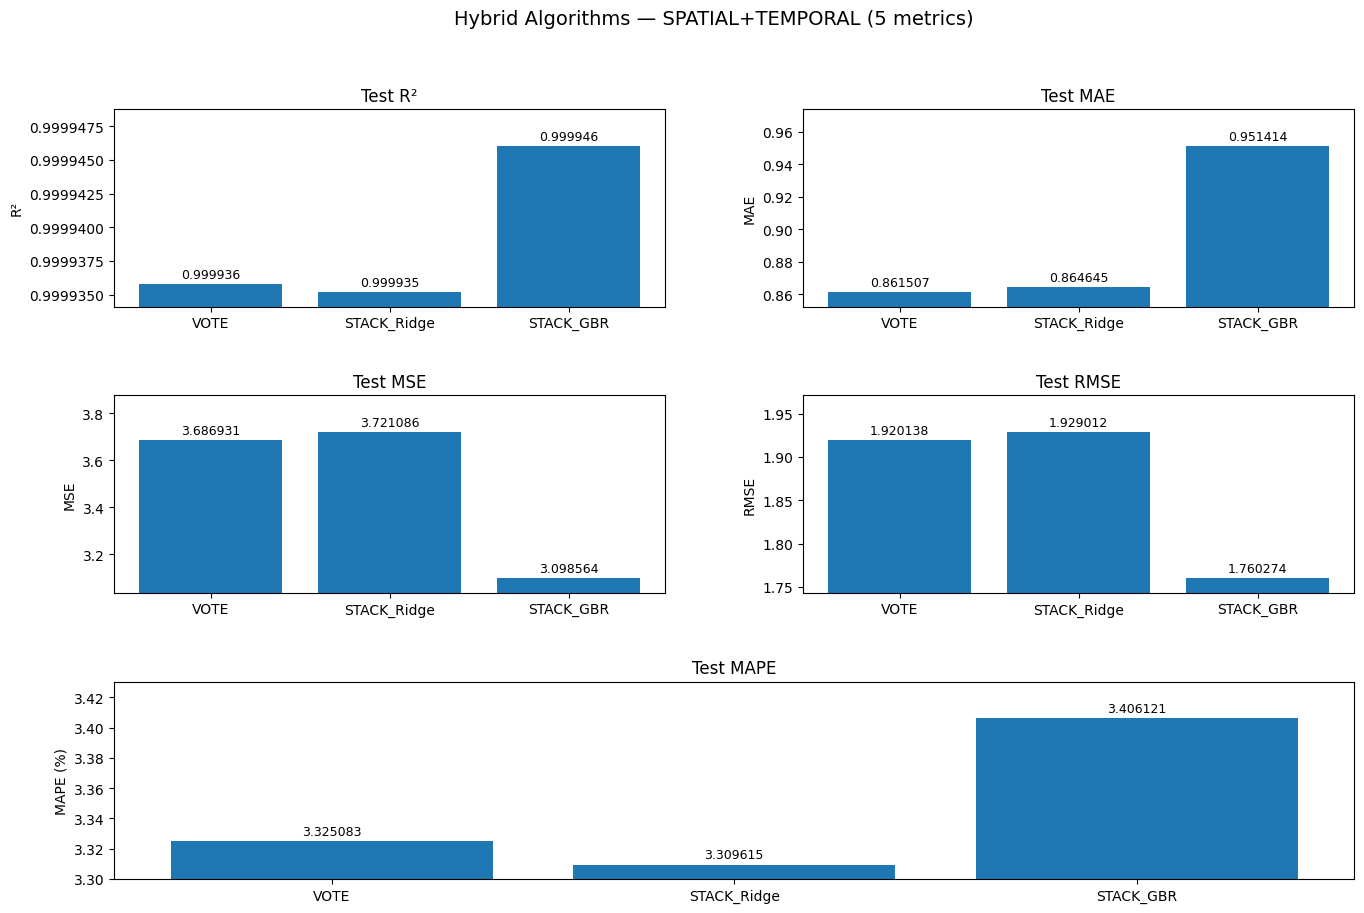

In [219]:
import numpy as np
import matplotlib.pyplot as plt

HYBRID_ORDER = ["VOTE", "STACK_Ridge", "STACK_GBR"]

def _prep_hybrid_values(df_h, metric, order=HYBRID_ORDER):
    # returns (labels, vals) in fixed order
    if df_h is None or len(df_h) == 0 or metric not in df_h.columns:
        return None, None

    d = df_h[["Hybrid", metric]].dropna(subset=["Hybrid", metric]).copy()
    if len(d) == 0:
        return None, None

    # one value per hybrid: take BEST by Score_H if available, else mean
    if "Score_H" in df_h.columns:
        d = (df_h[["Hybrid", metric, "Score_H"]]
             .dropna(subset=["Hybrid", metric])
             .sort_values(["Hybrid", "Score_H"], ascending=[True, False])
             .drop_duplicates("Hybrid", keep="first")[["Hybrid", metric]])
    else:
        d = d.groupby("Hybrid", as_index=False)[metric].mean()

    present = [h for h in order if h in set(d["Hybrid"].tolist())]
    if len(present) == 0:
        return None, None

    d = d.set_index("Hybrid").reindex(present).reset_index()
    labels = d["Hybrid"].tolist()
    vals = d[metric].to_numpy(dtype=float)
    return labels, vals

def plot_5_hybrid_metrics_2_2_1(
    df_h,
    metrics=("Test_R2", "Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"),  # 5 blocks
    titles=None,
    ylabels=None,
    fmt="{:.6f}",
    suptitle="Hybrid Algorithms — SPATIAL+TEMPORAL (5 metrics)"
):
    if titles is None:
        titles = {
            "Test_R2": "Test R²",
            "Test_MAE": "Test MAE",
            "Test_MSE": "Test MSE",
            "Test_RMSE": "Test RMSE",
            "Test_MAPE": "Test MAPE",
        }
    if ylabels is None:
        ylabels = {
            "Test_R2": "R²",
            "Test_MAE": "MAE",
            "Test_MSE": "MSE",
            "Test_RMSE": "RMSE",
            "Test_MAPE": "MAPE (%)",
        }

    # Layout: row1=2, row2=2, row3=1 centered (spans both columns)
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1], hspace=0.45, wspace=0.25)

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[2, :]),  # last row spans both columns -> centered
    ]

    for ax, metric in zip(axes, metrics):
        labels, vals = _prep_hybrid_values(df_h, metric)

        if labels is None:
            ax.set_title(f"{titles.get(metric, metric)} (no data)")
            ax.axis("off")
            continue

        x = np.arange(len(labels))
        bars = ax.bar(x, vals)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=0)
        ax.set_title(titles.get(metric, metric))
        ax.set_ylabel(ylabels.get(metric, metric))

        # no scientific offset text
        ax.ticklabel_format(style="plain", axis="y", useOffset=False)
        ax.yaxis.get_major_formatter().set_scientific(False)
        ax.yaxis.get_major_formatter().set_useOffset(False)

        # y-limits with headroom
        y_min, y_max = float(np.min(vals)), float(np.max(vals))
        rng = (y_max - y_min) if (y_max != y_min) else (abs(y_max) if y_max != 0 else 1.0)
        ax.set_ylim(y_min - 0.10*rng, y_max + 0.25*rng)

        # value labels
        pad = 0.02 * rng
        for rect, v in zip(bars, vals):
            ax.text(rect.get_x() + rect.get_width()/2,
                    rect.get_height() + pad,
                    fmt.format(v),
                    ha="center", va="bottom", fontsize=9)

    fig.suptitle(suptitle, fontsize=14, y=0.98)
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
    plt.show()

# ---- Call it (row1:2, row2:2, row3:1 centered) ----
plot_5_hybrid_metrics_2_2_1(
    df_h,
    metrics=("Test_R2", "Test_MAE", "Test_MSE", "Test_RMSE", "Test_MAPE"),
    suptitle="Hybrid Algorithms — SPATIAL+TEMPORAL (5 metrics)"
)

K-Fold Validation. Here 2 iteration used for better comparion.  Compare base model vs hybrid model. 


EXACT 2% ANOMALY REMOVAL BEFORE K-FOLD
Rows before anomaly removal : 117,445
Anomaly features            : 109
LOF/OCSVM fit rows          : 20,000
Isolation Forest anomalies : 5,873
LOF anomalies              : 5,792
OCSVM anomalies            : 8,061
Raw majority-vote anomalies: 6,056
Exact anomalies removed    : 5,872
Rows after removal         : 111,573
Percent removed            : 5.00%

=== FIRST 30 REMOVED ANOMALIES ===
 poi_id                           poi       date  count  IF_Anomaly  LOF_Anomaly  OCSVM_Anomaly  Anomaly_Votes  Majority_Vote_Anomaly  Combined_Anomaly_Score  Final_Anomaly
 4540.0               Lake McConaughy 2024-08-02  815.0           1            1              1              3                      1                0.722384              1
 3535.0                  Skyview Lake 2024-11-13 1187.0           1            1              1              3                      1                0.695300              1
 5745.0                        Holmes 2023-08-13 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14927e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16739e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.20177e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14927e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/p


=== K-FOLD TABLE SUMMARY ===
Base K-fold rows   : 9
Hybrid K-fold rows : 9

Base K-fold models:
['Ridge', 'Bayes', 'MLP (256,128,64)']

Hybrid K-fold models:
['STACK_GBR', 'VOTE', 'STACK_Ridge']

BASE MODEL K-FOLD SUMMARY — MAE, R², MSE, RMSE, MAPE, BIAS, ABSOLUTE BIAS, AND VARIANCE
           Combo            Model  MAE_Mean  MAE_Std  R2_Mean   R2_Std  MSE_Mean  MSE_Std  RMSE_Mean  RMSE_Std  MAPE_Mean  MAPE_Std  Fold_Bias_Mean  Fold_Bias_Std  Fold_Absolute_Bias_Mean  Fold_Absolute_Bias_Std  Fold_Variance_Mean  Fold_Variance_Std  R2_Rank  MAE_Rank  MSE_Rank  RMSE_Rank  MAPE_Rank  Total_Rank    Score  Overall_Rank
SPATIAL+TEMPORAL            Bayes  0.883183 0.005912 0.999896 0.000028  2.793649 0.771676   1.661242  0.225575   3.845428  0.020365        0.006340       0.011080                 0.883183                0.005912            2.793603           0.771832 1.000000  1.000000  1.000000   1.000000   2.000000    6.000000 8.000000             1
SPATIAL+TEMPORAL            Ridge  0.8839

/var/folders/1d/g4zmv0kx6v910p8sldg41zfr0000gr/T/ipykernel_46945/3212032137.py:833: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.97])


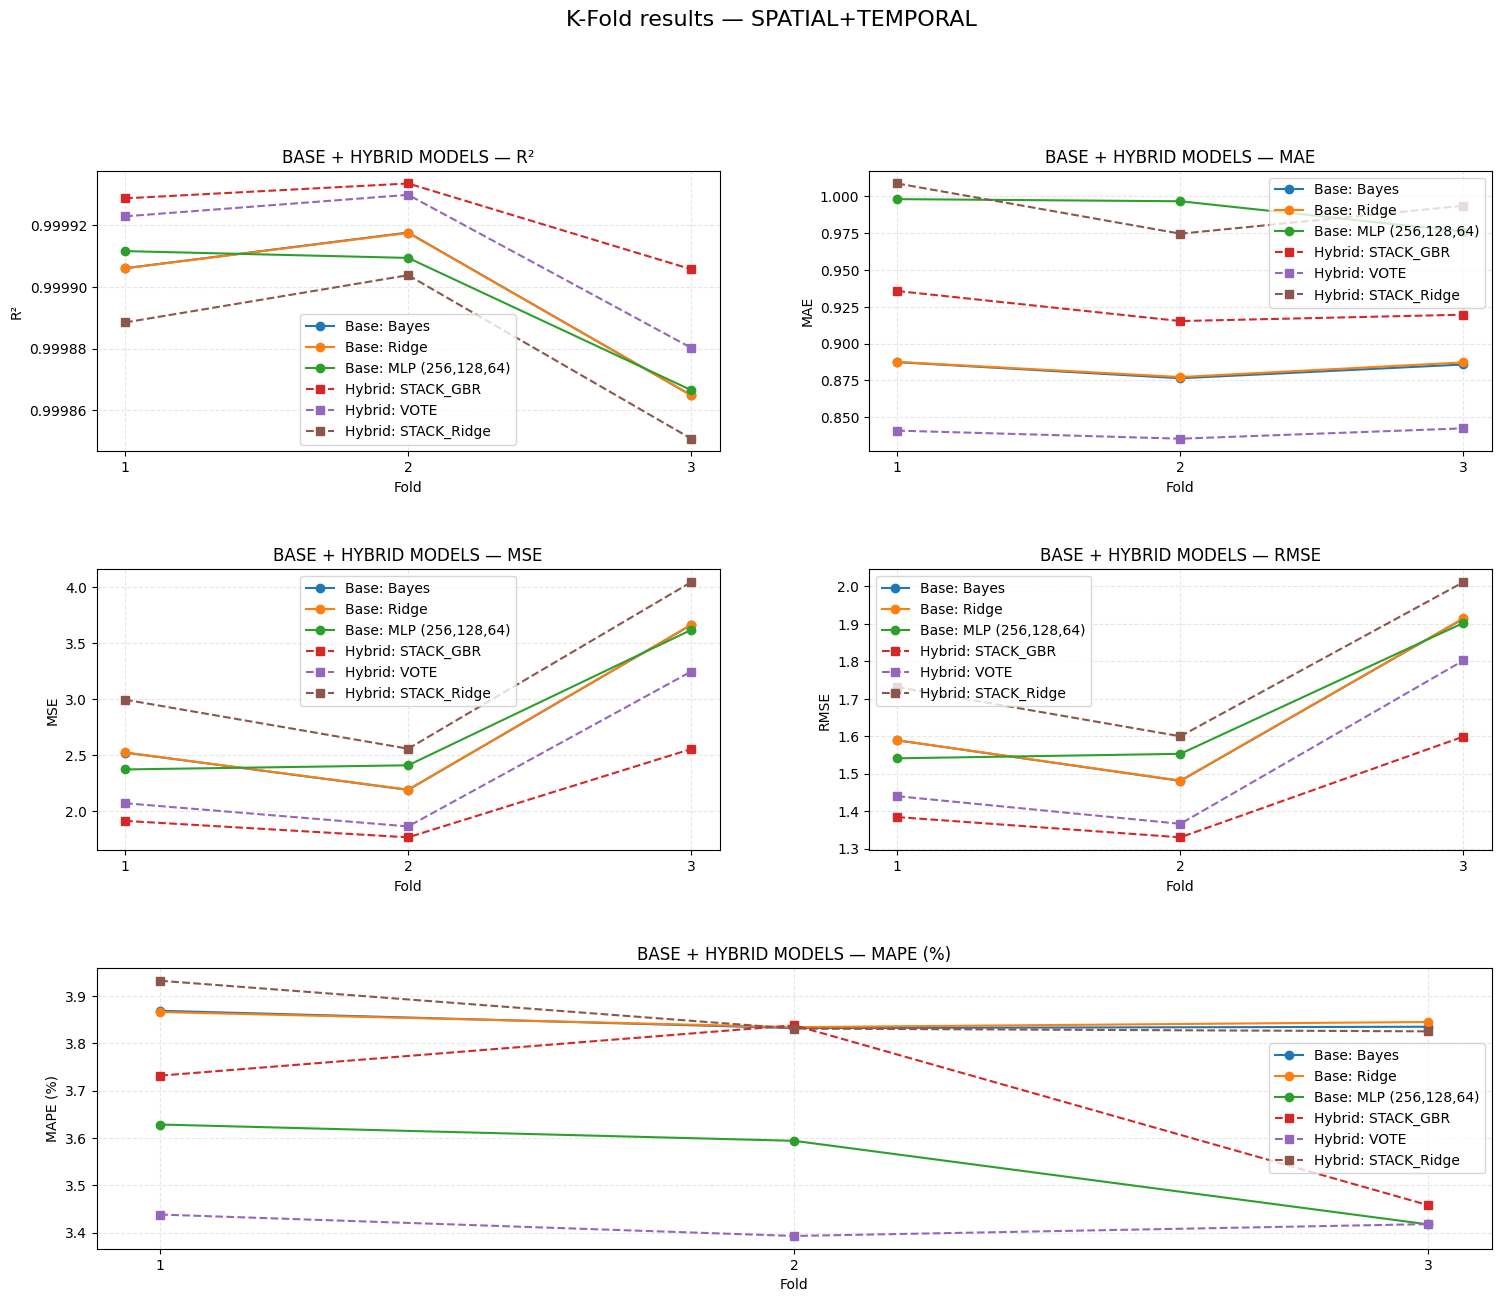


=== TOP-3 BASE BY FIVE-METRIC SCORE ===
           Combo            Model  Score  Overall_Rank  R2_Mean  MAE_Mean  MSE_Mean  RMSE_Mean  MAPE_Mean
SPATIAL+TEMPORAL            Bayes    8.0             1 0.999896  0.883183  2.793649   1.661242   3.845428
SPATIAL+TEMPORAL            Ridge    3.0             2 0.999896  0.883988  2.795296   1.661751   3.848565
SPATIAL+TEMPORAL MLP (256,128,64)    1.0             3 0.999896  0.990253  2.801912   1.665470   3.546608

=== TOP-3 HYBRID BY FIVE-METRIC SCORE ===
           Combo      Hybrid                        Bases  Score  Overall_Rank  R2_Mean  MAE_Mean  MSE_Mean  RMSE_Mean  MAPE_Mean
SPATIAL+TEMPORAL   STACK_GBR Ridge,Bayes,MLP (256,128,64)    9.0             1 0.999923  0.923513  2.080534   1.437719   3.675959
SPATIAL+TEMPORAL        VOTE Ridge,Bayes,MLP (256,128,64)    8.0             2 0.999911  0.839544  2.395934   1.536098   3.416366
SPATIAL+TEMPORAL STACK_Ridge Ridge,Bayes,MLP (256,128,64)    1.0             3 0.999881  0.992307  3.2

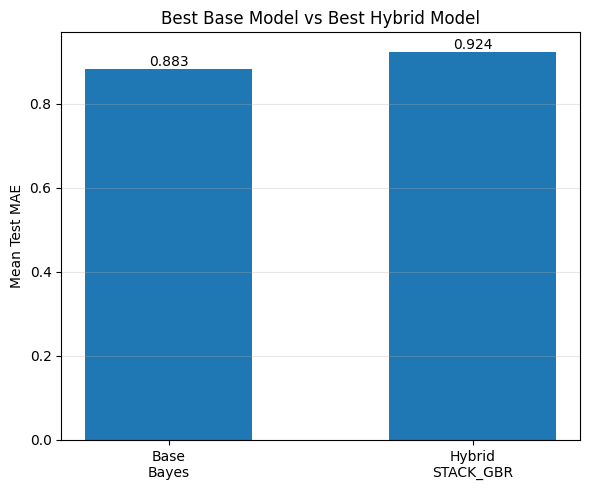


Diagnostic skipped: STACK_Lin or STACK_Ridge not in hyb_fold_tbl.

EXACT 2% ANOMALY REMOVAL BEFORE K-FOLD
Rows before anomaly removal : 111,573
Anomaly features            : 109
LOF/OCSVM fit rows          : 20,000
Isolation Forest anomalies : 5,579
LOF anomalies              : 5,457
OCSVM anomalies            : 7,242
Raw majority-vote anomalies: 5,606
Exact anomalies removed    : 5,579
Rows after removal         : 105,994
Percent removed            : 5.00%

=== FIRST 30 REMOVED ANOMALIES ===
 poi_id                           poi       date  count  IF_Anomaly  LOF_Anomaly  OCSVM_Anomaly  Anomaly_Votes  Majority_Vote_Anomaly  Combined_Anomaly_Score  Final_Anomaly
 6048.0                Fort Kearny #4 2023-09-29  729.0           1            1              1              3                      1                0.788157              1
 5110.0                  Branched Oak 2023-12-09  804.0           1            1              1              3                      1                0.7819

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.1068e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14744e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.15691e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.1068e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/pyt


=== K-FOLD TABLE SUMMARY ===
Base K-fold rows   : 9
Hybrid K-fold rows : 9

Base K-fold models:
['Ridge', 'Bayes', 'MLP (256,128,64)']

Hybrid K-fold models:
['STACK_GBR', 'VOTE', 'STACK_Ridge']

BASE MODEL K-FOLD SUMMARY — MAE, R², MSE, RMSE, MAPE, BIAS, ABSOLUTE BIAS, AND VARIANCE
           Combo            Model  MAE_Mean  MAE_Std  R2_Mean   R2_Std  MSE_Mean  MSE_Std  RMSE_Mean  RMSE_Std  MAPE_Mean  MAPE_Std  Fold_Bias_Mean  Fold_Bias_Std  Fold_Absolute_Bias_Mean  Fold_Absolute_Bias_Std  Fold_Variance_Mean  Fold_Variance_Std  R2_Rank  MAE_Rank  MSE_Rank  RMSE_Rank  MAPE_Rank  Total_Rank    Score  Overall_Rank
SPATIAL+TEMPORAL MLP (256,128,64)  0.907074 0.026193 0.999803 0.000012  2.290680 0.114882   1.513177  0.038231   3.773141  0.160879        0.098839       0.120662                 0.907074                0.026193            2.271268           0.098582 1.000000  3.000000  1.000000   1.000000   1.000000    7.000000 7.000000             1
SPATIAL+TEMPORAL            Bayes  0.8807

/var/folders/1d/g4zmv0kx6v910p8sldg41zfr0000gr/T/ipykernel_46945/3212032137.py:833: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.97])


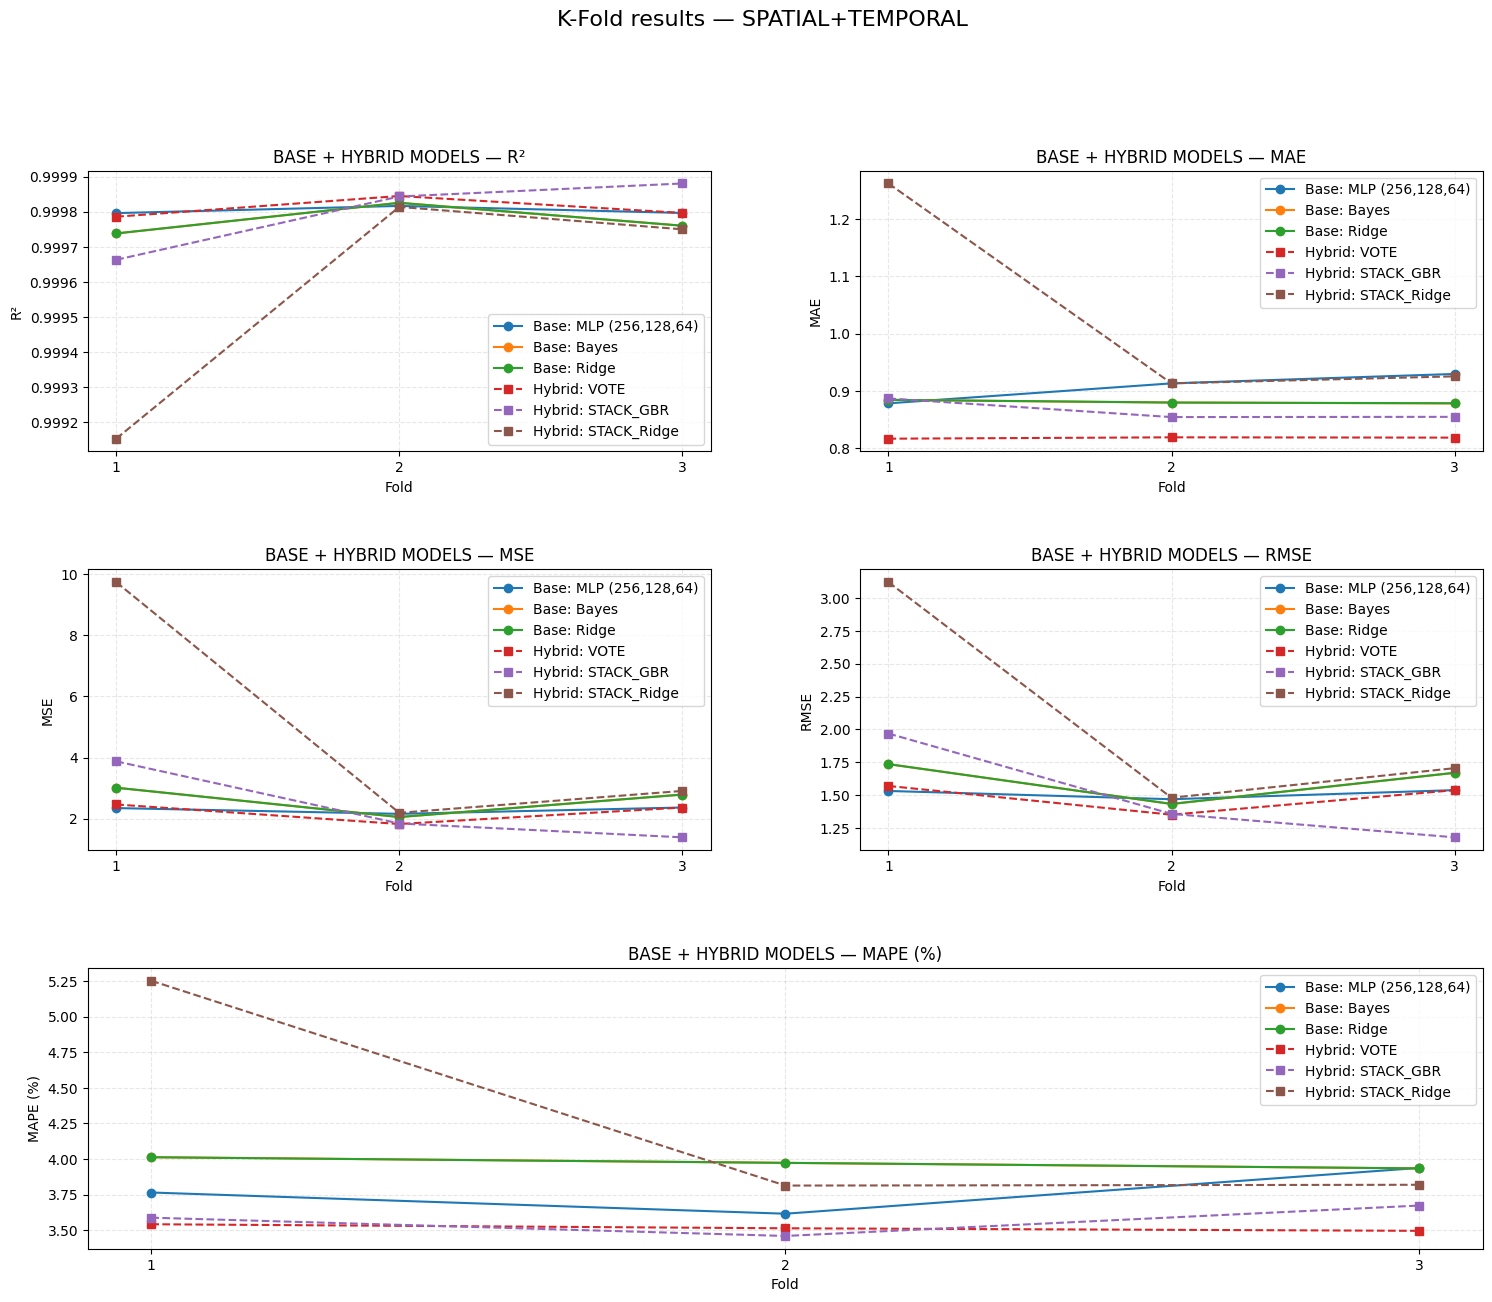


=== TOP-3 BASE BY FIVE-METRIC SCORE ===
           Combo            Model  Score  Overall_Rank  R2_Mean  MAE_Mean  MSE_Mean  RMSE_Mean  MAPE_Mean
SPATIAL+TEMPORAL MLP (256,128,64)    7.0             1 0.999803  0.907074  2.290680   1.513177   3.773141
SPATIAL+TEMPORAL            Bayes    4.0             2 0.999774  0.880754  2.618634   1.612985   3.973741
SPATIAL+TEMPORAL            Ridge    1.0             3 0.999774  0.880911  2.619215   1.613165   3.973542

=== TOP-3 HYBRID BY FIVE-METRIC SCORE ===
           Combo      Hybrid                        Bases  Score  Overall_Rank  R2_Mean  MAE_Mean  MSE_Mean  RMSE_Mean  MAPE_Mean
SPATIAL+TEMPORAL        VOTE Ridge,Bayes,MLP (256,128,64)   11.0             1 0.999809  0.818019  2.219127   1.486550   3.517616
SPATIAL+TEMPORAL   STACK_GBR Ridge,Bayes,MLP (256,128,64)    6.0             2 0.999796  0.865331  2.370002   1.501891   3.574142
SPATIAL+TEMPORAL STACK_Ridge Ridge,Bayes,MLP (256,128,64)    1.0             3 0.999572  1.033668  4.9

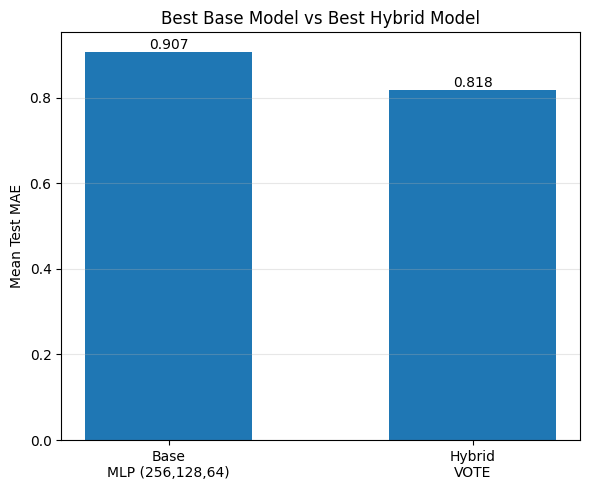


Diagnostic skipped: STACK_Lin or STACK_Ridge not in hyb_fold_tbl.


In [221]:
# =====================================================================================
# EXACT 5% ANOMALY REMOVAL: IF + LOF + OCSVM
# Runs before K-fold evaluation.
# Requires df to already be loaded.
# =====================================================================================
for _ in range(2):

    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from sklearn.ensemble import IsolationForest
    from sklearn.neighbors import LocalOutlierFactor
    from sklearn.svm import OneClassSVM

    ANOMALY_CONTAMINATION = 0.05
    ANOMALY_VOTE_THRESHOLD = 2
    ANOMALY_MAX_FIT_ROWS = 20000
    ANOMALY_RANDOM_STATE = 42

    if "df" not in globals():
        raise RuntimeError(
            "df is not defined. Run the data-loading and feature-engineering code first."
        )

    # Preserve original data before anomaly removal
    df_before_anomaly = df.copy()

    # Use numeric predictors only and exclude the target
    anomaly_features = sorted([
        c for c in df.select_dtypes(include=[np.number]).columns
        if c != "count"
        and c not in {
            "IF_Anomaly", "LOF_Anomaly", "OCSVM_Anomaly",
            "Anomaly_Votes", "Majority_Vote_Anomaly",
            "Combined_Anomaly_Score", "Final_Anomaly"
        }
        and df[c].notna().sum() > 0
        and df[c].nunique(dropna=True) > 1
    ])

    if not anomaly_features:
        raise RuntimeError("No usable numeric predictor columns found for anomaly detection.")

    anomaly_preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    X_anomaly = anomaly_preprocessor.fit_transform(df[anomaly_features])
    X_anomaly = np.asarray(X_anomaly, dtype=np.float32)

    rng = np.random.default_rng(ANOMALY_RANDOM_STATE)

    if len(X_anomaly) > ANOMALY_MAX_FIT_ROWS:
        fit_idx = rng.choice(
            len(X_anomaly),
            size=ANOMALY_MAX_FIT_ROWS,
            replace=False
        )
    else:
        fit_idx = np.arange(len(X_anomaly))

    X_fit_anomaly = X_anomaly[fit_idx]

    print("\n" + "=" * 80)
    print("EXACT 2% ANOMALY REMOVAL BEFORE K-FOLD")
    print("=" * 80)
    print(f"Rows before anomaly removal : {len(df):,}")
    print(f"Anomaly features            : {len(anomaly_features):,}")
    print(f"LOF/OCSVM fit rows          : {len(X_fit_anomaly):,}")

    # ---------------- Isolation Forest ----------------
    if_detector = IsolationForest(
        n_estimators=300,
        contamination=ANOMALY_CONTAMINATION,
        max_samples="auto",
        n_jobs=-1,
        random_state=ANOMALY_RANDOM_STATE,
    )

    if_raw = if_detector.fit_predict(X_anomaly)
    if_flag = (if_raw == -1).astype(np.int8)

    # ---------------- Local Outlier Factor ----------------
    lof_detector = LocalOutlierFactor(
        n_neighbors=35,
        contamination=ANOMALY_CONTAMINATION,
        novelty=True,
        n_jobs=-1,
    )

    lof_detector.fit(X_fit_anomaly)
    lof_raw = lof_detector.predict(X_anomaly)
    lof_flag = (lof_raw == -1).astype(np.int8)

    # ---------------- One-Class SVM ----------------
    ocsvm_detector = OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=ANOMALY_CONTAMINATION,
        cache_size=2000,
    )

    ocsvm_detector.fit(X_fit_anomaly)
    ocsvm_raw = ocsvm_detector.predict(X_anomaly)
    ocsvm_flag = (ocsvm_raw == -1).astype(np.int8)

    # ---------------- Voting and anomaly scores ----------------
    anomaly_votes = if_flag + lof_flag + ocsvm_flag

    majority_vote_flag = (
        anomaly_votes >= ANOMALY_VOTE_THRESHOLD
    ).astype(np.int8)

    # Higher values mean more anomalous
    if_score = -if_detector.score_samples(X_anomaly)
    lof_score = -lof_detector.score_samples(X_anomaly)
    ocsvm_score = -ocsvm_detector.score_samples(X_anomaly)

    def _minmax_anomaly_score(values):
        values = np.asarray(values, dtype=float)

        vmin = np.nanmin(values)
        vmax = np.nanmax(values)

        if (
            not np.isfinite(vmin)
            or not np.isfinite(vmax)
            or vmax == vmin
        ):
            return np.zeros_like(values, dtype=float)

        return (values - vmin) / (vmax - vmin)

    combined_anomaly_score = (
        _minmax_anomaly_score(if_score)
        + _minmax_anomaly_score(lof_score)
        + _minmax_anomaly_score(ocsvm_score)
    ) / 3.0

    # Remove exactly 2% of the current rows
    target_remove = int(round(len(df) * ANOMALY_CONTAMINATION))
    target_remove = max(0, min(target_remove, len(df)))

    rank_df = pd.DataFrame({
        "Anomaly_Votes": anomaly_votes,
        "Combined_Anomaly_Score": combined_anomaly_score,
        "Original_Position": np.arange(len(df)),
    }, index=df.index)

    remove_index = (
        rank_df
        .sort_values(
            ["Anomaly_Votes", "Combined_Anomaly_Score", "Original_Position"],
            ascending=[False, False, True]
        )
        .head(target_remove)
        .index
    )

    final_anomaly_flag = pd.Series(
        0,
        index=df.index,
        dtype=np.int8
    )
    final_anomaly_flag.loc[remove_index] = 1

    # Flagged copy for inspection
    df_anomaly_flagged = df.copy()
    df_anomaly_flagged["IF_Anomaly"] = if_flag
    df_anomaly_flagged["LOF_Anomaly"] = lof_flag
    df_anomaly_flagged["OCSVM_Anomaly"] = ocsvm_flag
    df_anomaly_flagged["Anomaly_Votes"] = anomaly_votes
    df_anomaly_flagged["Majority_Vote_Anomaly"] = majority_vote_flag
    df_anomaly_flagged["Combined_Anomaly_Score"] = combined_anomaly_score
    df_anomaly_flagged["Final_Anomaly"] = final_anomaly_flag.to_numpy()

    df_detected_anomalies = df_anomaly_flagged.loc[
        df_anomaly_flagged["Final_Anomaly"] == 1
    ].copy()

    # Keep only normal rows for K-fold evaluation
    df = df_anomaly_flagged.loc[
        df_anomaly_flagged["Final_Anomaly"] == 0
    ].copy()

    anomaly_helper_cols = [
        "IF_Anomaly",
        "LOF_Anomaly",
        "OCSVM_Anomaly",
        "Anomaly_Votes",
        "Majority_Vote_Anomaly",
        "Combined_Anomaly_Score",
        "Final_Anomaly",
    ]

    df = df.drop(
        columns=anomaly_helper_cols,
        errors="ignore"
    )

    df_after_anomaly = df.copy()

    rows_removed_anomaly = len(df_before_anomaly) - len(df_after_anomaly)
    pct_removed_anomaly = (
        100.0 * rows_removed_anomaly / len(df_before_anomaly)
        if len(df_before_anomaly) > 0
        else 0.0
    )

    print(f"Isolation Forest anomalies : {int(if_flag.sum()):,}")
    print(f"LOF anomalies              : {int(lof_flag.sum()):,}")
    print(f"OCSVM anomalies            : {int(ocsvm_flag.sum()):,}")
    print(f"Raw majority-vote anomalies: {int(majority_vote_flag.sum()):,}")
    print(f"Exact anomalies removed    : {rows_removed_anomaly:,}")
    print(f"Rows after removal         : {len(df_after_anomaly):,}")
    print(f"Percent removed            : {pct_removed_anomaly:.2f}%")
    print("=" * 80)

    print("\n=== FIRST 30 REMOVED ANOMALIES ===")

    anomaly_show_cols = [
        c for c in [
            "poi_id",
            "poi",
            "date",
            "count",
            "IF_Anomaly",
            "LOF_Anomaly",
            "OCSVM_Anomaly",
            "Anomaly_Votes",
            "Majority_Vote_Anomaly",
            "Combined_Anomaly_Score",
            "Final_Anomaly",
        ]
        if c in df_detected_anomalies.columns
    ]

    if not df_detected_anomalies.empty:
        print(
            df_detected_anomalies[anomaly_show_cols]
            .sort_values(
                ["Anomaly_Votes", "Combined_Anomaly_Score"],
                ascending=[False, False]
            )
            .head(30)
            .to_string(index=False)
        )
    else:
        print("No anomalies were removed.")


    # =====================================================================================
    # K-FOLD TABLES + TOP-3 BASE / TOP-3 HYBRID PLOTS
    # Paste this AFTER your hybrid block, after df_h is created.
    # =====================================================================================

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from sklearn.model_selection import KFold
    from sklearn.base import clone
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.ensemble import VotingRegressor, StackingRegressor, GradientBoostingRegressor
    from sklearn.linear_model import Ridge

    N_SPLITS = 3
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # ---------------- Helpers ----------------
    def _get_model_def(name):
        name = str(name).strip()

        for mname, mdl in MODELS:
            if str(mname).strip() == name:
                return mdl

        return None


    def _parse_base_names_safely(bases_str):
        """
        Safely parse model names from df_h['Bases'], including names with commas:
        Example: MLP (256,128,64)
        """
        bases_str = str(bases_str)
        model_names = [str(mname).strip() for mname, _ in MODELS]

        found = []
        remaining = bases_str

        for mname in sorted(model_names, key=len, reverse=True):
            if mname in remaining:
                found.append(mname)
                remaining = remaining.replace(mname, "")

        return found


    def _safe_mape(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)

        denominator = np.where(
            np.abs(y_true) < 1e-8,
            np.nan,
            np.abs(y_true)
        )

        return float(
            np.nanmean(
                np.abs((y_true - y_pred) / denominator)
            ) * 100
        )


    # =====================================================================================
    # 1) CREATE base_fold_tbl
    # =====================================================================================

    base_fold_rows = []

    for combo_name, feats in BASE_COMBOS.items():

        feats = [f for f in feats if f in df.columns]

        if len(feats) == 0:
            continue

        X, y = build_Xy(df, feats)

        if len(X) == 0 or X.shape[1] == 0:
            continue

        top3_base_names = (
            final_tbl[final_tbl["Combo"] == combo_name]
            .sort_values("Score", ascending=False)
            .head(3)["Model"]
            .astype(str)
            .tolist()
        )

        if len(top3_base_names) == 0:
            continue

        for fold, (tr_idx, te_idx) in enumerate(kf.split(X), start=1):

            X_tr, X_te = X[tr_idx], X[te_idx]
            y_tr, y_te = y[tr_idx], y[te_idx]

            for model_name in top3_base_names:

                base_def = _get_model_def(model_name)

                if base_def is None:
                    continue

                model = clone(base_def)
                model.fit(X_tr, y_tr)

                pred_te = model.predict(X_te)

                # Bias and variance from this fold's prediction errors
                fold_errors = np.asarray(pred_te, dtype=float) - np.asarray(y_te, dtype=float)
                fold_bias = float(np.mean(fold_errors))
                fold_absolute_bias = float(np.mean(np.abs(fold_errors)))
                fold_variance = float(
                    np.var(fold_errors, ddof=1)
                    if len(fold_errors) > 1
                    else 0.0
                )

                test_mse = mean_squared_error(y_te, pred_te)

                base_fold_rows.append({
                    "Fold": fold,
                    "Combo": combo_name,
                    "Model": model_name,
                    "Test_MAE": mean_absolute_error(y_te, pred_te),
                    "Test_R2": r2_score(y_te, pred_te),
                    "Test_MSE": test_mse,
                    "Test_RMSE": np.sqrt(test_mse),
                    "Test_MAPE": _safe_mape(y_te, pred_te),
                    "Fold_Bias": fold_bias,
                    "Fold_Absolute_Bias": fold_absolute_bias,
                    "Fold_Variance": fold_variance
                })

    base_fold_tbl = pd.DataFrame(base_fold_rows)

    # Base-model K-fold summary with MAE, R², bias, absolute bias, and variance
    if not base_fold_tbl.empty:
        base_kfold_summary = (
            base_fold_tbl
            .groupby(["Combo", "Model"], as_index=False)
            .agg(
                MAE_Mean=("Test_MAE", "mean"),
                MAE_Std=("Test_MAE", "std"),
                R2_Mean=("Test_R2", "mean"),
                R2_Std=("Test_R2", "std"),
                MSE_Mean=("Test_MSE", "mean"),
                MSE_Std=("Test_MSE", "std"),
                RMSE_Mean=("Test_RMSE", "mean"),
                RMSE_Std=("Test_RMSE", "std"),
                MAPE_Mean=("Test_MAPE", "mean"),
                MAPE_Std=("Test_MAPE", "std"),
                Fold_Bias_Mean=("Fold_Bias", "mean"),
                Fold_Bias_Std=("Fold_Bias", "std"),
                Fold_Absolute_Bias_Mean=("Fold_Absolute_Bias", "mean"),
                Fold_Absolute_Bias_Std=("Fold_Absolute_Bias", "std"),
                Fold_Variance_Mean=("Fold_Variance", "mean"),
                Fold_Variance_Std=("Fold_Variance", "std")
            )
            .sort_values(
                ["MAE_Mean", "R2_Mean"],
                ascending=[True, False]
            )
            .reset_index(drop=True)
        )
    else:
        base_kfold_summary = pd.DataFrame()


    # =====================================================================================
    # 2) CREATE hyb_fold_tbl
    # =====================================================================================

    hyb_fold_rows = []

    for combo_name, feats in BASE_COMBOS.items():

        feats = [f for f in feats if f in df.columns]

        if len(feats) == 0:
            continue

        X, y = build_Xy(df, feats)

        if len(X) == 0 or X.shape[1] == 0:
            continue

        top_hybrids = (
            df_h[df_h["Combo"] == combo_name]
            .sort_values("Score_H", ascending=False)
            .head(8)
        )

        for fold, (tr_idx, te_idx) in enumerate(kf.split(X), start=1):

            X_tr, X_te = X[tr_idx], X[te_idx]
            y_tr, y_te = y[tr_idx], y[te_idx]

            for _, hr in top_hybrids.iterrows():

                hybrid_name = hr["Hybrid"]

                base_names = _parse_base_names_safely(hr["Bases"])

                bases = []

                for name in base_names:

                    base_def = _get_model_def(name)

                    if base_def is not None:
                        bases.append((name, clone(base_def)))

                if len(bases) == 0:
                    continue

                try:

                    if hybrid_name == "VOTE":

                        model = VotingRegressor(bases)

                    elif hybrid_name == "STACK_Ridge":

                        model = StackingRegressor(
                            estimators=bases,
                            final_estimator=Ridge(alpha=1.0),
                            cv=3,
                            passthrough=True
                        )

                    elif hybrid_name == "STACK_GBR":

                        model = StackingRegressor(
                            estimators=bases,
                            final_estimator=GradientBoostingRegressor(
                                random_state=RANDOM_STATE,
                                n_estimators=200,
                                learning_rate=0.05,
                                max_depth=3
                            ),
                            cv=3,
                            passthrough=True
                        )

                    else:
                        continue

                    model.fit(X_tr, y_tr)
                    pred_te = model.predict(X_te)

                    # Bias and variance from this fold's prediction errors
                    fold_errors = np.asarray(pred_te, dtype=float) - np.asarray(y_te, dtype=float)
                    fold_bias = float(np.mean(fold_errors))
                    fold_absolute_bias = float(np.mean(np.abs(fold_errors)))
                    fold_variance = float(
                        np.var(fold_errors, ddof=1)
                        if len(fold_errors) > 1
                        else 0.0
                    )

                    test_mse = mean_squared_error(y_te, pred_te)

                    hyb_fold_rows.append({
                        "Fold": fold,
                        "Combo": combo_name,
                        "Hybrid": hybrid_name,
                        "Bases": hr["Bases"],
                        "Test_MAE": mean_absolute_error(y_te, pred_te),
                        "Test_R2": r2_score(y_te, pred_te),
                        "Test_MSE": test_mse,
                        "Test_RMSE": np.sqrt(test_mse),
                        "Test_MAPE": _safe_mape(y_te, pred_te),
                        "Fold_Bias": fold_bias,
                        "Fold_Absolute_Bias": fold_absolute_bias,
                        "Fold_Variance": fold_variance
                    })

                except Exception as e:
                    print(f"[skip] {hybrid_name} fold={fold}: {type(e).__name__}: {e}")

    hyb_fold_tbl = pd.DataFrame(hyb_fold_rows)

    # Hybrid-model K-fold summary with MAE, R², bias, absolute bias, and variance
    if not hyb_fold_tbl.empty:
        hybrid_kfold_summary = (
            hyb_fold_tbl
            .groupby(["Combo", "Hybrid", "Bases"], as_index=False)
            .agg(
                MAE_Mean=("Test_MAE", "mean"),
                MAE_Std=("Test_MAE", "std"),
                R2_Mean=("Test_R2", "mean"),
                R2_Std=("Test_R2", "std"),
                MSE_Mean=("Test_MSE", "mean"),
                MSE_Std=("Test_MSE", "std"),
                RMSE_Mean=("Test_RMSE", "mean"),
                RMSE_Std=("Test_RMSE", "std"),
                MAPE_Mean=("Test_MAPE", "mean"),
                MAPE_Std=("Test_MAPE", "std"),
                Fold_Bias_Mean=("Fold_Bias", "mean"),
                Fold_Bias_Std=("Fold_Bias", "std"),
                Fold_Absolute_Bias_Mean=("Fold_Absolute_Bias", "mean"),
                Fold_Absolute_Bias_Std=("Fold_Absolute_Bias", "std"),
                Fold_Variance_Mean=("Fold_Variance", "mean"),
                Fold_Variance_Std=("Fold_Variance", "std")
            )
            .sort_values(
                ["MAE_Mean", "R2_Mean"],
                ascending=[True, False]
            )
            .reset_index(drop=True)
        )
    else:
        hybrid_kfold_summary = pd.DataFrame()


    # =====================================================================================
    # FIVE-METRIC RANKING FOR BASE AND HYBRID MODELS
    # Higher Score = Better Overall Model
    # R²: higher is better; MAE/MSE/RMSE/MAPE: lower is better
    # Ranking is calculated separately within each feature Combo.
    # =====================================================================================

    def rank_models_by_five_metrics(summary_tbl, model_col):
        """Rank models using equal-weight ranks across R², MAE, MSE, RMSE, and MAPE."""

        required_cols = [
            "Combo", model_col,
            "R2_Mean", "MAE_Mean", "MSE_Mean",
            "RMSE_Mean", "MAPE_Mean"
        ]

        if summary_tbl is None or summary_tbl.empty:
            return pd.DataFrame(columns=required_cols + [
                "R2_Rank", "MAE_Rank", "MSE_Rank",
                "RMSE_Rank", "MAPE_Rank",
                "Total_Rank", "Score", "Overall_Rank"
            ])

        missing = [c for c in required_cols if c not in summary_tbl.columns]
        if missing:
            raise KeyError(
                f"Cannot rank {model_col} models. Missing columns: {missing}"
            )

        ranked_groups = []

        for combo_name, group in summary_tbl.groupby("Combo", sort=False):
            g = group.copy()

            g["R2_Rank"] = g["R2_Mean"].rank(
                ascending=False, method="average"
            )
            g["MAE_Rank"] = g["MAE_Mean"].rank(
                ascending=True, method="average"
            )
            g["MSE_Rank"] = g["MSE_Mean"].rank(
                ascending=True, method="average"
            )
            g["RMSE_Rank"] = g["RMSE_Mean"].rank(
                ascending=True, method="average"
            )
            g["MAPE_Rank"] = g["MAPE_Mean"].rank(
                ascending=True, method="average"
            )

            g["Total_Rank"] = (
                g["R2_Rank"]
                + g["MAE_Rank"]
                + g["MSE_Rank"]
                + g["RMSE_Rank"]
                + g["MAPE_Rank"]
            )

            # Preserve the same score logic used previously:
            # best model receives the highest score.
            g["Score"] = (
                g["Total_Rank"].max()
                - g["Total_Rank"]
                + 1
            )

            # Explicit ordinal rank for convenient reporting.
            g["Overall_Rank"] = g["Total_Rank"].rank(
                ascending=True, method="min"
            ).astype(int)

            g = g.sort_values(
                ["Score", "R2_Mean", "MAE_Mean"],
                ascending=[False, False, True]
            )

            ranked_groups.append(g)

        return pd.concat(ranked_groups, ignore_index=True)


    base_kfold_ranked = rank_models_by_five_metrics(
        base_kfold_summary,
        model_col="Model"
    )

    hybrid_kfold_ranked = rank_models_by_five_metrics(
        hybrid_kfold_summary,
        model_col="Hybrid"
    )

    # Keep ranked tables as the main updated summaries.
    base_kfold_summary = base_kfold_ranked.copy()
    hybrid_kfold_summary = hybrid_kfold_ranked.copy()

    print("\n=== K-FOLD TABLE SUMMARY ===")
    print(f"Base K-fold rows   : {len(base_fold_tbl):,}")
    print(f"Hybrid K-fold rows : {len(hyb_fold_tbl):,}")

    if not base_fold_tbl.empty:
        print("\nBase K-fold models:")
        print(base_fold_tbl["Model"].drop_duplicates().tolist())

    if not hyb_fold_tbl.empty:
        print("\nHybrid K-fold models:")
        print(hyb_fold_tbl["Hybrid"].drop_duplicates().tolist())

    if not base_kfold_summary.empty:
        print("\n" + "=" * 120)
        print("BASE MODEL K-FOLD SUMMARY — MAE, R², MSE, RMSE, MAPE, BIAS, ABSOLUTE BIAS, AND VARIANCE")
        print("=" * 120)
        print(
            base_kfold_summary.to_string(
                index=False,
                float_format=lambda x: f"{x:.6f}"
            )
        )

    if not hybrid_kfold_summary.empty:
        print("\n" + "=" * 120)
        print("HYBRID MODEL K-FOLD SUMMARY — MAE, R², MSE, RMSE, MAPE, BIAS, ABSOLUTE BIAS, AND VARIANCE")
        print("=" * 120)
        print(
            hybrid_kfold_summary.to_string(
                index=False,
                float_format=lambda x: f"{x:.6f}"
            )
        )


    # =====================================================================================
    # 3) PLOT TOP-3 BASE + TOP-3 HYBRID
    # =====================================================================================

    def pick_topk_by_five_metric_score(ranked_tbl, name_col, combo_name, k=3):
        """Select the top-k models using the five-metric Score."""

        if ranked_tbl is None or ranked_tbl.empty:
            return [], pd.DataFrame()

        selected = ranked_tbl[
            ranked_tbl["Combo"] == combo_name
        ].copy()

        selected = selected.sort_values(
            ["Score", "R2_Mean", "MAE_Mean"],
            ascending=[False, False, True]
        )

        return selected[name_col].head(k).astype(str).tolist(), selected


    def plot_kfold_top3(base_fold_tbl, hyb_fold_tbl, combo_title="SPATIAL+TEMPORAL"):

        if base_fold_tbl.empty:
            print("\nNo base K-fold results were created. Check final_tbl, BASE_COMBOS, and features.")
            return [], []

        if hyb_fold_tbl.empty:
            print("\nNo hybrid K-fold results were created. Check df_h and hybrid bases.")
            return [], []

        top3_base, base_rank = pick_topk_by_five_metric_score(
            base_kfold_ranked,
            name_col="Model",
            combo_name=combo_title,
            k=3
        )

        top3_hyb, hyb_rank = pick_topk_by_five_metric_score(
            hybrid_kfold_ranked,
            name_col="Hybrid",
            combo_name=combo_title,
            k=3
        )

        b = base_fold_tbl[base_fold_tbl["Model"].isin(top3_base)].copy()
        h = hyb_fold_tbl[hyb_fold_tbl["Hybrid"].isin(top3_hyb)].copy()

        folds = sorted(set(b["Fold"].unique()) | set(h["Fold"].unique()))

        metric_settings = [
            ("Test_R2", "R²", "BASE + HYBRID MODELS — R²"),
            ("Test_MAE", "MAE", "BASE + HYBRID MODELS — MAE"),
            ("Test_MSE", "MSE", "BASE + HYBRID MODELS — MSE"),
            ("Test_RMSE", "RMSE", "BASE + HYBRID MODELS — RMSE"),
            ("Test_MAPE", "MAPE (%)", "BASE + HYBRID MODELS — MAPE (%)")
        ]

        fig = plt.figure(figsize=(18, 14))

        gs = fig.add_gridspec(
            3,
            2,
            height_ratios=[1, 1, 1],
            hspace=0.42,
            wspace=0.24
        )

        axes = [
            fig.add_subplot(gs[0, 0]),
            fig.add_subplot(gs[0, 1]),
            fig.add_subplot(gs[1, 0]),
            fig.add_subplot(gs[1, 1]),
            fig.add_subplot(gs[2, :])
        ]

        for ax, (metric, ylabel, title) in zip(axes, metric_settings):

            b_metric = (
                b.pivot_table(
                    index="Fold",
                    columns="Model",
                    values=metric,
                    aggfunc="mean"
                )
                .reindex(folds)
            )

            h_metric = (
                h.pivot_table(
                    index="Fold",
                    columns="Hybrid",
                    values=metric,
                    aggfunc="mean"
                )
                .reindex(folds)
            )

            for m in top3_base:
                if m in b_metric.columns:
                    ax.plot(
                        b_metric.index,
                        b_metric[m].values,
                        marker="o",
                        label=f"Base: {m}"
                    )

            for m in top3_hyb:
                if m in h_metric.columns:
                    ax.plot(
                        h_metric.index,
                        h_metric[m].values,
                        marker="s",
                        linestyle="--",
                        label=f"Hybrid: {m}"
                    )

            ax.set_title(title)
            ax.set_xlabel("Fold")
            ax.set_ylabel(ylabel)
            ax.set_xticks(folds)
            ax.legend(loc="best")
            ax.grid(alpha=0.3, linestyle="--")

        fig.suptitle(
            f"K-Fold results — {combo_title}",
            fontsize=16,
            y=0.995
        )

        plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.97])
        plt.show()

        print("\n=== TOP-3 BASE BY FIVE-METRIC SCORE ===")
        print(
            base_rank.sort_values(
                ["Score", "R2_Mean", "MAE_Mean"],
                ascending=[False, False, True]
            )
            .head(10)[
                ["Combo", "Model", "Score", "Overall_Rank",
                 "R2_Mean", "MAE_Mean", "MSE_Mean",
                 "RMSE_Mean", "MAPE_Mean"]
            ]
            .to_string(index=False)
        )

        print("\n=== TOP-3 HYBRID BY FIVE-METRIC SCORE ===")
        print(
            hyb_rank.sort_values(
                ["Score", "R2_Mean", "MAE_Mean"],
                ascending=[False, False, True]
            )
            .head(10)[
                ["Combo", "Hybrid", "Bases", "Score", "Overall_Rank",
                 "R2_Mean", "MAE_Mean", "MSE_Mean",
                 "RMSE_Mean", "MAPE_Mean"]
            ]
            .to_string(index=False)
        )

        # Compare the best base and hybrid selected by the five-metric Score.
        best_base_row = base_rank.sort_values(
            ["Score", "R2_Mean", "MAE_Mean"],
            ascending=[False, False, True]
        ).iloc[0]

        best_hybrid_row = hyb_rank.sort_values(
            ["Score", "R2_Mean", "MAE_Mean"],
            ascending=[False, False, True]
        ).iloc[0]

        best_base_name = str(best_base_row["Model"])
        best_hybrid_name = str(best_hybrid_row["Hybrid"])

        best_base_mae = float(best_base_row["MAE_Mean"])
        best_hybrid_mae = float(best_hybrid_row["MAE_Mean"])

        plt.figure(figsize=(6, 5))

        bars = plt.bar(
            [f"Base\n{best_base_name}", f"Hybrid\n{best_hybrid_name}"],
            [best_base_mae, best_hybrid_mae],
            width=0.55
        )

        plt.ylabel("Mean Test MAE")
        plt.title("Best Base Model vs Best Hybrid Model")
        plt.grid(axis="y", alpha=0.3)

        for bar, value in zip(
            bars,
            [best_base_mae, best_hybrid_mae]
        ):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:.3f}",
                ha="center",
                va="bottom"
            )

        plt.tight_layout()
        plt.show()

        return top3_base, top3_hyb

    # =====================================================================================
    # 4) DIAGNOSTIC
    # =====================================================================================

    def diagnose_stack_similarity(hyb_fold_tbl, a="STACK_Lin", b="STACK_Ridge"):

        if (
            a not in hyb_fold_tbl["Hybrid"].unique()
            or b not in hyb_fold_tbl["Hybrid"].unique()
        ):
            print(f"\nDiagnostic skipped: {a} or {b} not in hyb_fold_tbl.")
            return

        aa = hyb_fold_tbl[hyb_fold_tbl["Hybrid"] == a].sort_values("Fold")
        bb = hyb_fold_tbl[hyb_fold_tbl["Hybrid"] == b].sort_values("Fold")

        merged = aa.merge(
            bb,
            on=["Fold"],
            suffixes=(f"_{a}", f"_{b}")
        )

        merged["dMAE"] = merged[f"Test_MAE_{a}"] - merged[f"Test_MAE_{b}"]
        merged["dR2"] = merged[f"Test_R2_{a}"] - merged[f"Test_R2_{b}"]

        print(f"\n=== {a} vs {b} per-fold differences ===")

        print(
            merged[
                [
                    "Fold",
                    f"Test_MAE_{a}",
                    f"Test_MAE_{b}",
                    "dMAE",
                    f"Test_R2_{a}",
                    f"Test_R2_{b}",
                    "dR2"
                ]
            ].to_string(index=False, float_format=lambda x: f"{x:.6f}")
        )


    # ===================== RUN =====================
    top3_base, top3_hyb = plot_kfold_top3(
        base_fold_tbl,
        hyb_fold_tbl,
        combo_title="SPATIAL+TEMPORAL"
    )

    diagnose_stack_similarity(
        hyb_fold_tbl,
        a="STACK_Lin",
        b="STACK_Ridge"
    )

In [222]:
# =============================================================================
# COPY THE PREVIOUS BASE MODEL SUMMARY
# =============================================================================

base_fold_tbl_after_anomaly_mean = (
    base_kfold_summary.copy()
    .rename(
        columns={
            "R2_Mean": "Mean_R2",
            "MAE_Mean": "Mean_MAE",
            "MSE_Mean": "Mean_MSE",
            "RMSE_Mean": "Mean_RMSE",
            "MAPE_Mean": "Mean_MAPE",
        }
    )
)


# =============================================================================
# CHECK REQUIRED COLUMNS
# =============================================================================

required_columns = [
    "Mean_R2",
    "Mean_MAE",
    "Mean_MSE",
    "Mean_RMSE",
    "Mean_MAPE",
]

missing_columns = [
    column
    for column in required_columns
    if column not in base_fold_tbl_after_anomaly_mean.columns
]

if missing_columns:
    raise ValueError(
        "The following required columns are missing from "
        f"base_kfold_summary: {missing_columns}"
    )


# =============================================================================
# FIVE-METRIC RANKING
# =============================================================================

# Higher R² is better
r2_rank = (
    base_fold_tbl_after_anomaly_mean["Mean_R2"]
    .rank(
        ascending=False,
        method="average"
    )
)

# Lower error values are better
mae_rank = (
    base_fold_tbl_after_anomaly_mean["Mean_MAE"]
    .rank(
        ascending=True,
        method="average"
    )
)

mse_rank = (
    base_fold_tbl_after_anomaly_mean["Mean_MSE"]
    .rank(
        ascending=True,
        method="average"
    )
)

rmse_rank = (
    base_fold_tbl_after_anomaly_mean["Mean_RMSE"]
    .rank(
        ascending=True,
        method="average"
    )
)

mape_rank = (
    base_fold_tbl_after_anomaly_mean["Mean_MAPE"]
    .rank(
        ascending=True,
        method="average"
    )
)


# =============================================================================
# TOTAL RANK
# Lower Total_Rank = Better Model
# =============================================================================

base_fold_tbl_after_anomaly_mean["Total_Rank"] = (
    r2_rank
    + mae_rank
    + mse_rank
    + rmse_rank
    + mape_rank
)


# =============================================================================
# SCORE
# Higher Score = Better Model
# +1 ensures that the lowest score is 1 instead of 0
# =============================================================================

base_fold_tbl_after_anomaly_mean["Score"] = (
    base_fold_tbl_after_anomaly_mean["Total_Rank"].max()
    - base_fold_tbl_after_anomaly_mean["Total_Rank"]
    + 1
)


# =============================================================================
# SORT BY SCORE
# Tie-breakers:
# 1. Higher R²
# 2. Lower MAE
# 3. Lower MSE
# 4. Lower RMSE
# 5. Lower MAPE
# =============================================================================

base_fold_tbl_after_anomaly_mean = (
    base_fold_tbl_after_anomaly_mean
    .sort_values(
        by=[
            "Score",
            "Mean_R2",
            "Mean_MAE",
            "Mean_MSE",
            "Mean_RMSE",
            "Mean_MAPE",
        ],
        ascending=[
            False,
            False,
            True,
            True,
            True,
            True,
        ]
    )
    .reset_index(drop=True)
)


# =============================================================================
# PRINT RESULTS
# =============================================================================

print("\n=== Mean Base Model Results After Anomaly Removal ===")

print(
    base_fold_tbl_after_anomaly_mean.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


=== Mean Base Model Results After Anomaly Removal ===
           Combo            Model  Mean_MAE  MAE_Std  Mean_R2   R2_Std  Mean_MSE  MSE_Std  Mean_RMSE  RMSE_Std  Mean_MAPE  MAPE_Std  Fold_Bias_Mean  Fold_Bias_Std  Fold_Absolute_Bias_Mean  Fold_Absolute_Bias_Std  Fold_Variance_Mean  Fold_Variance_Std  R2_Rank  MAE_Rank  MSE_Rank  RMSE_Rank  MAPE_Rank  Total_Rank    Score  Overall_Rank
SPATIAL+TEMPORAL MLP (256,128,64)  0.907074 0.026193 0.999803 0.000012  2.290680 0.114882   1.513177  0.038231   3.773141  0.160879        0.098839       0.120662                 0.907074                0.026193            2.271268           0.098582 1.000000  3.000000  1.000000   1.000000   1.000000    7.000000 7.000000             1
SPATIAL+TEMPORAL            Bayes  0.880754 0.003252 0.999774 0.000045  2.618634 0.502036   1.612985  0.159282   3.973741  0.039426        0.021266       0.006582                 0.880754                0.003252            2.618227           0.501987 2.000000  1.000000  

In [223]:
# =============================================================================
# COPY THE PREVIOUS HYBRID SUMMARY
# =============================================================================

hyb_fold_tbl_after_anomaly_mean = (
    hybrid_kfold_summary.copy()
    .rename(
        columns={
            "R2_Mean": "Mean_R2",
            "MAE_Mean": "Mean_MAE",
            "MSE_Mean": "Mean_MSE",
            "RMSE_Mean": "Mean_RMSE",
            "MAPE_Mean": "Mean_MAPE",
        }
    )
)


# =============================================================================
# FIVE-METRIC RANKING
# =============================================================================

r2_rank = (
    hyb_fold_tbl_after_anomaly_mean["Mean_R2"]
    .rank(ascending=False)
)

mae_rank = (
    hyb_fold_tbl_after_anomaly_mean["Mean_MAE"]
    .rank(ascending=True)
)

mse_rank = (
    hyb_fold_tbl_after_anomaly_mean["Mean_MSE"]
    .rank(ascending=True)
)

rmse_rank = (
    hyb_fold_tbl_after_anomaly_mean["Mean_RMSE"]
    .rank(ascending=True)
)

mape_rank = (
    hyb_fold_tbl_after_anomaly_mean["Mean_MAPE"]
    .rank(ascending=True)
)


# =============================================================================
# TOTAL RANK
# =============================================================================

total_rank = (
    r2_rank
    + mae_rank
    + mse_rank
    + rmse_rank
    + mape_rank
)


# =============================================================================
# SCORE
# Higher Score = Better Model
# +1 ensures the lowest score is 1 instead of 0
# =============================================================================

hyb_fold_tbl_after_anomaly_mean["Score"] = (
    total_rank.max()
    - total_rank
    + 1
)


# =============================================================================
# SORT BY SCORE
# =============================================================================

hyb_fold_tbl_after_anomaly_mean = (
    hyb_fold_tbl_after_anomaly_mean
    .sort_values(
        [
            "Score",
        ],
        ascending=[
            False,
        ]
    )
    .reset_index(drop=True)
)


print("\n=== Mean Hybrid Results After Anomaly Removal ===")

print(
    hyb_fold_tbl_after_anomaly_mean.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


=== Mean Hybrid Results After Anomaly Removal ===
           Combo      Hybrid                        Bases  Mean_MAE  MAE_Std  Mean_R2   R2_Std  Mean_MSE  MSE_Std  Mean_RMSE  RMSE_Std  Mean_MAPE  MAPE_Std  Fold_Bias_Mean  Fold_Bias_Std  Fold_Absolute_Bias_Mean  Fold_Absolute_Bias_Std  Fold_Variance_Mean  Fold_Variance_Std  R2_Rank  MAE_Rank  MSE_Rank  RMSE_Rank  MAPE_Rank  Total_Rank     Score  Overall_Rank
SPATIAL+TEMPORAL        VOTE Ridge,Bayes,MLP (256,128,64)  0.818019 0.001253 0.999809 0.000031  2.219127 0.343701   1.486550  0.118084   3.517616  0.023281        0.047006       0.038492                 0.818019                0.001253            2.215993           0.341197 1.000000  1.000000  1.000000   1.000000   1.000000    5.000000 11.000000             1
SPATIAL+TEMPORAL   STACK_GBR Ridge,Bayes,MLP (256,128,64)  0.865331 0.018670 0.999796 0.000116  2.370002 1.324029   1.501891  0.414109   3.574142  0.107487        0.092727       0.089224                 0.865331              

PLOT BIAS , VARIANCE AND ERROR DISTRIBUTION


SELECTED MODELS FOR BIAS AND VARIANCE PLOT
SELECTION BASED ON COMBINED SCORE

Best base model:
Combo        : SPATIAL+TEMPORAL
Model        : MLP (256,128,64)
Combined Score: 0.1054191632
Bias         : 0.098839
Absolute Bias: 0.907074
Variance     : 2.271268
MAE          : 0.907074
R²           : 0.999803
MSE          : 2.290680
RMSE         : 1.513177
MAPE         : 3.773141

Best hybrid model:
Combo        : SPATIAL+TEMPORAL
Hybrid       : VOTE
Bases        : Ridge,Bayes,MLP (256,128,64)
Combined Score: 0.1105822849
Bias         : 0.047006
Absolute Bias: 0.818019
Variance     : 2.215993
MAE          : 0.818019
R²           : 0.999809
MSE          : 2.219127
RMSE         : 1.486550
MAPE         : 3.517616


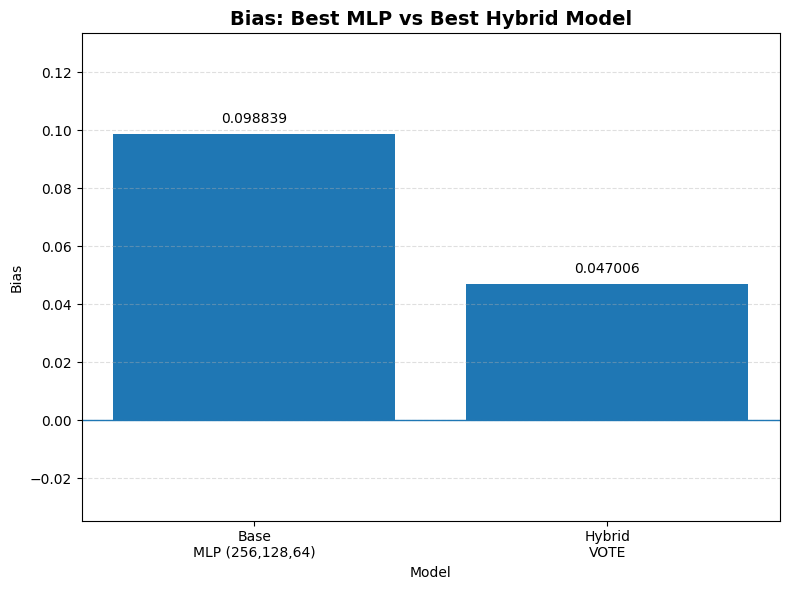

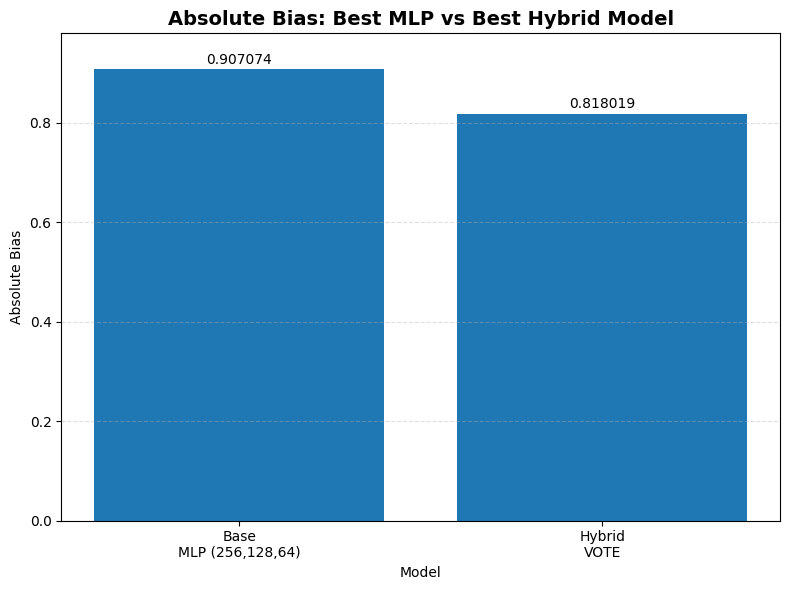

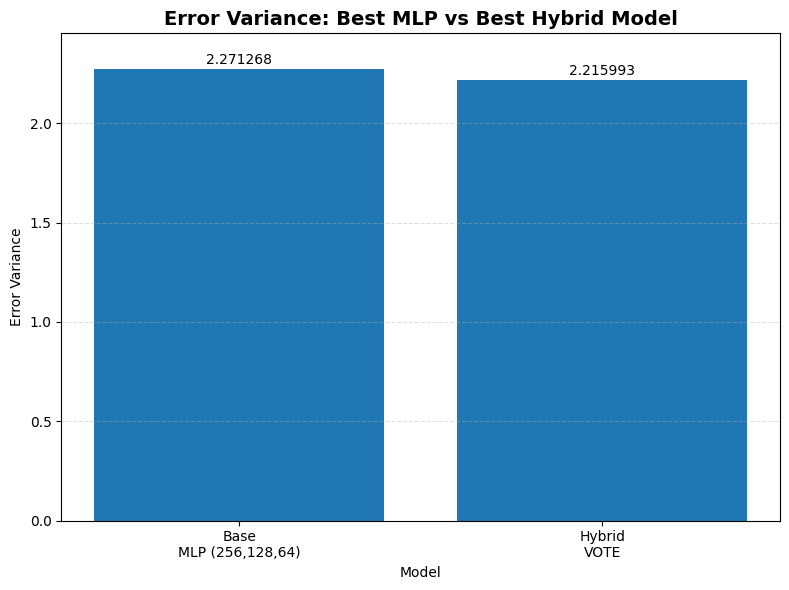

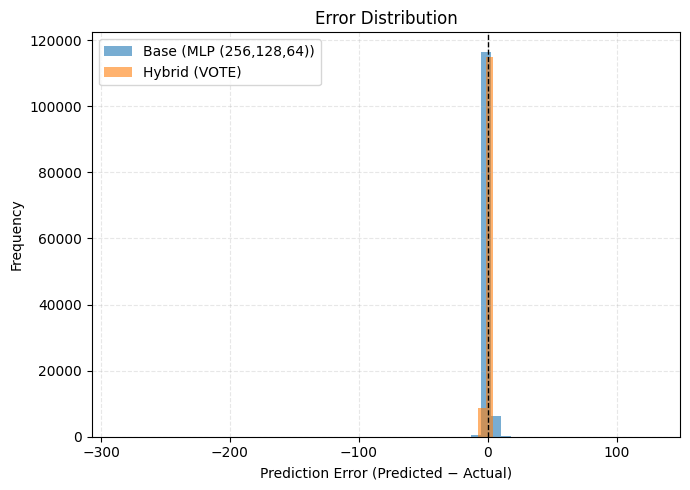

In [224]:
# =============================================================================
# PLOT BIAS AND VARIANCE
# BEST BASE MODEL = MLP WITH HIGHEST COMBINED SCORE
# BEST HYBRID MODEL = HIGHEST COMBINED SCORE
# No model training occurs here
# =============================================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# 1. SELECT BEST MLP BASE MODEL
# Primary criterion: highest combined score
#
# Score = R² / (1 + MAE + MSE + RMSE + MAPE)
#
# Tie-breakers:
# 1. Lowest MAE
# 2. Highest R²
# -----------------------------------------------------------------------------

if (
    "base_kfold_summary" not in globals()
    or base_kfold_summary is None
    or base_kfold_summary.empty
):
    raise ValueError(
        "base_kfold_summary is empty or undefined. "
        "Run the K-fold section first."
    )


required_base_score_columns = [
    "R2_Mean",
    "MAE_Mean",
    "MSE_Mean",
    "RMSE_Mean",
    "MAPE_Mean"
]

missing_base_score_columns = [
    column
    for column in required_base_score_columns
    if column not in base_kfold_summary.columns
]

if missing_base_score_columns:
    raise KeyError(
        "The following columns are missing from "
        "base_kfold_summary: "
        f"{missing_base_score_columns}"
    )


# Copy prevents changing the original summary unexpectedly
base_kfold_summary = base_kfold_summary.copy()


# Calculate combined score
base_kfold_summary["Combined_Score"] = (
    base_kfold_summary["R2_Mean"]
    /
    (
        1.0
        + base_kfold_summary["MAE_Mean"]
        + base_kfold_summary["MSE_Mean"]
        + base_kfold_summary["RMSE_Mean"]
        + base_kfold_summary["MAPE_Mean"]
    )
)


# Keep only MLP base models
mlp_results = base_kfold_summary[
    base_kfold_summary["Model"]
    .astype(str)
    .str.contains("MLP", case=False, na=False)
].copy()


if mlp_results.empty:
    raise ValueError(
        "No MLP model was found in base_kfold_summary.\n"
        f"Available models:\n"
        f"{base_kfold_summary['Model'].unique()}"
    )


# Select highest-score MLP model
best_mlp = (
    mlp_results
    .sort_values(
        [
            "Combined_Score",
            "MAE_Mean",
            "R2_Mean"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .iloc[0]
)


# -----------------------------------------------------------------------------
# 2. SELECT BEST HYBRID MODEL
# Primary criterion: highest combined score
#
# Score = R² / (1 + MAE + MSE + RMSE + MAPE)
#
# Tie-breakers:
# 1. Lowest MAE
# 2. Highest R²
# -----------------------------------------------------------------------------

if (
    "hybrid_kfold_summary" not in globals()
    or hybrid_kfold_summary is None
    or hybrid_kfold_summary.empty
):
    raise ValueError(
        "hybrid_kfold_summary is empty or undefined. "
        "Run the K-fold section first."
    )


required_hybrid_score_columns = [
    "R2_Mean",
    "MAE_Mean",
    "MSE_Mean",
    "RMSE_Mean",
    "MAPE_Mean"
]

missing_hybrid_score_columns = [
    column
    for column in required_hybrid_score_columns
    if column not in hybrid_kfold_summary.columns
]

if missing_hybrid_score_columns:
    raise KeyError(
        "The following columns are missing from "
        "hybrid_kfold_summary: "
        f"{missing_hybrid_score_columns}"
    )


# Copy prevents changing the original summary unexpectedly
hybrid_kfold_summary = hybrid_kfold_summary.copy()


# Calculate combined score
hybrid_kfold_summary["Combined_Score"] = (
    hybrid_kfold_summary["R2_Mean"]
    /
    (
        1.0
        + hybrid_kfold_summary["MAE_Mean"]
        + hybrid_kfold_summary["MSE_Mean"]
        + hybrid_kfold_summary["RMSE_Mean"]
        + hybrid_kfold_summary["MAPE_Mean"]
    )
)


# Select highest-score hybrid model
best_hybrid = (
    hybrid_kfold_summary
    .sort_values(
        [
            "Combined_Score",
            "MAE_Mean",
            "R2_Mean"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .iloc[0]
)


# -----------------------------------------------------------------------------
# 3. PRINT SELECTED MODELS
# -----------------------------------------------------------------------------

print("\n" + "=" * 90)
print("SELECTED MODELS FOR BIAS AND VARIANCE PLOT")
print("SELECTION BASED ON COMBINED SCORE")
print("=" * 90)


print("\nBest base model:")
print(f"Combo        : {best_mlp['Combo']}")
print(f"Model        : {best_mlp['Model']}")
print(
    f"Combined Score: "
    f"{best_mlp['Combined_Score']:.10f}"
)
print(f"Bias         : {best_mlp['Fold_Bias_Mean']:.6f}")
print(
    f"Absolute Bias: "
    f"{best_mlp['Fold_Absolute_Bias_Mean']:.6f}"
)
print(
    f"Variance     : "
    f"{best_mlp['Fold_Variance_Mean']:.6f}"
)
print(f"MAE          : {best_mlp['MAE_Mean']:.6f}")
print(f"R²           : {best_mlp['R2_Mean']:.6f}")
print(f"MSE          : {best_mlp['MSE_Mean']:.6f}")
print(f"RMSE         : {best_mlp['RMSE_Mean']:.6f}")
print(f"MAPE         : {best_mlp['MAPE_Mean']:.6f}")


print("\nBest hybrid model:")
print(f"Combo        : {best_hybrid['Combo']}")
print(f"Hybrid       : {best_hybrid['Hybrid']}")

if "Bases" in best_hybrid.index:
    print(f"Bases        : {best_hybrid['Bases']}")

print(
    f"Combined Score: "
    f"{best_hybrid['Combined_Score']:.10f}"
)
print(
    f"Bias         : "
    f"{best_hybrid['Fold_Bias_Mean']:.6f}"
)
print(
    f"Absolute Bias: "
    f"{best_hybrid['Fold_Absolute_Bias_Mean']:.6f}"
)
print(
    f"Variance     : "
    f"{best_hybrid['Fold_Variance_Mean']:.6f}"
)
print(f"MAE          : {best_hybrid['MAE_Mean']:.6f}")
print(f"R²           : {best_hybrid['R2_Mean']:.6f}")
print(f"MSE          : {best_hybrid['MSE_Mean']:.6f}")
print(f"RMSE         : {best_hybrid['RMSE_Mean']:.6f}")
print(f"MAPE         : {best_hybrid['MAPE_Mean']:.6f}")


# -----------------------------------------------------------------------------
# 4. PREPARE PLOT DATA
# Signed bias is used; no absolute value
# -----------------------------------------------------------------------------

model_labels = [
    f"Base\n{best_mlp['Model']}",
    f"Hybrid\n{best_hybrid['Hybrid']}"
]

bias_values = [
    float(best_mlp["Fold_Bias_Mean"]),
    float(best_hybrid["Fold_Bias_Mean"])
]

absolute_bias_values = [
    float(best_mlp["Fold_Absolute_Bias_Mean"]),
    float(best_hybrid["Fold_Absolute_Bias_Mean"])
]

variance_values = [
    float(best_mlp["Fold_Variance_Mean"]),
    float(best_hybrid["Fold_Variance_Mean"])
]


# -----------------------------------------------------------------------------
# 5. BIAS PLOT
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    model_labels,
    bias_values
)

ax.set_title(
    "Bias: Best MLP vs Best Hybrid Model",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Model")
ax.set_ylabel("Bias")

# Zero-reference line
ax.axhline(
    y=0,
    linewidth=1
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Add space above and below bars
largest_bias = max(
    abs(value) for value in bias_values
)

bias_margin = (
    largest_bias * 0.35
    if largest_bias > 0
    else 0.1
)

ax.set_ylim(
    min(bias_values + [0]) - bias_margin,
    max(bias_values + [0]) + bias_margin
)

for bar, value in zip(bars, bias_values):

    if value >= 0:
        label_y = value + bias_margin * 0.08
        vertical_alignment = "bottom"
    else:
        label_y = value - bias_margin * 0.08
        vertical_alignment = "top"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"{value:.6f}",
        ha="center",
        va=vertical_alignment,
        fontsize=10
    )

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 6. ABSOLUTE BIAS PLOT
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    model_labels,
    absolute_bias_values
)

ax.set_title(
    "Absolute Bias: Best MLP vs Best Hybrid Model",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Model")
ax.set_ylabel("Absolute Bias")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

largest_absolute_bias = max(absolute_bias_values)

absolute_bias_margin = (
    largest_absolute_bias * 0.08
    if largest_absolute_bias > 0
    else 0.1
)

ax.set_ylim(
    0,
    largest_absolute_bias + absolute_bias_margin
)

for bar, value in zip(bars, absolute_bias_values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + absolute_bias_margin * 0.08,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 7. VARIANCE PLOT
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    model_labels,
    variance_values
)

ax.set_title(
    "Error Variance: Best MLP vs Best Hybrid Model",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Model")
ax.set_ylabel("Error Variance")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

largest_variance = max(variance_values)

variance_margin = (
    largest_variance * 0.08
    if largest_variance > 0
    else 0.1
)

ax.set_ylim(
    0,
    largest_variance + variance_margin
)

for bar, value in zip(bars, variance_values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + variance_margin * 0.08,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 8. ERROR DISTRIBUTION PLOT
# -----------------------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.hist(
    best_base_errors,
    bins=50,
    alpha=0.6,
    label=f"Base ({best_mlp['Model']})"
)

plt.hist(
    best_hybrid_errors,
    bins=50,
    alpha=0.6,
    label=f"Hybrid ({best_hybrid['Hybrid']})"
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Prediction Error (Predicted − Actual)"
)

plt.ylabel("Frequency")

plt.title("Error Distribution")

plt.legend()

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [225]:
# ============================================================
# HYBRID MODEL COMPARISON:
# IQR FILTERING vs EXACT % ANOMALY DETECTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Check required hybrid tables
# ------------------------------------------------------------
required_hybrid_tables = [
    "df_h_after_iqr",
    "df_h_after_anomaly_2pct"
]

missing_hybrid_tables = [
    name
    for name in required_hybrid_tables
    if name not in globals()
]

if missing_hybrid_tables:
    raise NameError(
        "Run both hybrid-model sections first. "
        f"Missing: {missing_hybrid_tables}"
    )

required_columns = [
    "Combo",
    "Hybrid",
    "Bases",
    "Score_H",
    "Test_MAE",
    "Test_MSE",
    "Test_R2"
]

for table_name, table_value in {
    "df_h_after_iqr": df_h_after_iqr,
    "df_h_after_anomaly_2pct": df_h_after_anomaly_2pct
}.items():

    missing_columns = [
        column
        for column in required_columns
        if column not in table_value.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{table_name} is missing columns: "
            f"{missing_columns}"
        )


# ------------------------------------------------------------
# Prepare IQR hybrid results
# ------------------------------------------------------------
iqr_hybrid_results = (
    df_h_after_iqr[
        required_columns
    ]
    .drop_duplicates(
        subset=["Combo", "Hybrid"],
        keep="first"
    )
    .rename(columns={
        "Bases": "IQR_Bases",
        "Score_H": "IQR_Score_H",
        "Test_MAE": "IQR_MAE",
        "Test_MSE": "IQR_MSE",
        "Test_R2": "IQR_R2"
    })
)


# ------------------------------------------------------------
# Prepare anomaly hybrid results
# ------------------------------------------------------------
anomaly_hybrid_results = (
    df_h_after_anomaly_2pct[
        required_columns
    ]
    .drop_duplicates(
        subset=["Combo", "Hybrid"],
        keep="first"
    )
    .rename(columns={
        "Bases": "Anomaly_Bases",
        "Score_H": "Anomaly_Score_H",
        "Test_MAE": "Anomaly_MAE",
        "Test_MSE": "Anomaly_MSE",
        "Test_R2": "Anomaly_R2"
    })
)


# ------------------------------------------------------------
# Match the same feature combination and hybrid model
# ------------------------------------------------------------
hybrid_performance_comparison = (
    iqr_hybrid_results.merge(
        anomaly_hybrid_results,
        on=["Combo", "Hybrid"],
        how="inner",
        validate="one_to_one"
    )
)

if hybrid_performance_comparison.empty:
    raise ValueError(
        "No matching Combo + Hybrid pairs were found between "
        "the IQR and anomaly hybrid-result tables."
    )


# ------------------------------------------------------------
# Calculate differences
# Negative difference means anomaly detection has lower error.
# ------------------------------------------------------------
hybrid_performance_comparison[
    "MAE_Difference_Anomaly_minus_IQR"
] = (
    hybrid_performance_comparison["Anomaly_MAE"]
    - hybrid_performance_comparison["IQR_MAE"]
)

hybrid_performance_comparison[
    "MSE_Difference_Anomaly_minus_IQR"
] = (
    hybrid_performance_comparison["Anomaly_MSE"]
    - hybrid_performance_comparison["IQR_MSE"]
)

hybrid_performance_comparison[
    "R2_Difference_Anomaly_minus_IQR"
] = (
    hybrid_performance_comparison["Anomaly_R2"]
    - hybrid_performance_comparison["IQR_R2"]
)


# ------------------------------------------------------------
# Identify winner for MAE and MSE
# ------------------------------------------------------------
hybrid_performance_comparison["MAE_Winner"] = np.select(
    [
        hybrid_performance_comparison["IQR_MAE"]
        < hybrid_performance_comparison["Anomaly_MAE"],

        hybrid_performance_comparison["Anomaly_MAE"]
        < hybrid_performance_comparison["IQR_MAE"]
    ],
    [
        "IQR Filtering",
        "Anomaly Detection"
    ],
    default="Tie"
)

hybrid_performance_comparison["MSE_Winner"] = np.select(
    [
        hybrid_performance_comparison["IQR_MSE"]
        < hybrid_performance_comparison["Anomaly_MSE"],

        hybrid_performance_comparison["Anomaly_MSE"]
        < hybrid_performance_comparison["IQR_MSE"]
    ],
    [
        "IQR Filtering",
        "Anomaly Detection"
    ],
    default="Tie"
)


# ------------------------------------------------------------
# Average metrics for fair hybrid selection
# ------------------------------------------------------------
hybrid_performance_comparison["Average_MAE"] = (
    hybrid_performance_comparison["IQR_MAE"]
    + hybrid_performance_comparison["Anomaly_MAE"]
) / 2.0

hybrid_performance_comparison["Average_MSE"] = (
    hybrid_performance_comparison["IQR_MSE"]
    + hybrid_performance_comparison["Anomaly_MSE"]
) / 2.0

hybrid_performance_comparison["Average_Score_H"] = (
    hybrid_performance_comparison["IQR_Score_H"]
    + hybrid_performance_comparison["Anomaly_Score_H"]
) / 2.0


# ------------------------------------------------------------
# Display all matched hybrid results
# ------------------------------------------------------------
hybrid_performance_comparison = (
    hybrid_performance_comparison
    .sort_values(
        [
            "Average_MAE",
            "Average_MSE"
        ],
        ascending=True
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 150)
print("MATCHED HYBRID PERFORMANCE: IQR vs EXACT 2% ANOMALY")
print("=" * 150)

print(
    hybrid_performance_comparison[
        [
            "Combo",
            "Hybrid",
            "IQR_Bases",
            "Anomaly_Bases",
            "IQR_MAE",
            "Anomaly_MAE",
            "IQR_MSE",
            "Anomaly_MSE",
            "IQR_R2",
            "Anomaly_R2",
            "IQR_Score_H",
            "Anomaly_Score_H",
            "MAE_Winner",
            "MSE_Winner"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("=" * 150)


MATCHED HYBRID PERFORMANCE: IQR vs EXACT 2% ANOMALY
           Combo      Hybrid                         IQR_Bases                Anomaly_Bases  IQR_MAE  Anomaly_MAE  IQR_MSE  Anomaly_MSE   IQR_R2  Anomaly_R2  IQR_Score_H  Anomaly_Score_H    MAE_Winner        MSE_Winner
SPATIAL+TEMPORAL        VOTE MLP (256,128,64),MLP (128,64),ETR Ridge,Bayes,MLP (256,128,64) 0.543734     0.861507 4.179510     3.686931 0.989019    0.999936     0.116358         0.400412 IQR Filtering Anomaly Detection
SPATIAL+TEMPORAL   STACK_GBR MLP (256,128,64),MLP (128,64),ETR Ridge,Bayes,MLP (256,128,64) 0.460731     0.951414 2.853147     3.098564 0.992504    0.999946     1.000000         0.600000 IQR Filtering     IQR Filtering
SPATIAL+TEMPORAL STACK_Ridge MLP (256,128,64),MLP (128,64),ETR Ridge,Bayes,MLP (256,128,64) 0.568405     0.864645 3.851159     3.721086 0.989881    0.999935     0.145157         0.393020 IQR Filtering Anomaly Detection


In [226]:
# ============================================================
# SELECT BEST MATCHED HYBRID MODEL
# ============================================================

selected_hybrid_row = (
    hybrid_performance_comparison
    .sort_values(
        [
            "Average_MAE",
            "Average_MSE",
            "Average_Score_H"
        ],
        ascending=[True, True, False]
    )
    .iloc[0]
)

selected_combo = selected_hybrid_row["Combo"]
selected_hybrid = selected_hybrid_row["Hybrid"]

selected_hybrid_performance = pd.DataFrame({
    "Preprocessing Method": [
        "IQR Filtering",
        "Anomaly Detection"
    ],
    "Feature Combination": [
        selected_combo,
        selected_combo
    ],
    "Hybrid Model": [
        selected_hybrid,
        selected_hybrid
    ],
    "MAE": [
        selected_hybrid_row["IQR_MAE"],
        selected_hybrid_row["Anomaly_MAE"]
    ],
    "MSE": [
        selected_hybrid_row["IQR_MSE"],
        selected_hybrid_row["Anomaly_MSE"]
    ],
    "R2": [
        selected_hybrid_row["IQR_R2"],
        selected_hybrid_row["Anomaly_R2"]
    ],
    "Score_H": [
        selected_hybrid_row["IQR_Score_H"],
        selected_hybrid_row["Anomaly_Score_H"]
    ]
})

print("\n" + "=" * 90)
print("SELECTED HYBRID MODEL FOR COMPARISON")
print("=" * 90)
print(f"Feature combination : {selected_combo}")
print(f"Hybrid model        : {selected_hybrid}")

print(
    selected_hybrid_performance.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("=" * 90)


SELECTED HYBRID MODEL FOR COMPARISON
Feature combination : SPATIAL+TEMPORAL
Hybrid model        : VOTE
Preprocessing Method Feature Combination Hybrid Model      MAE      MSE       R2  Score_H
       IQR Filtering    SPATIAL+TEMPORAL         VOTE 0.543734 4.179510 0.989019 0.116358
   Anomaly Detection    SPATIAL+TEMPORAL         VOTE 0.861507 3.686931 0.999936 0.400412


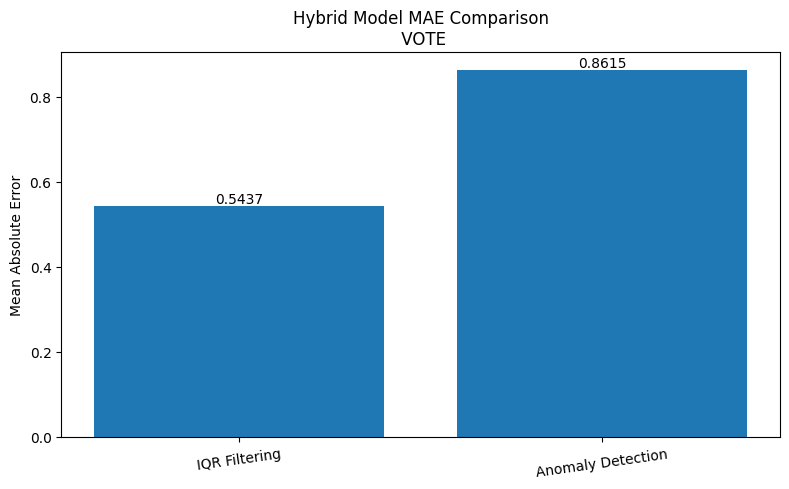

In [227]:
# ============================================================
# MAE COMPARISON FOR SELECTED HYBRID MODEL
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    selected_hybrid_performance[
        "Preprocessing Method"
    ],
    selected_hybrid_performance["MAE"]
)

plt.title(
    "Hybrid Model MAE Comparison\n"
    f" {selected_hybrid}"
)


plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=8)

for bar, value in zip(
    bars,
    selected_hybrid_performance["MAE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

| Hybrid      | R² Rank | MAE Rank | MSE Rank | RMSE Rank | MAPE Rank | Total Rank |        Score        |
| ----------- | :-----: | :------: | :------: | :-------: | :-------: | :--------: | :-----------------: |
| STACK_GBR   |    1    |     2    |     1    |     1     |     2     |    **7**   |  **15 − 7 + 1 = 9** |
| VOTE        |    2    |     1    |     2    |     2     |     1     |    **8**   |  **15 − 8 + 1 = 8** |
| STACK_Ridge |    3    |     3    |     3    |     3     |     3     |   **15**   | **15 − 15 + 1 = 1** |

The calculations are:

Rank each metric:
R²: higher is better → Rank 1 is the highest R².
MAE, MSE, RMSE, MAPE: lower is better → Rank 1 is the lowest value.
Compute the total rank:
Total Rank=R2 Rank+MAE Rank+MSE Rank+RMSE Rank+MAPE Rank
Convert it to a score:
Score=max(Total Rank)−Total Rank+1
	​


In your example, the maximum total rank is 15, so:

STACK_GBR: 15−7+1=9
VOTE: 15−8+1=8
STACK_Ridge: 15−15+1=1

In [228]:
# =============================================================================
# COPY THE PREVIOUS HYBRID SUMMARY
# =============================================================================

hyb_fold_tbl_after_anomaly_mean2 = (
    hybrid_kfold_summary.copy()
    .rename(
        columns={
            "R2_Mean": "Mean_R2",
            "MAE_Mean": "Mean_MAE",
            "MSE_Mean": "Mean_MSE",
            "RMSE_Mean": "Mean_RMSE",
            "MAPE_Mean": "Mean_MAPE",
        }
    )
)


# =============================================================================
# FIVE-METRIC RANKING
# =============================================================================

r2_rank = (
    hyb_fold_tbl_after_anomaly_mean2["Mean_R2"]
    .rank(ascending=False)
)

mae_rank = (
    hyb_fold_tbl_after_anomaly_mean2["Mean_MAE"]
    .rank(ascending=True)
)

mse_rank = (
    hyb_fold_tbl_after_anomaly_mean2["Mean_MSE"]
    .rank(ascending=True)
)

rmse_rank = (
    hyb_fold_tbl_after_anomaly_mean2["Mean_RMSE"]
    .rank(ascending=True)
)

mape_rank = (
    hyb_fold_tbl_after_anomaly_mean2["Mean_MAPE"]
    .rank(ascending=True)
)


# =============================================================================
# TOTAL RANK
# =============================================================================

total_rank = (
    r2_rank
    + mae_rank
   
)


# =============================================================================
# SCORE
# Higher Score = Better Model
# +1 ensures the lowest score is 1 instead of 0
# =============================================================================

hyb_fold_tbl_after_anomaly_mean2["Score"] = (
    total_rank.max()
    - total_rank
    + 1
)


# =============================================================================
# SORT BY SCORE
# =============================================================================

hyb_fold_tbl_after_anomaly_mean = (
    hyb_fold_tbl_after_anomaly_mean2
    .sort_values(
        [
            "Score",
        ],
        ascending=[
            False,
        ]
    )
    .reset_index(drop=True)
)


print("\n=== Mean Hybrid Results After Anomaly Removal ===")

print(
    hyb_fold_tbl_after_anomaly_mean2.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


=== Mean Hybrid Results After Anomaly Removal ===
           Combo      Hybrid                        Bases  Mean_MAE  MAE_Std  Mean_R2   R2_Std  Mean_MSE  MSE_Std  Mean_RMSE  RMSE_Std  Mean_MAPE  MAPE_Std  Fold_Bias_Mean  Fold_Bias_Std  Fold_Absolute_Bias_Mean  Fold_Absolute_Bias_Std  Fold_Variance_Mean  Fold_Variance_Std  R2_Rank  MAE_Rank  MSE_Rank  RMSE_Rank  MAPE_Rank  Total_Rank    Score  Overall_Rank  Combined_Score
SPATIAL+TEMPORAL        VOTE Ridge,Bayes,MLP (256,128,64)  0.818019 0.001253 0.999809 0.000031  2.219127 0.343701   1.486550  0.118084   3.517616  0.023281        0.047006       0.038492                 0.818019                0.001253            2.215993           0.341197 1.000000  1.000000  1.000000   1.000000   1.000000    5.000000 5.000000             1        0.110582
SPATIAL+TEMPORAL   STACK_GBR Ridge,Bayes,MLP (256,128,64)  0.865331 0.018670 0.999796 0.000116  2.370002 1.324029   1.501891  0.414109   3.574142  0.107487        0.092727       0.089224         

Considering All Metrics IQR vs Anomaly Removal(K-Fold)


HYBRID MAE COMPARISON
IQR Hybrid MAE              : 0.9070
Anomaly Removal Hybrid MAE  : 0.8180
MAE Improvement             : 0.0890
Improvement (%)             : 9.81%


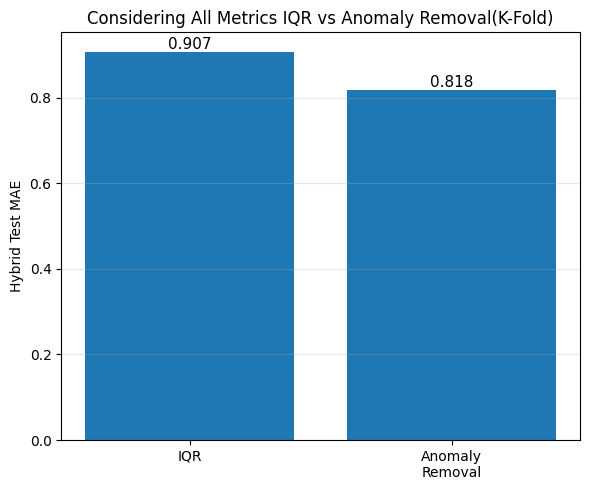

In [229]:
# ============================================================
# SIMPLE HYBRID MAE COMPARISON
# IQR vs ANOMALY REMOVAL
# ============================================================

import matplotlib.pyplot as plt

# First (best-ranked) Hybrid MAE
mae_iqr = IQR_Hybrid_MAE_Table["Mean_MAE"].iloc[0]      # IQR results
mae_anomaly = hyb_fold_tbl_after_anomaly_mean["Mean_MAE"].iloc[0]   # Anomaly results

print("\n" + "="*60)
print("HYBRID MAE COMPARISON")
print("="*60)
print(f"IQR Hybrid MAE              : {mae_iqr:.4f}")
print(f"Anomaly Removal Hybrid MAE  : {mae_anomaly:.4f}")

improvement = mae_iqr - mae_anomaly
improvement_pct = (improvement / mae_iqr) * 100

print(f"MAE Improvement             : {improvement:.4f}")
print(f"Improvement (%)             : {improvement_pct:.2f}%")

# Plot
plt.figure(figsize=(6,5))

bars = plt.bar(
    ["IQR", "Anomaly\nRemoval"],
    [mae_iqr, mae_anomaly]
)

# Show values above bars
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.ylabel("Hybrid Test MAE")
plt.title("Considering All Metrics IQR vs Anomaly Removal(K-Fold)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()